## PCA
```
Task 1: Exploratory Data Analysis (EDA):
1.	Load the dataset and perform basic data exploration.
2.	Examine the distribution of features using histograms, box plots, or density plots.
3.	Investigate correlations between features to understand relationships within the data.

Task 2: Dimensionality Reduction with PCA:
1.	Standardize the features to ensure they have a mean of 0 and a standard deviation of Implement PCA to reduce the dimensionality of the dataset.
2.	Determine the optimal number of principal components using techniques like scree plot or cumulative explained variance.
3.	Transform the original dataset into the principal components.

Task 3: Clustering with Original Data:
1.	Apply a clustering algorithm (e.g., K-means) to the original dataset.
2.	Visualize the clustering results using appropriate plots.
3.	Evaluate the clustering performance using metrics such as silhouette score or Davies–Bouldin index.

Task 4: Clustering with PCA Data:
1.	Apply the same clustering algorithm to the PCA-transformed dataset.
2.	Visualize the clustering results obtained from PCA-transformed data.
3.	Compare the clustering results from PCA-transformed data with those from the original dataset.

Task 5: Comparison and Analysis:
1.	Compare the clustering results obtained from the original dataset and PCA-transformed data.
2.	Discuss any similarities or differences observed in the clustering results.
3.	Reflect on the impact of dimensionality reduction on clustering performance.
4.	Analyze the trade-offs between using PCA and clustering directly on the original dataset.

Task 6: Conclusion and Insights

1.	Summarize the key findings and insights from the assignment.
2.	Discuss the practical implications of using PCA and clustering in data analysis.
3.	Provide recommendations for when to use each technique based on the analysis conducted.

```

## Answers

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#Loading daataset into the enviroment
dataset = pd.read_csv("wine.csv")

# Working on a cloned copy 
df = dataset.copy()

print("\n<----------INFO----------->\n")
print(df.info())

print("\n<-----------DESCRIBE ONLY NUMERICAL---------->\n")
print(df.describe())

print("\n<---------DESCRIBE ALL NUMERICAL AND CATEGORICAL--------->\n")
print(df.describe(include='all'))

print("\n<---------MISSING VALUES--------->\n")
print(df.isnull().sum())


<----------INFO----------->

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB
None

<-----------DESCRIBE ONLY NUMERICAL---------->

             Type     A

## Task1: Exploratory Data Analysis (EDA)

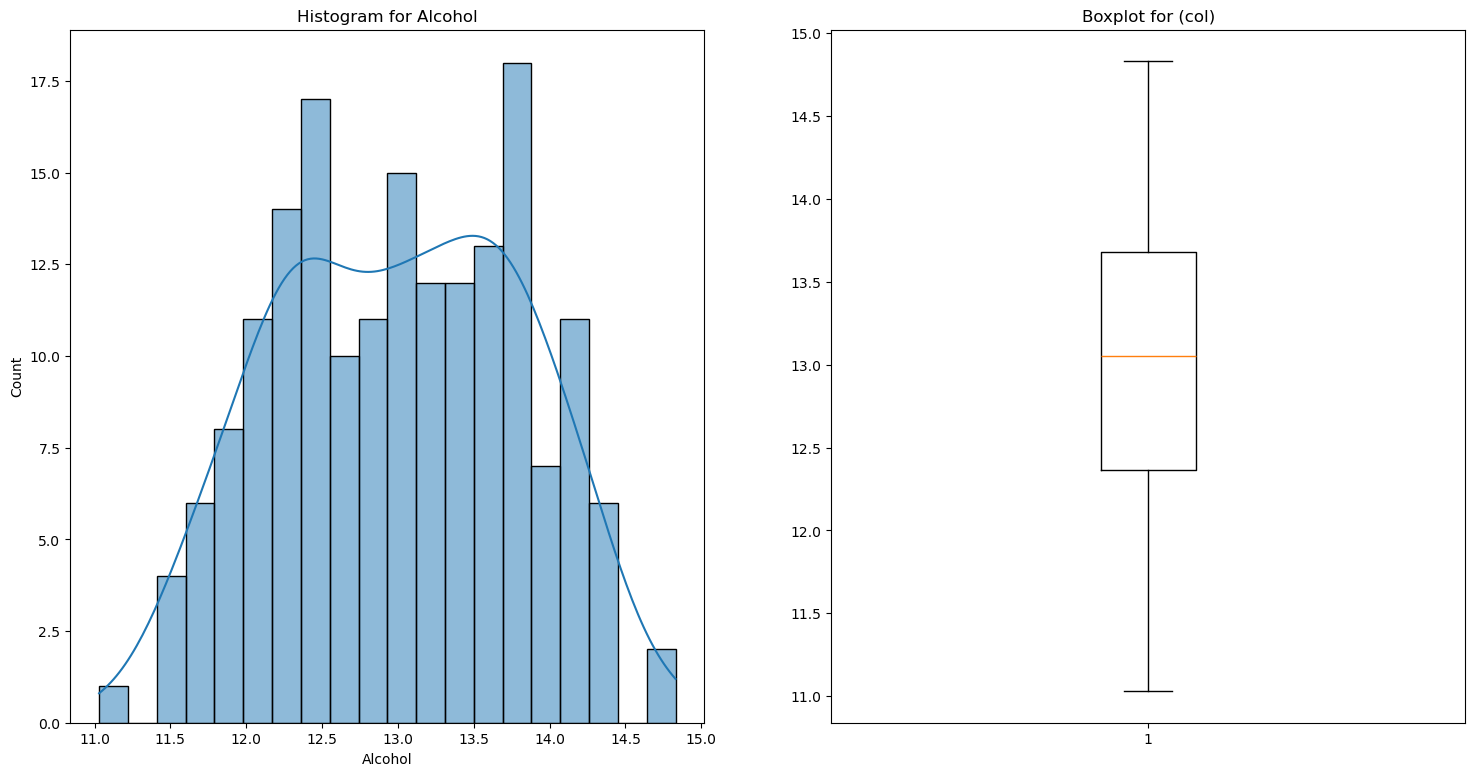

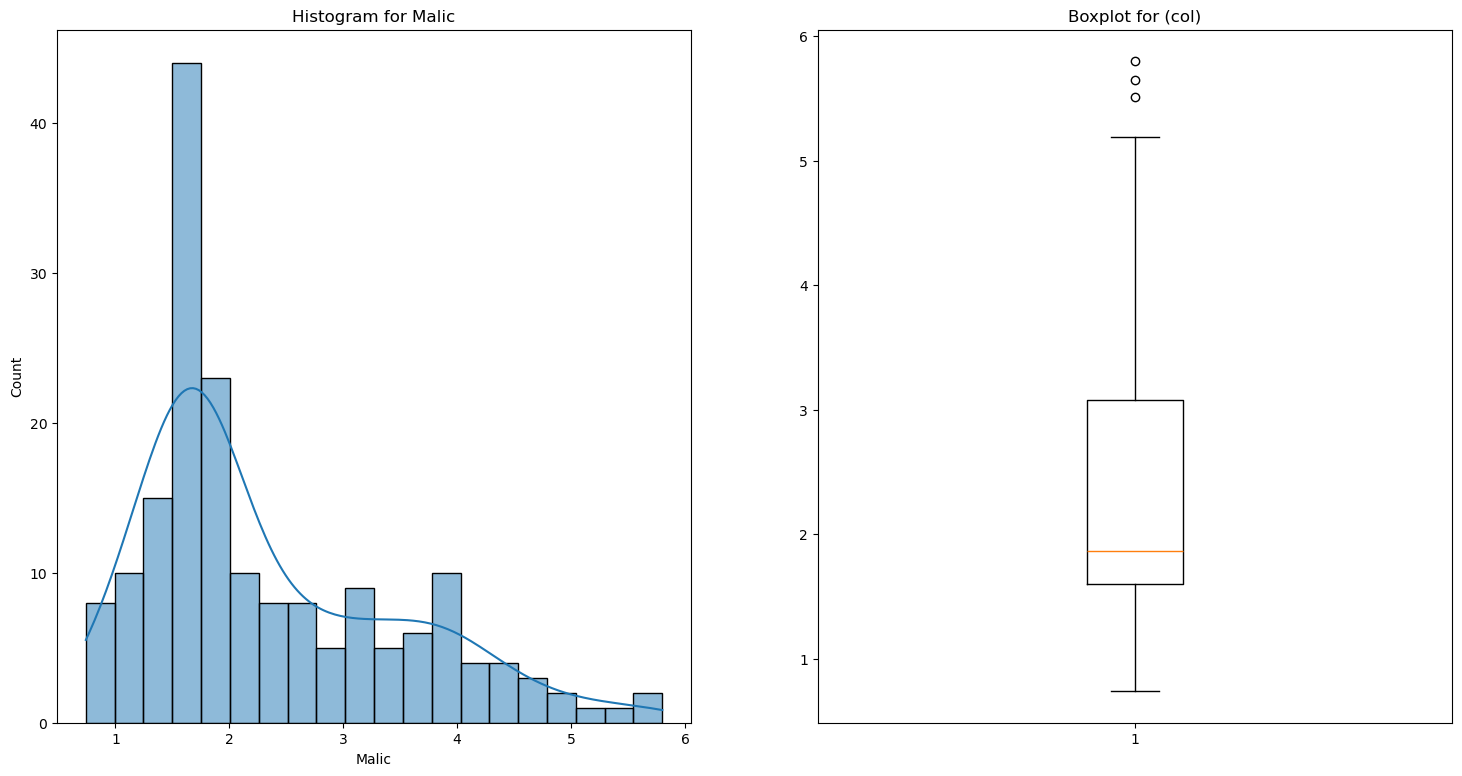

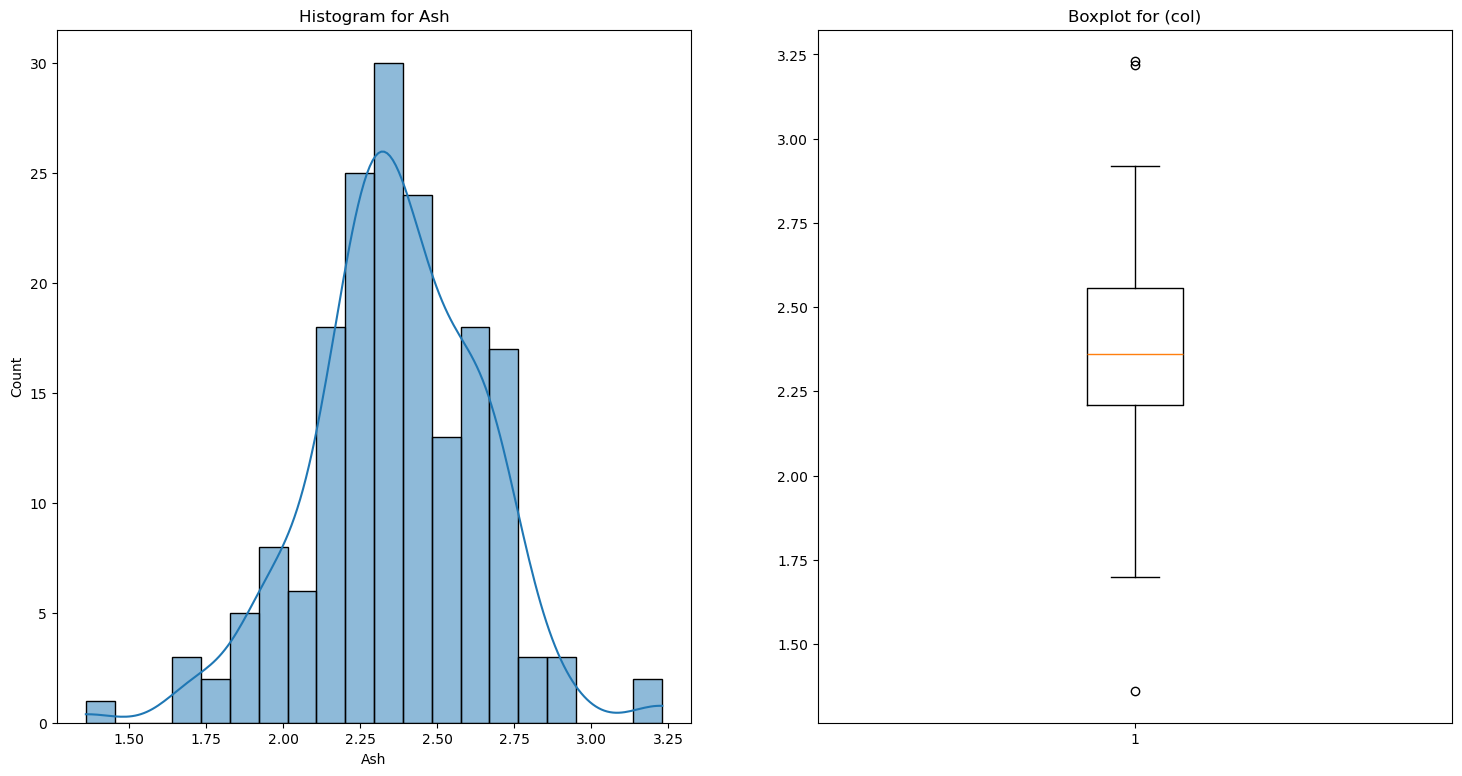

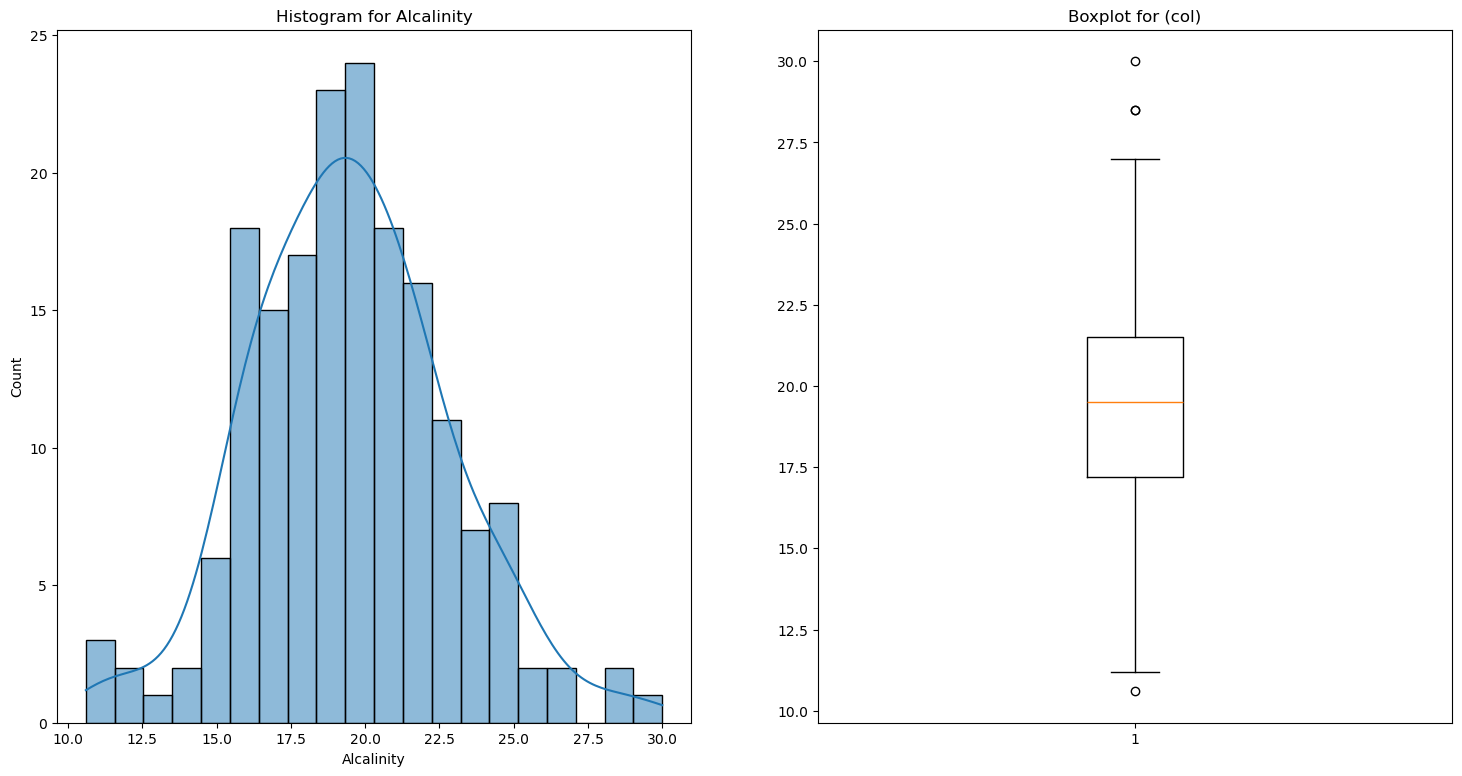

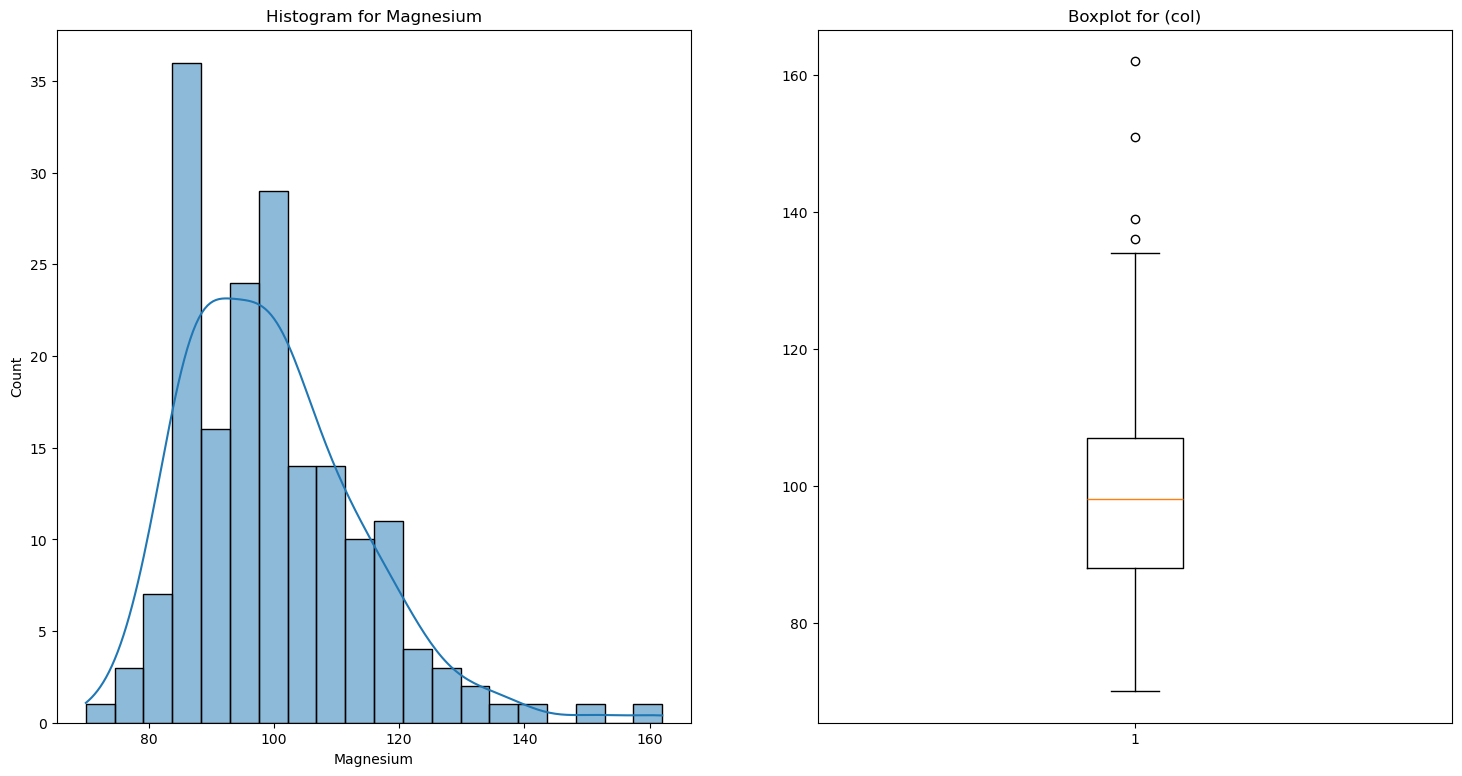

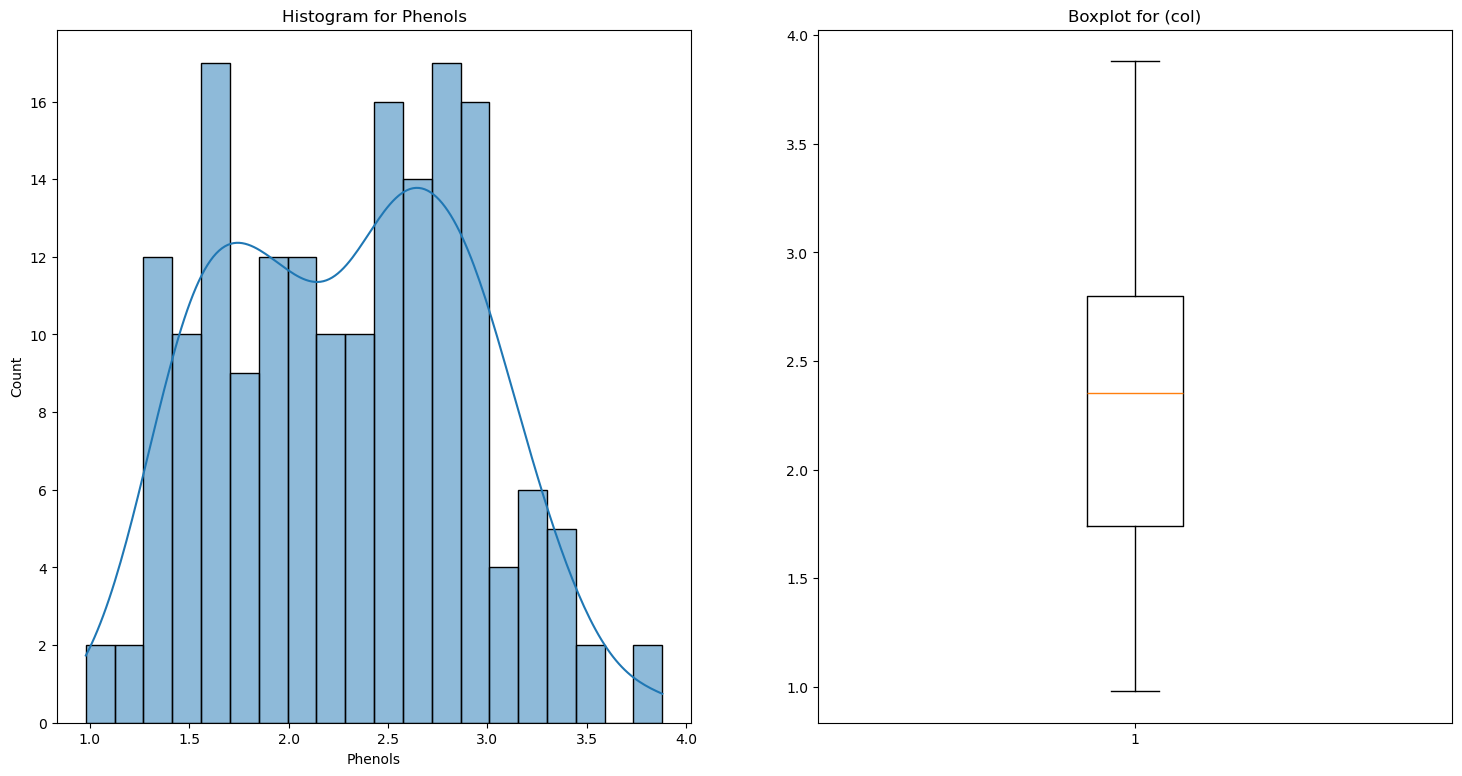

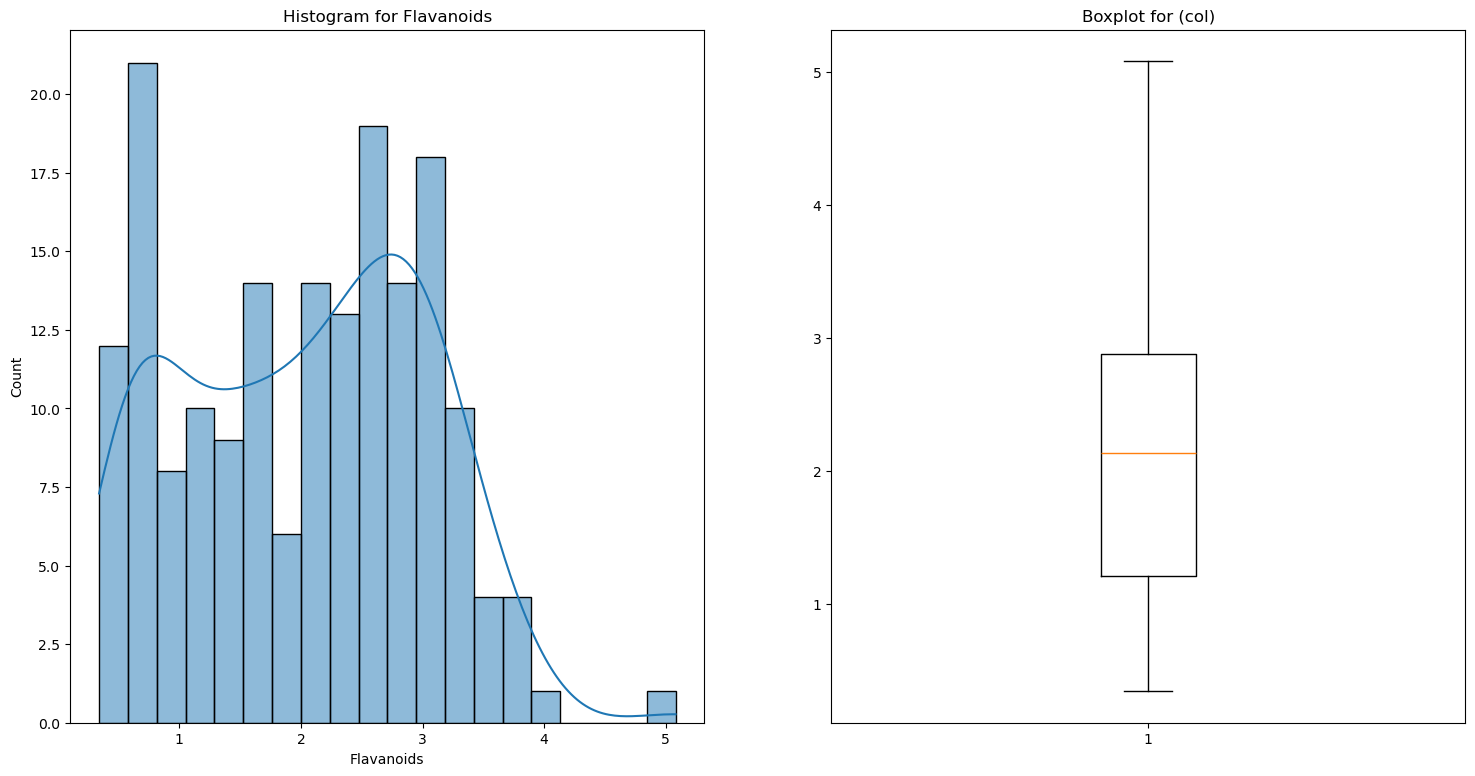

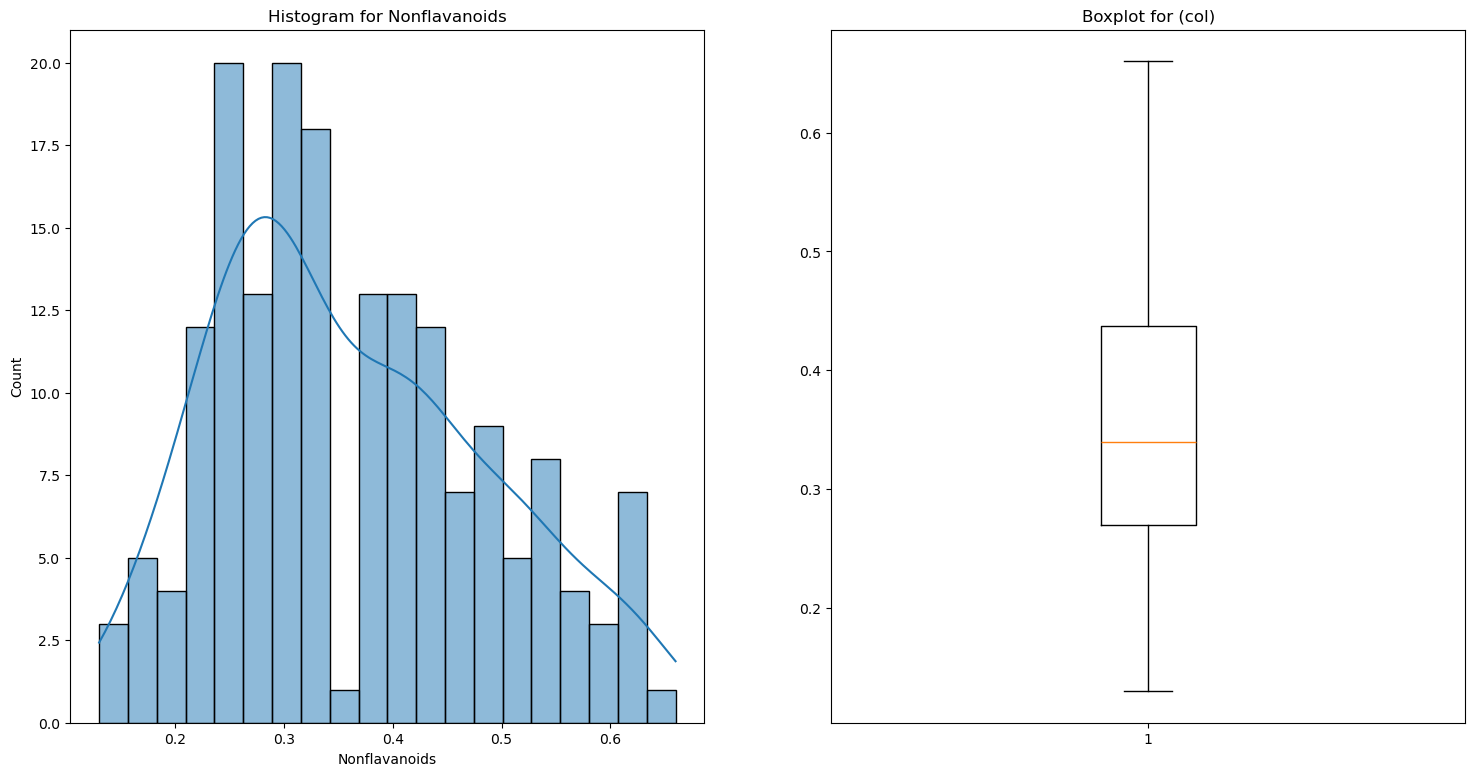

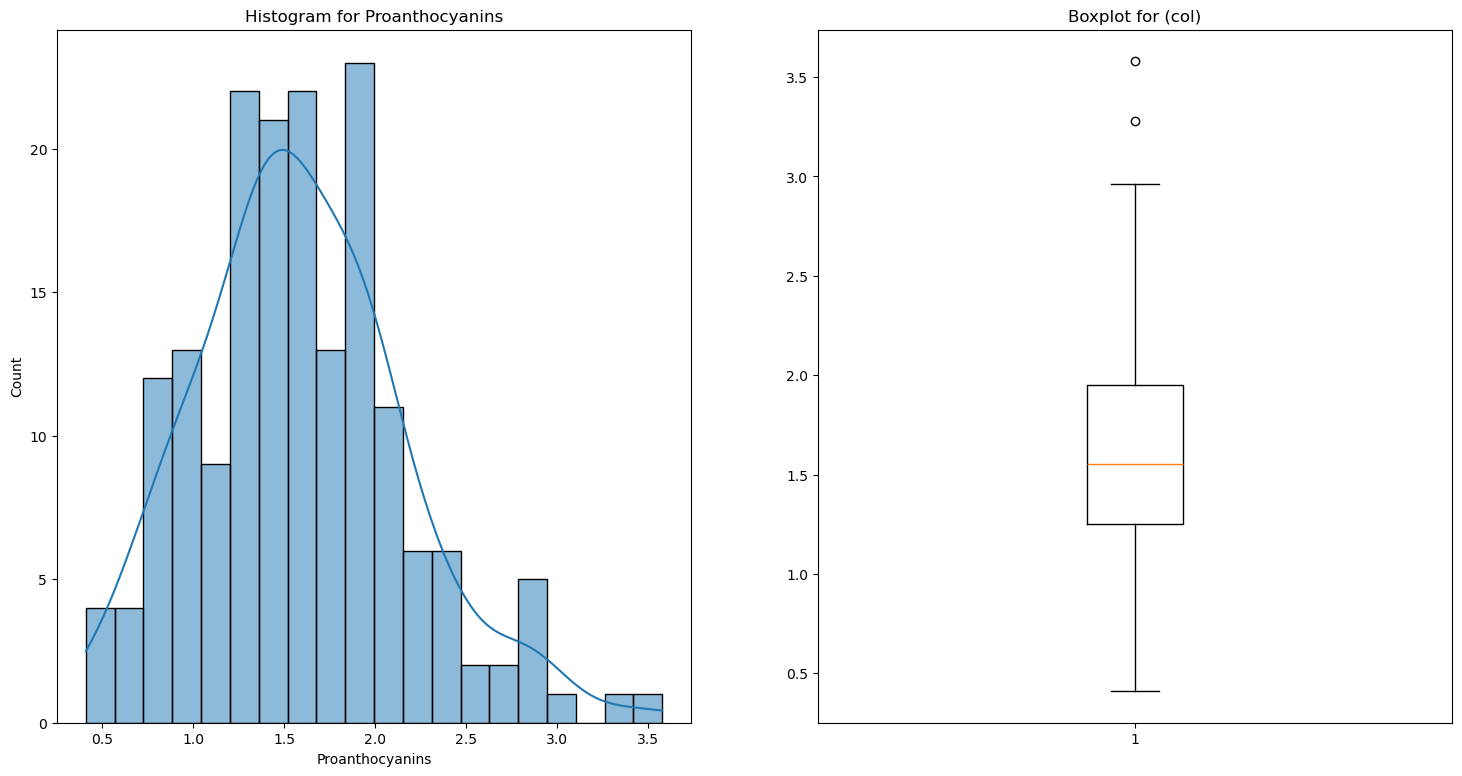

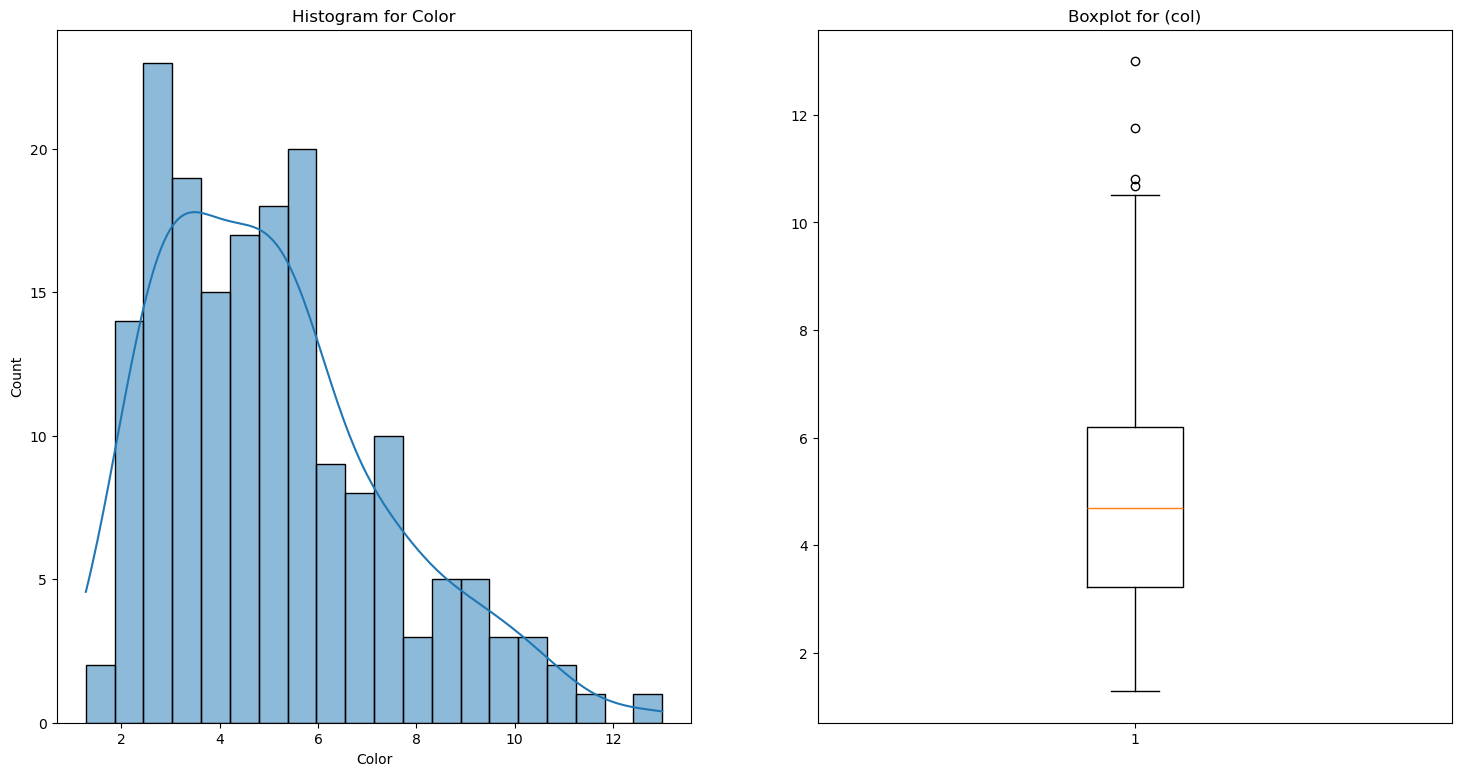

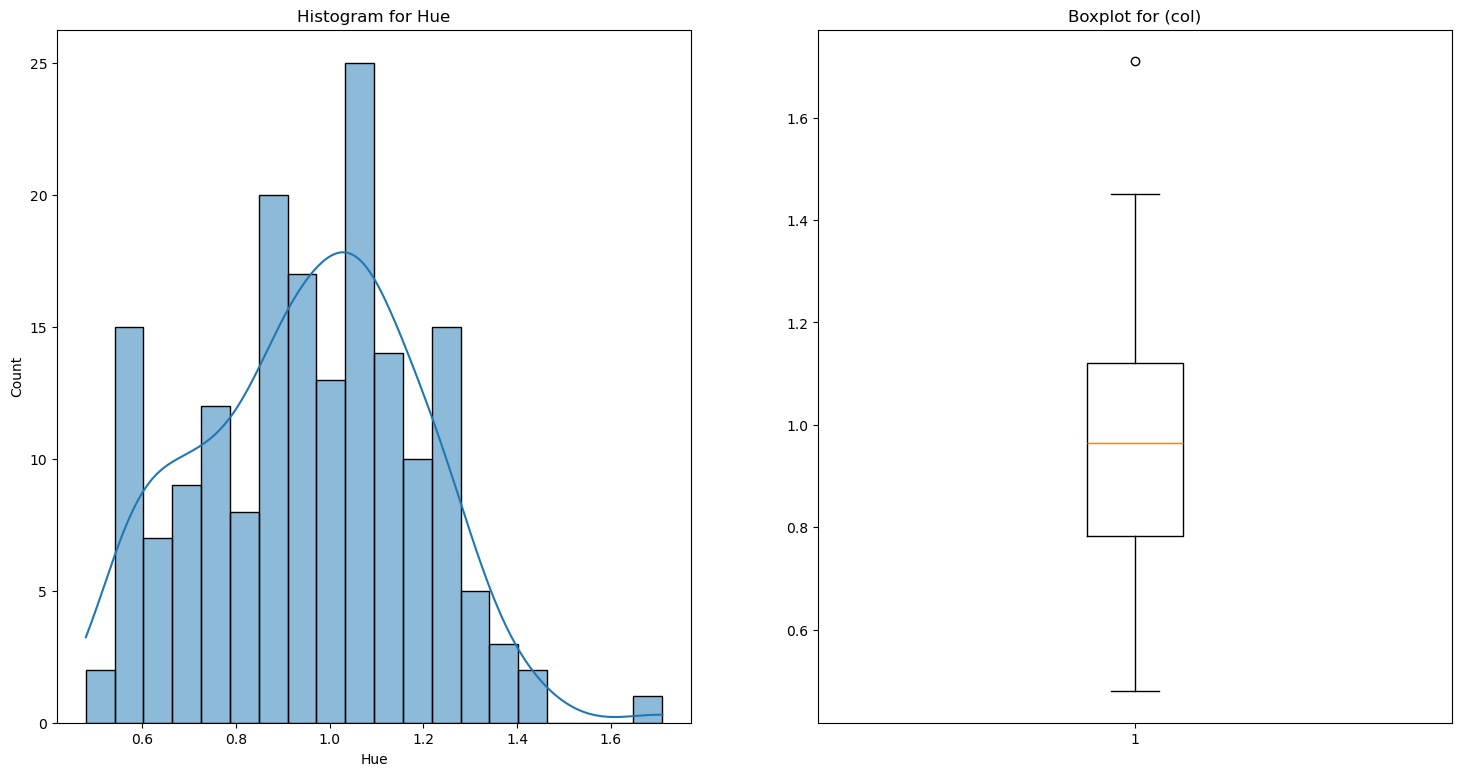

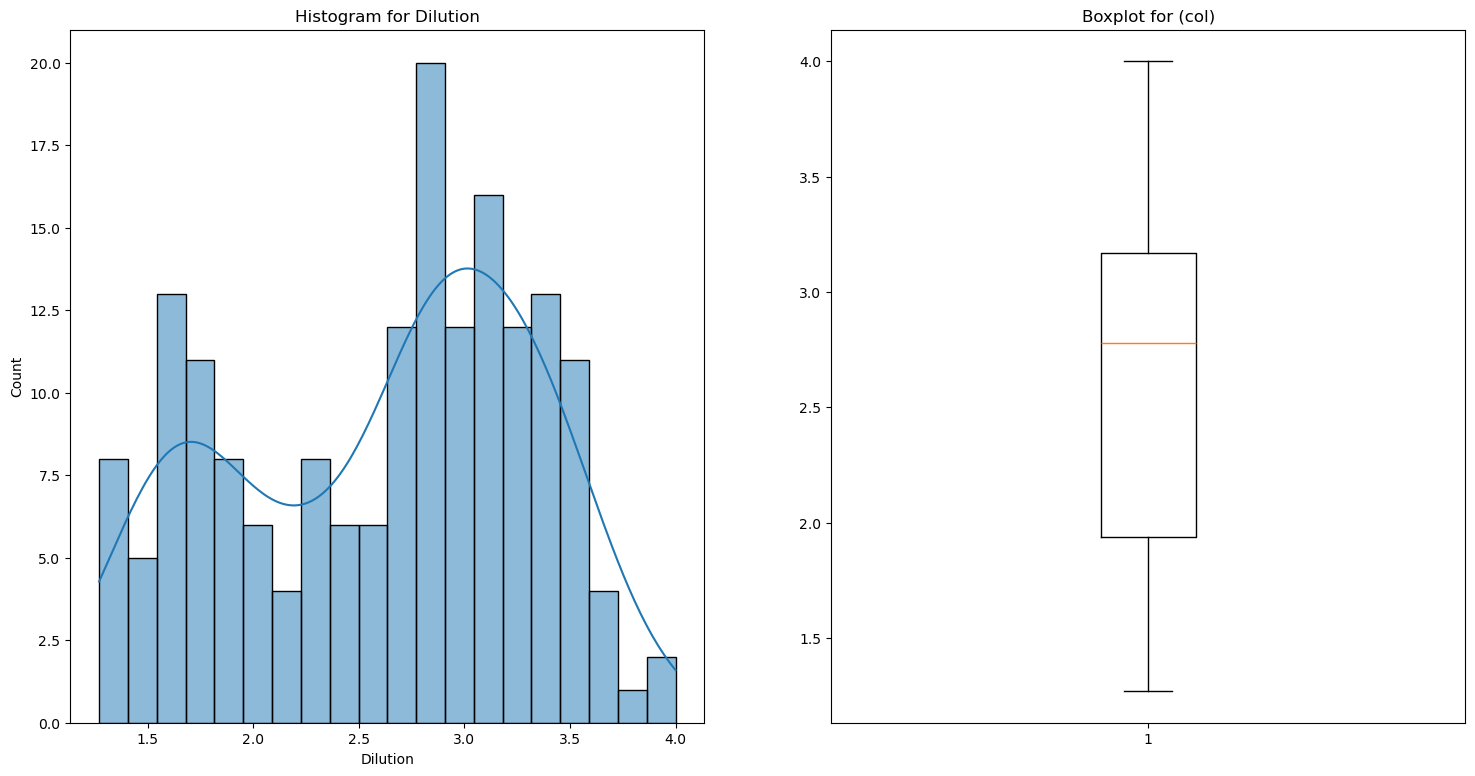

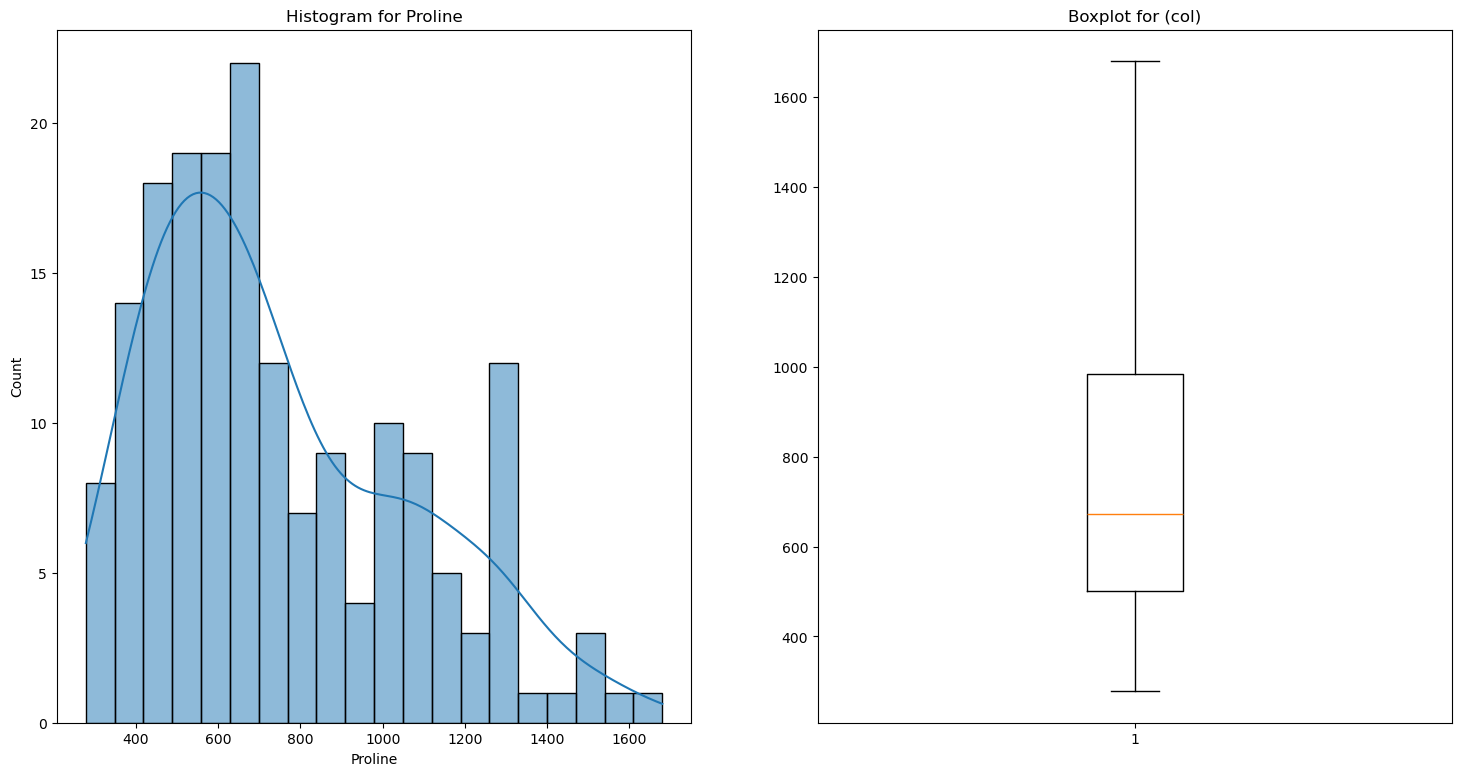

In [2]:
target = 'Type'
numerical_cols = [col for col in df.columns.tolist() if col != 'Type']

# Univariate data analysis
for col in numerical_cols:
    plt.figure(figsize=(18,9))

    plt.subplot(1,2,1)
    plt.title(f"Histogram for {col}")
    sns.histplot(df[col],kde=True,bins=20)

    plt.subplot(1,2,2)
    plt.title(f"Boxplot for (col)")
    plt.boxplot(df[col])

    plt.show()

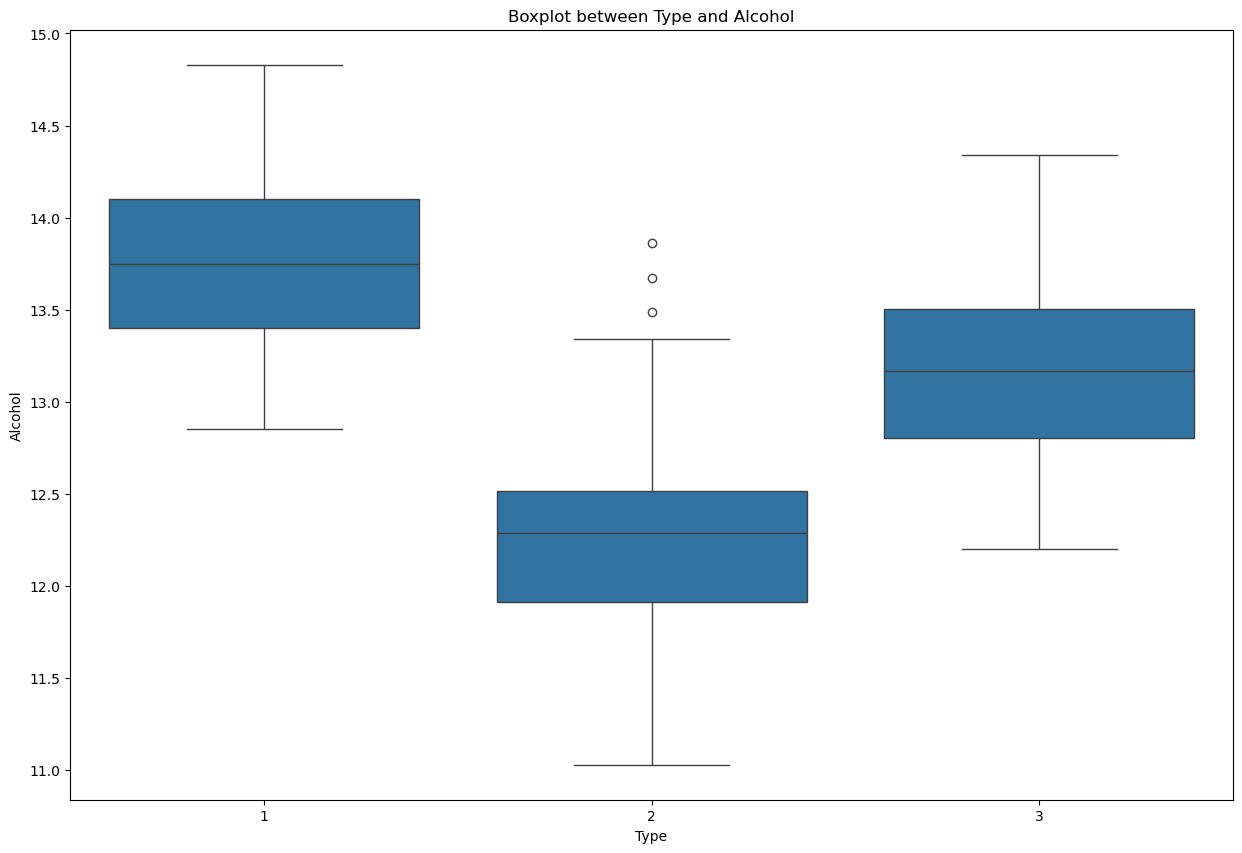

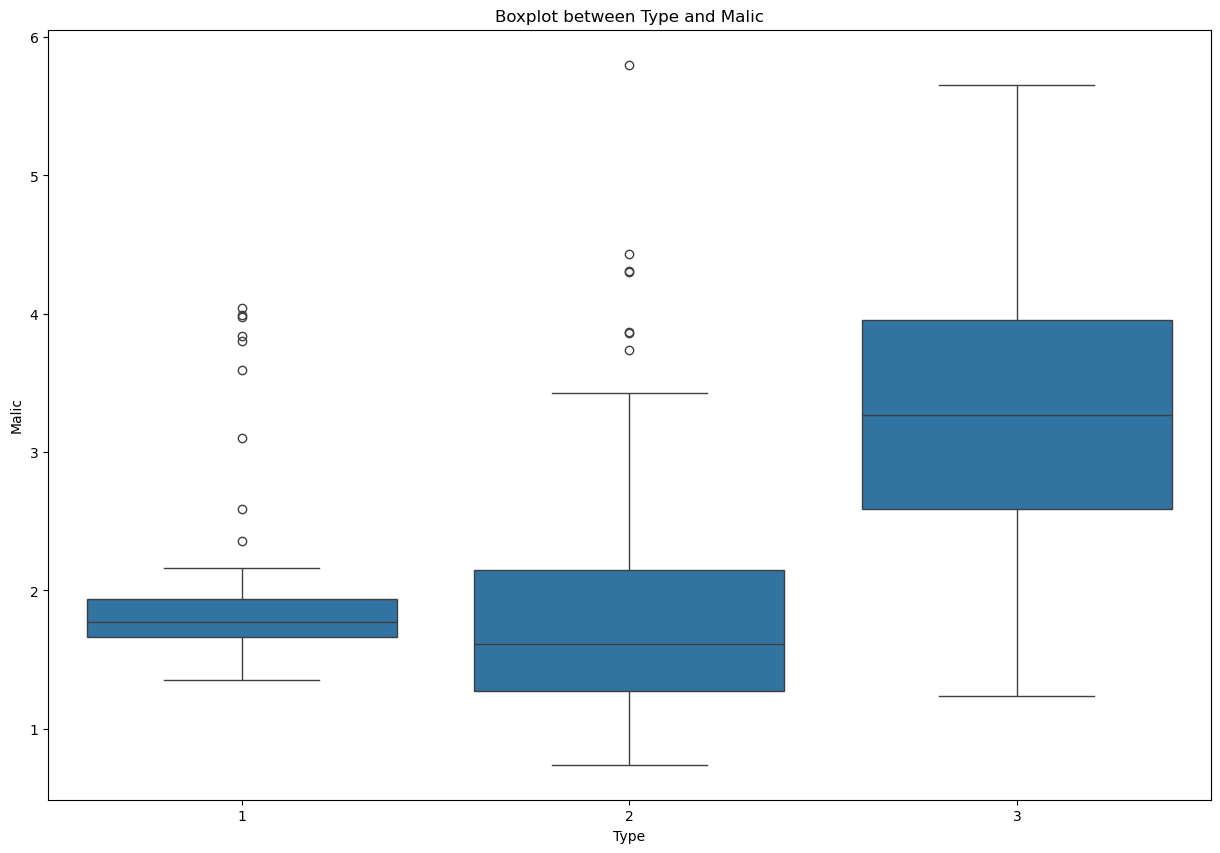

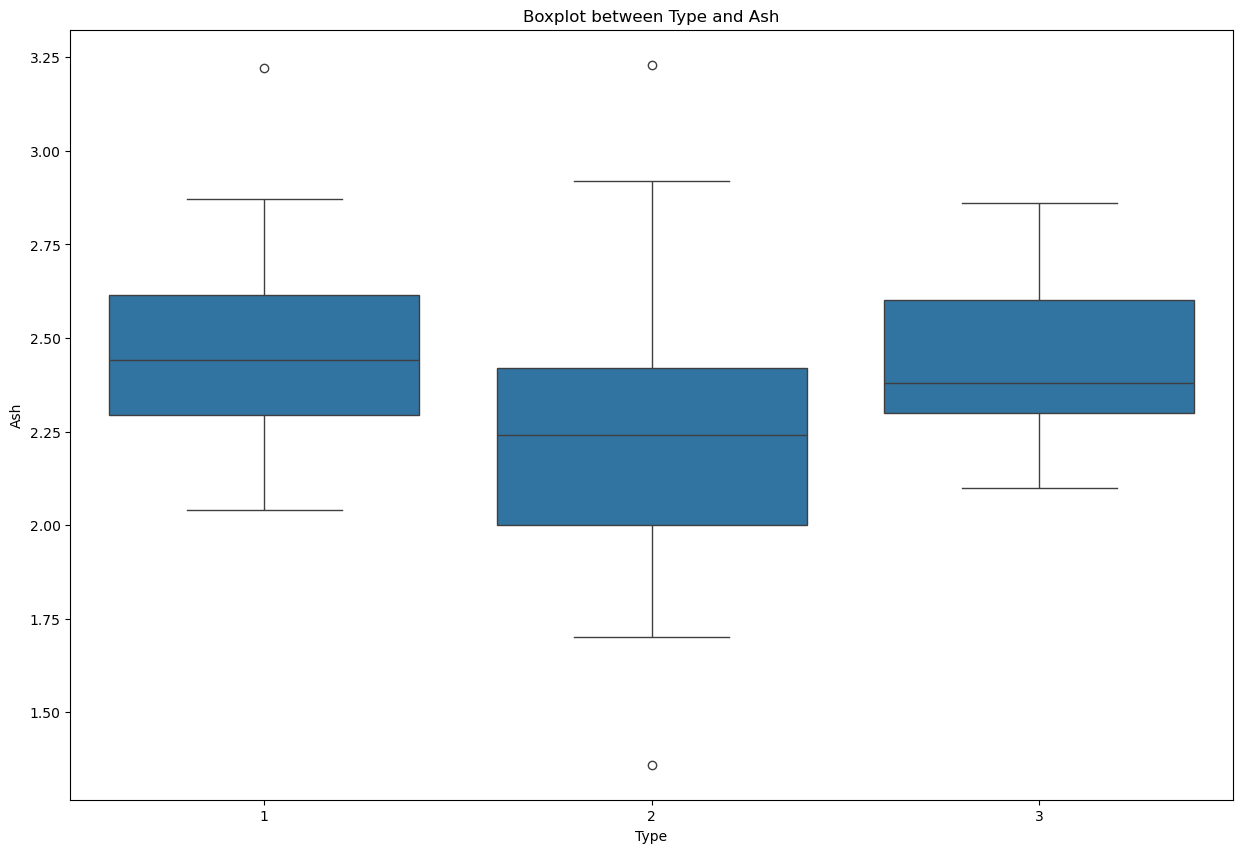

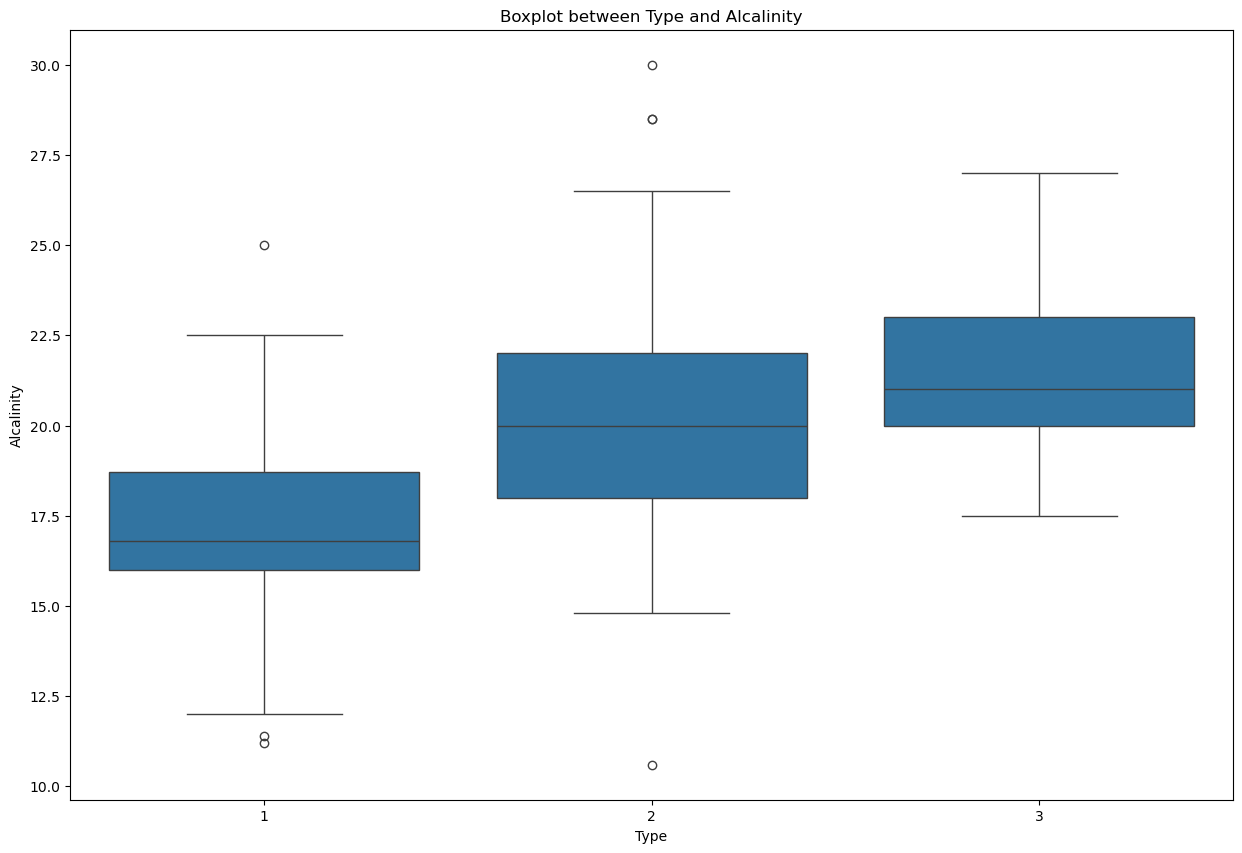

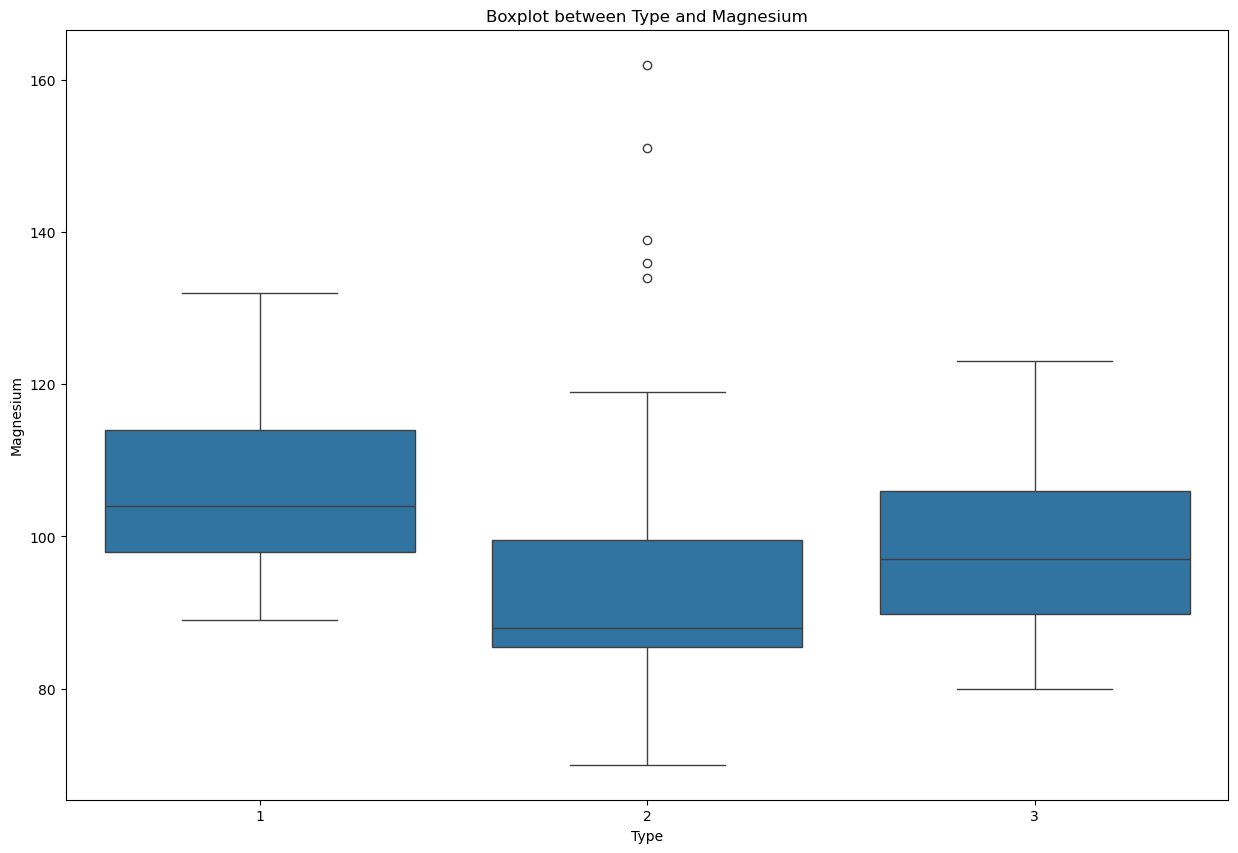

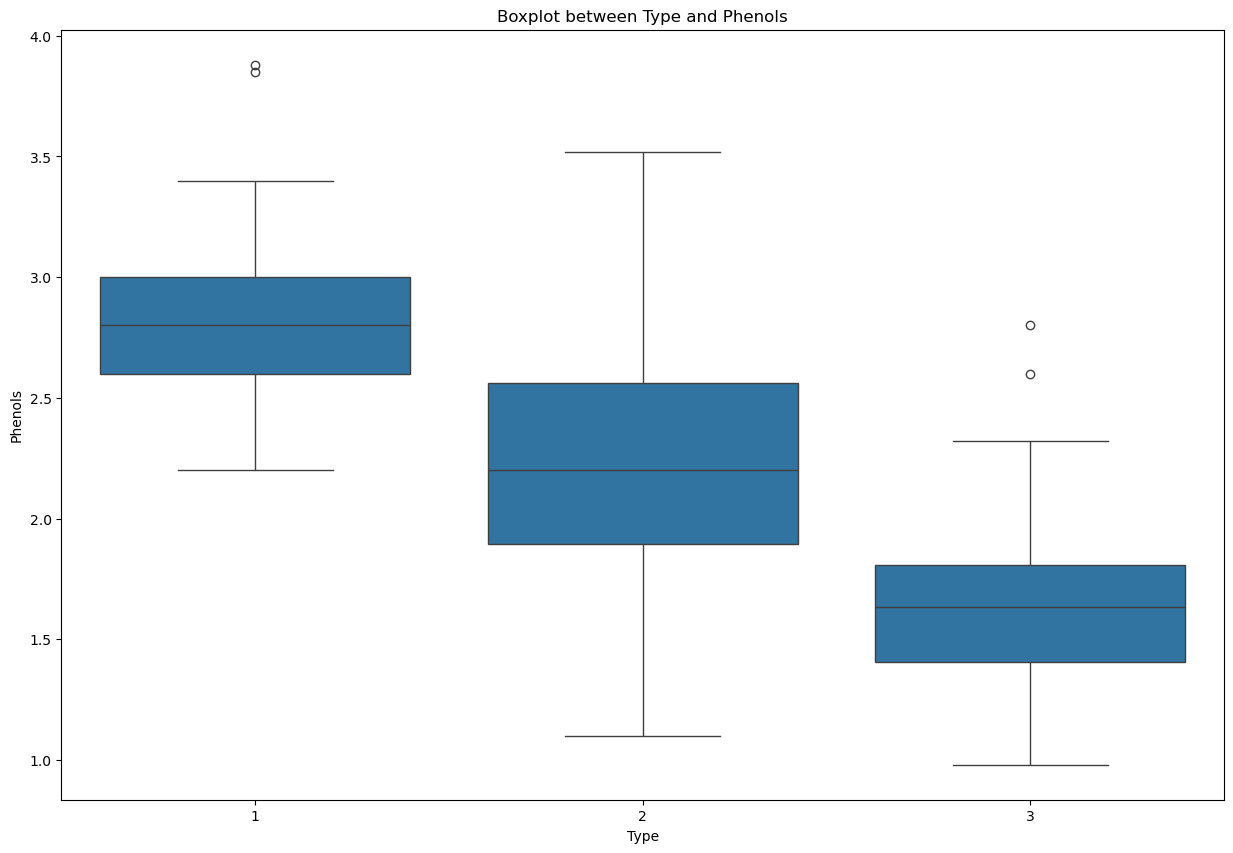

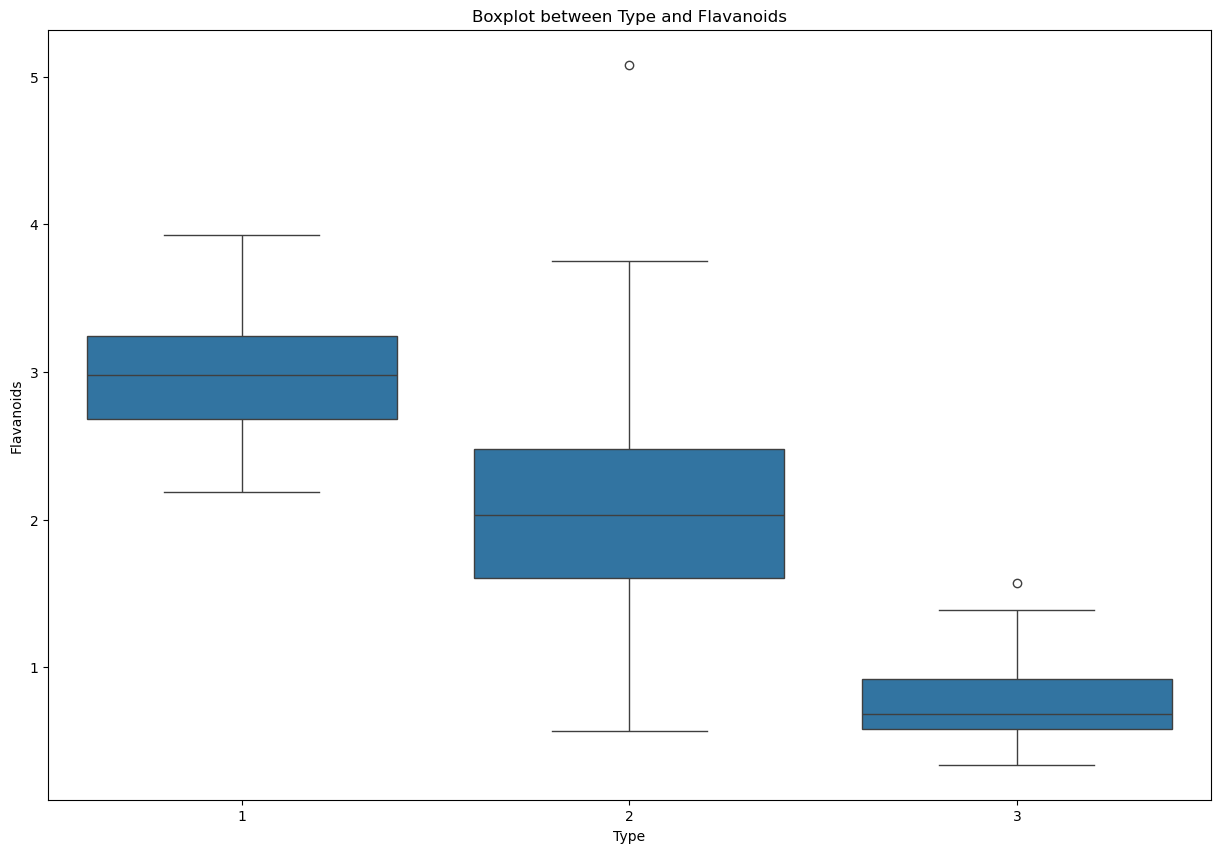

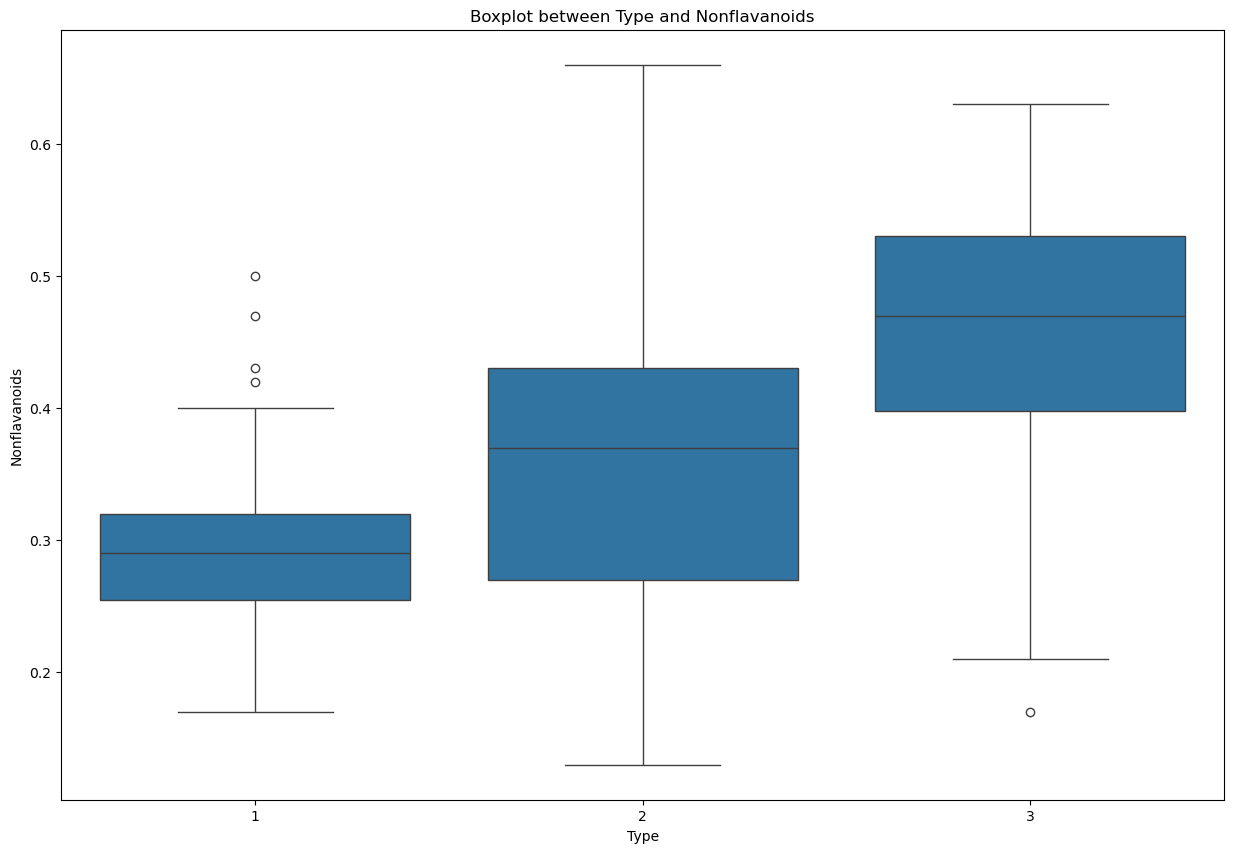

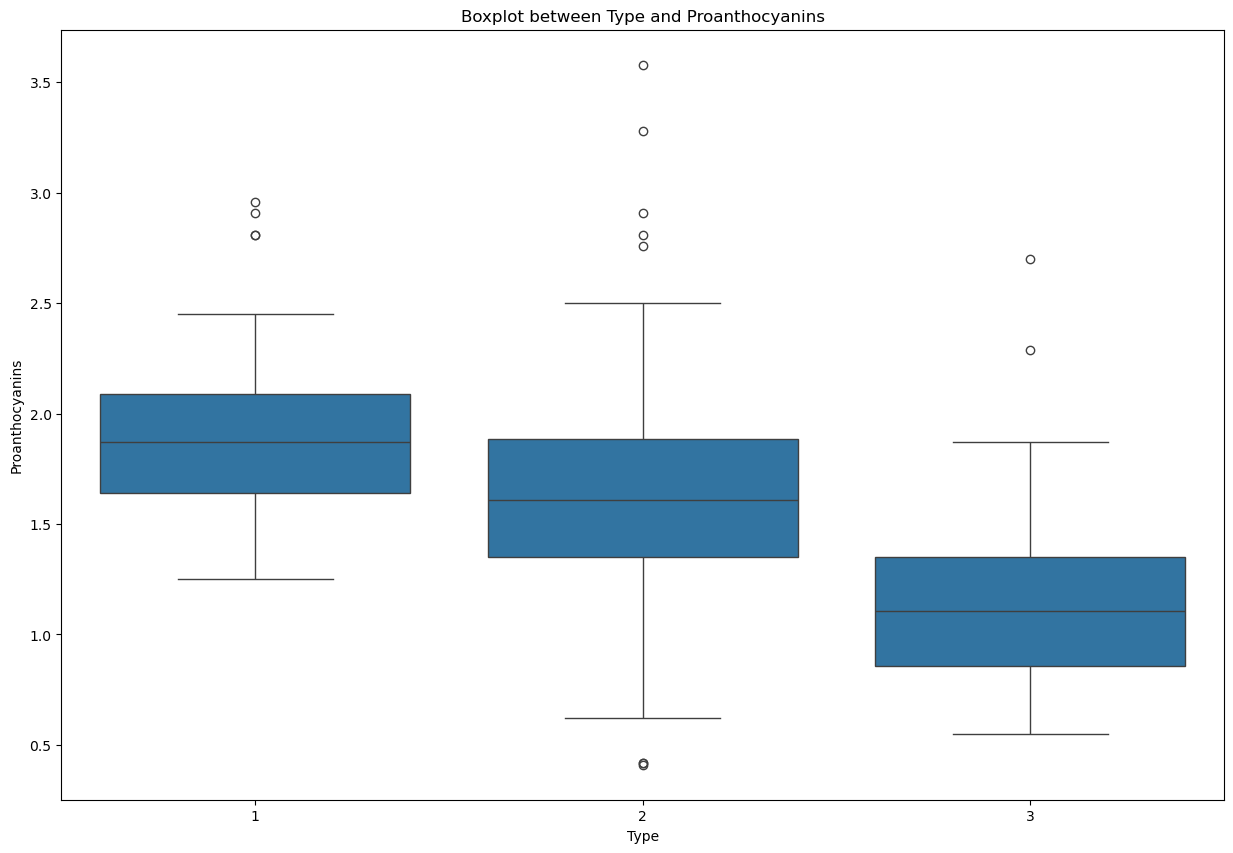

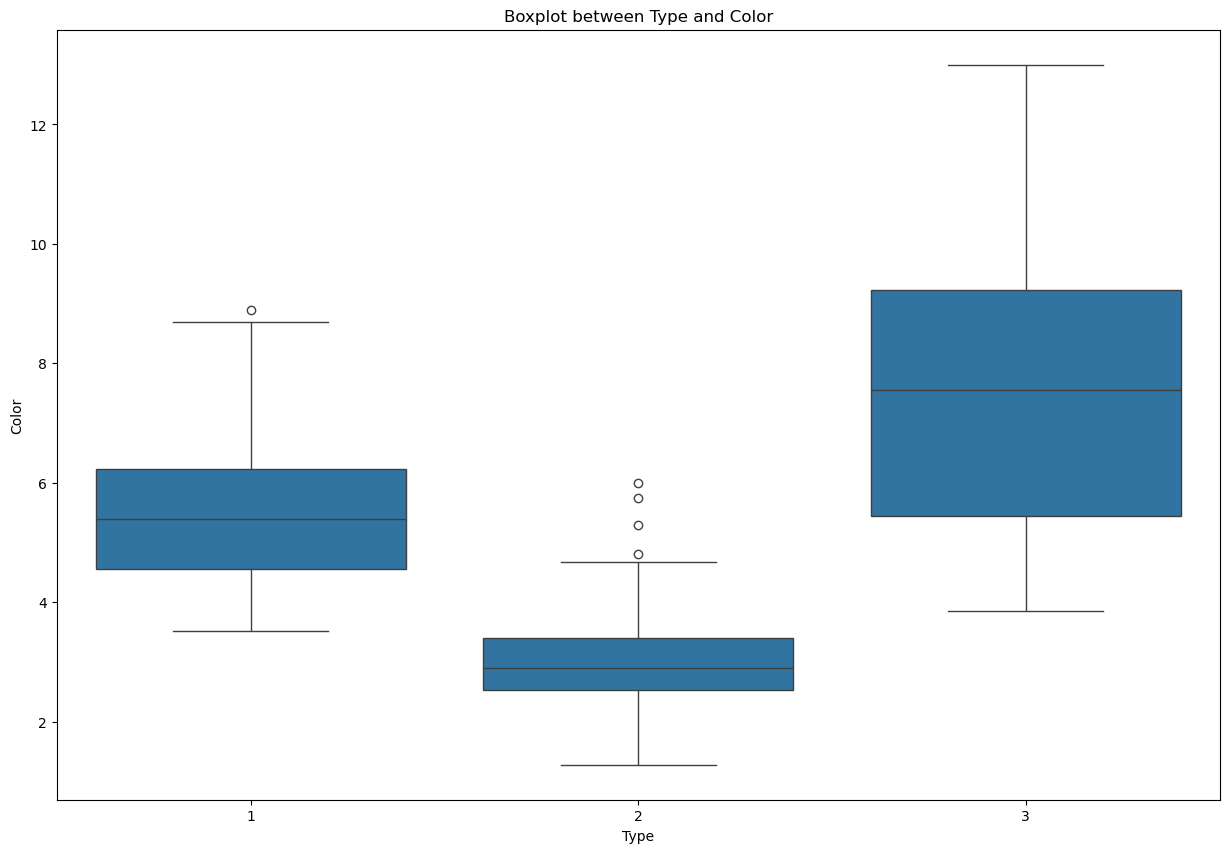

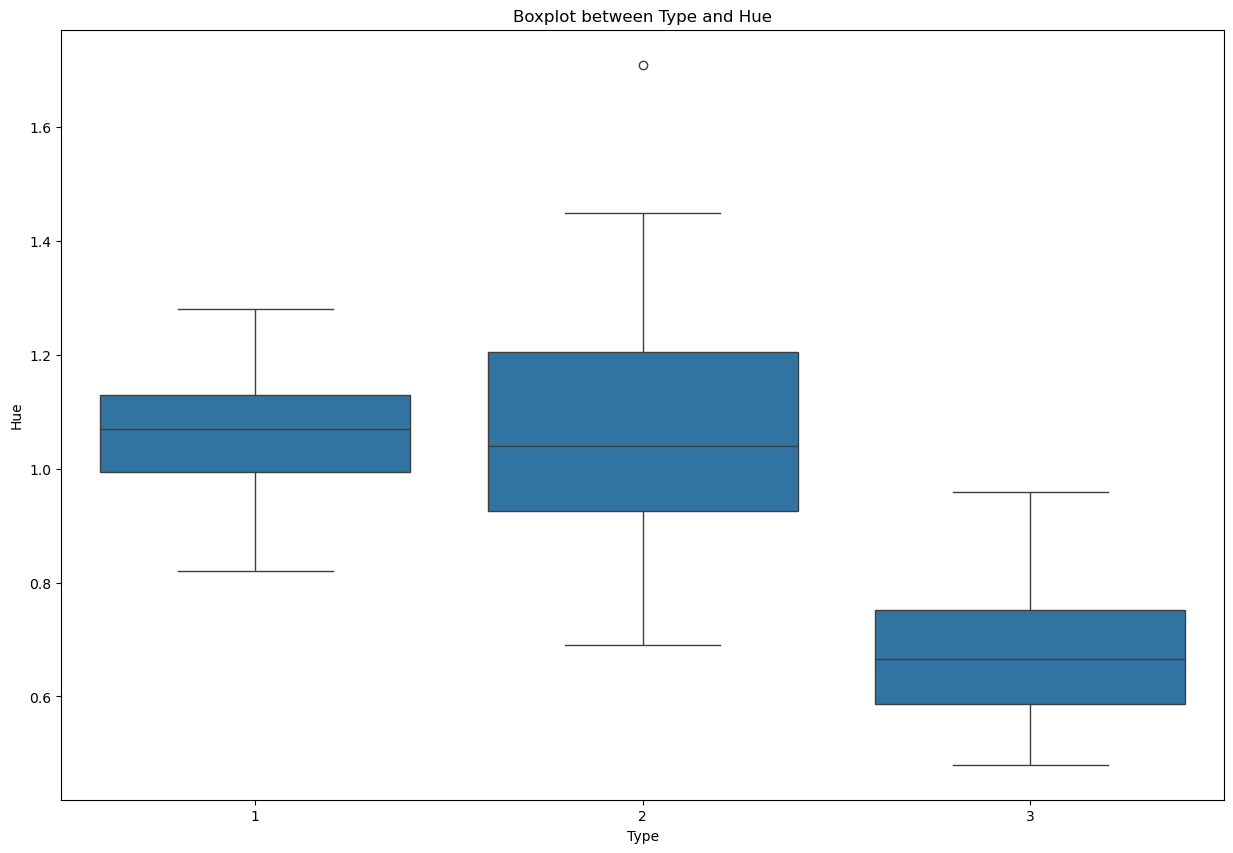

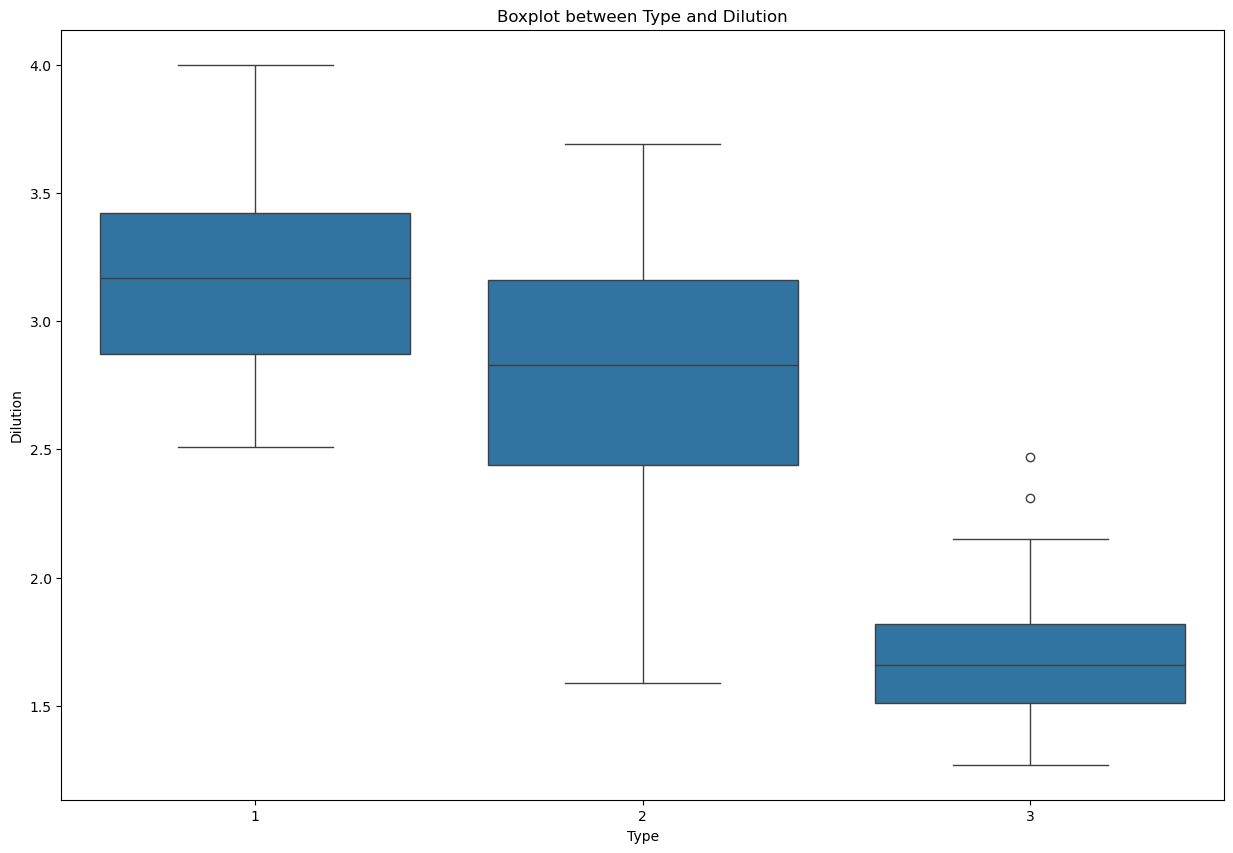

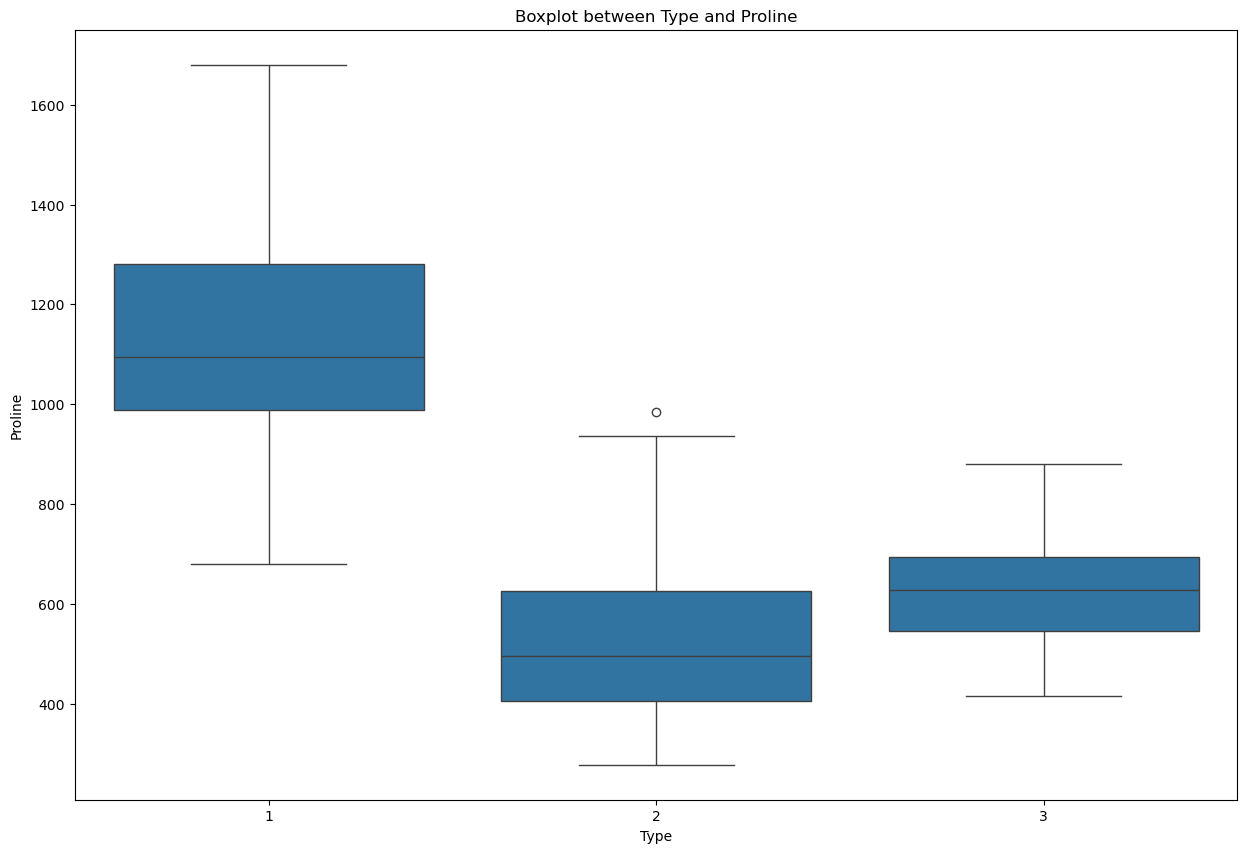

In [3]:
# Bivariate Analysis

# Target variable with the numerical variable
for col in numerical_cols:
    plt.figure(figsize=(15,10))
    sns.boxplot(x=target, y = col, data=df)
    plt.title(f"Boxplot between {target} and {col}")

    plt.show()

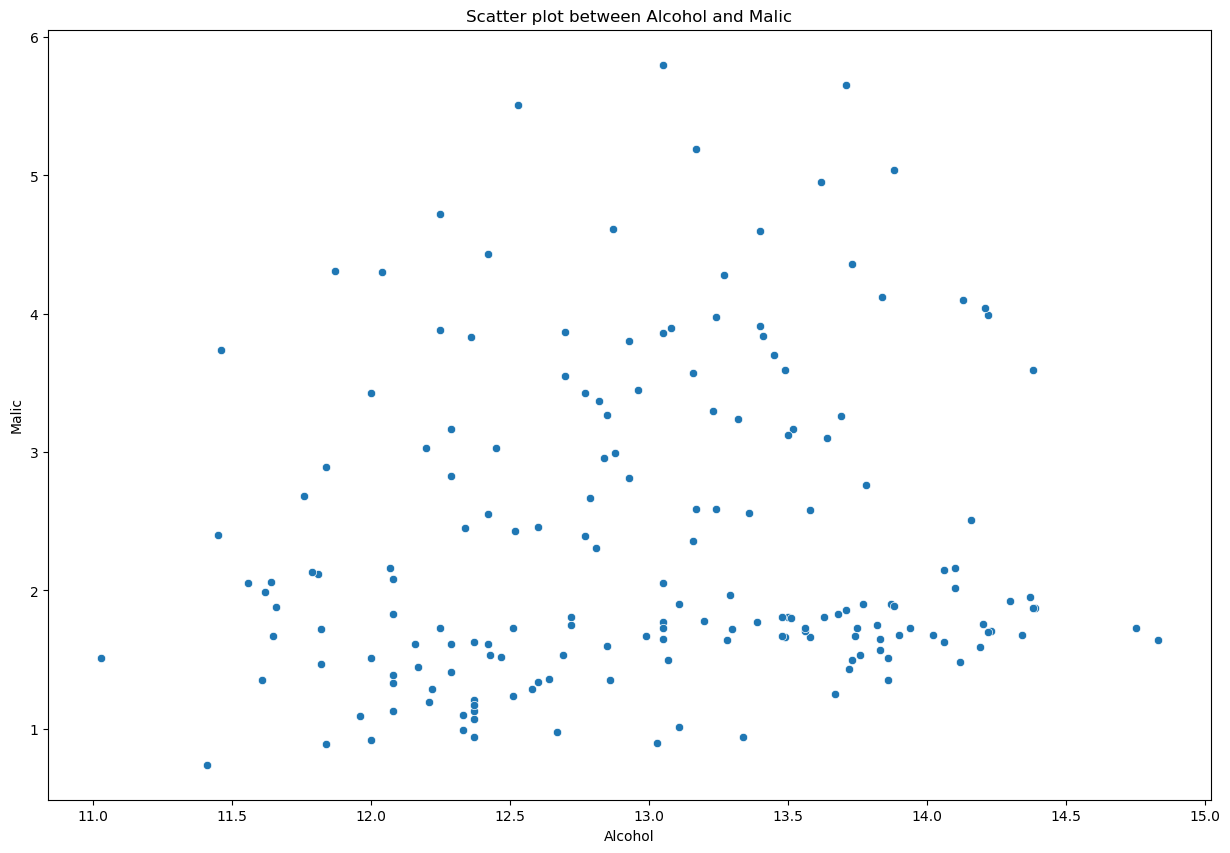

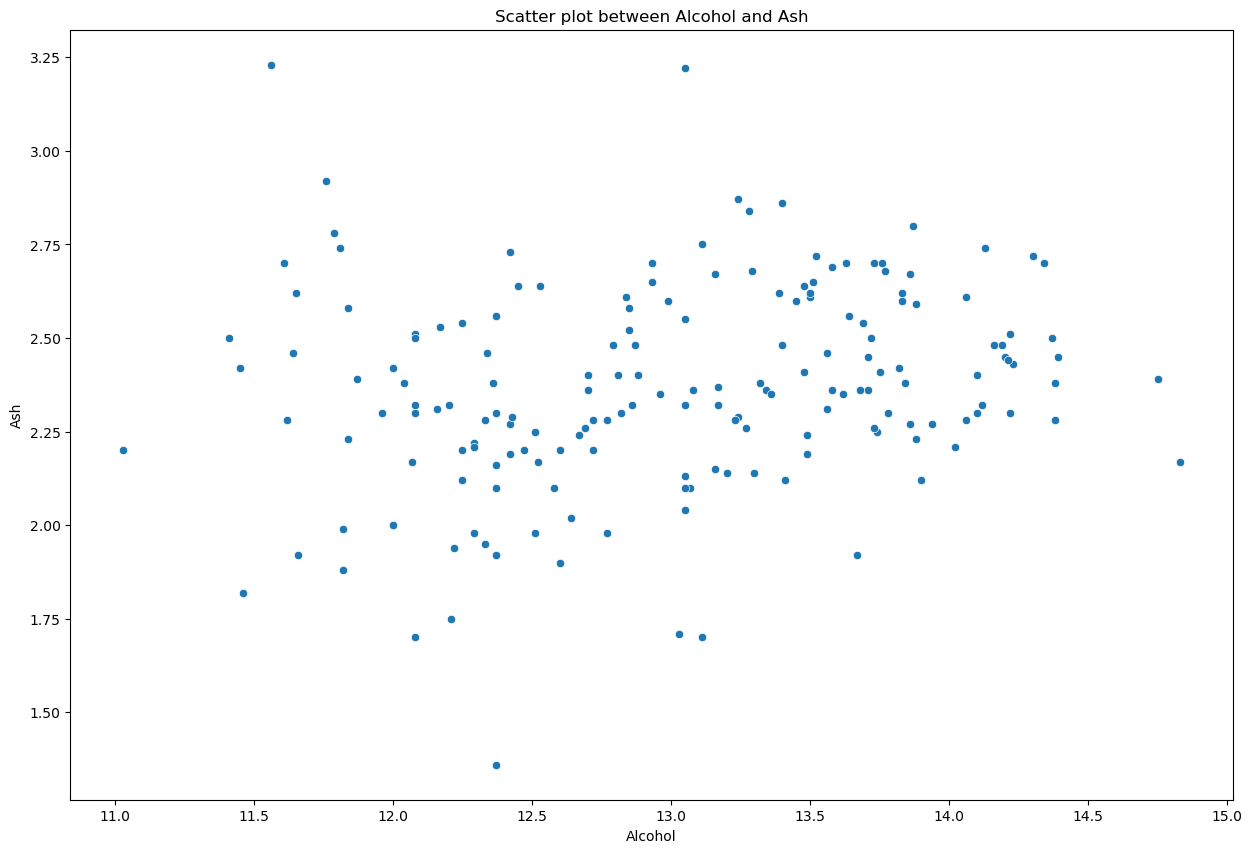

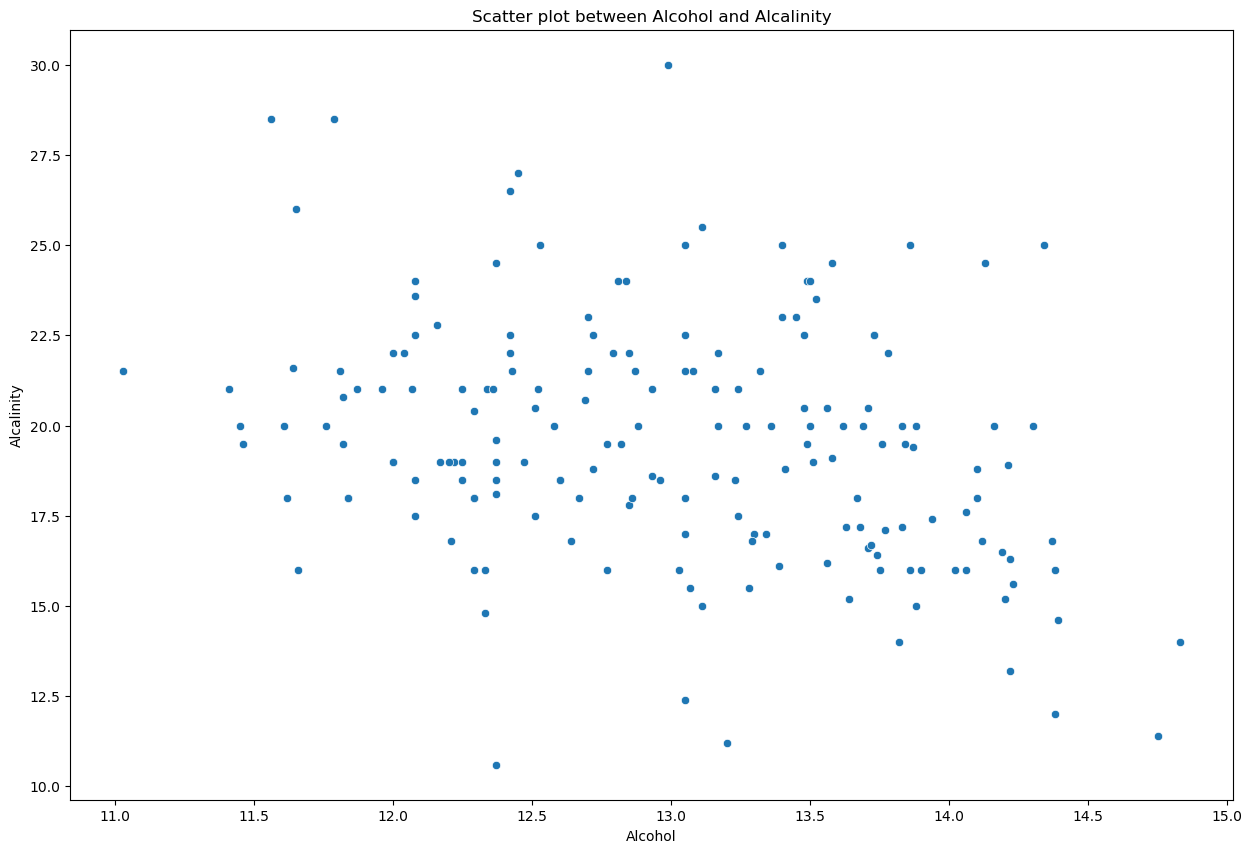

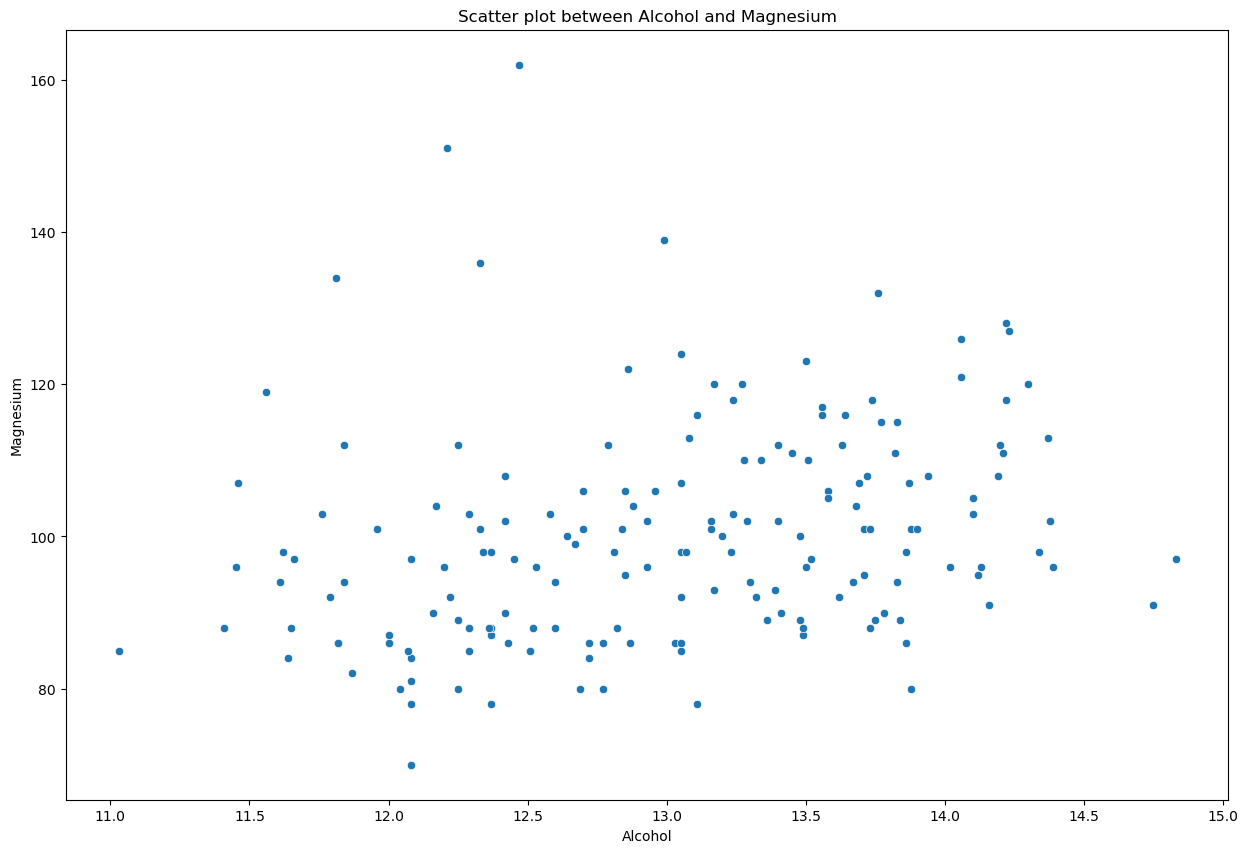

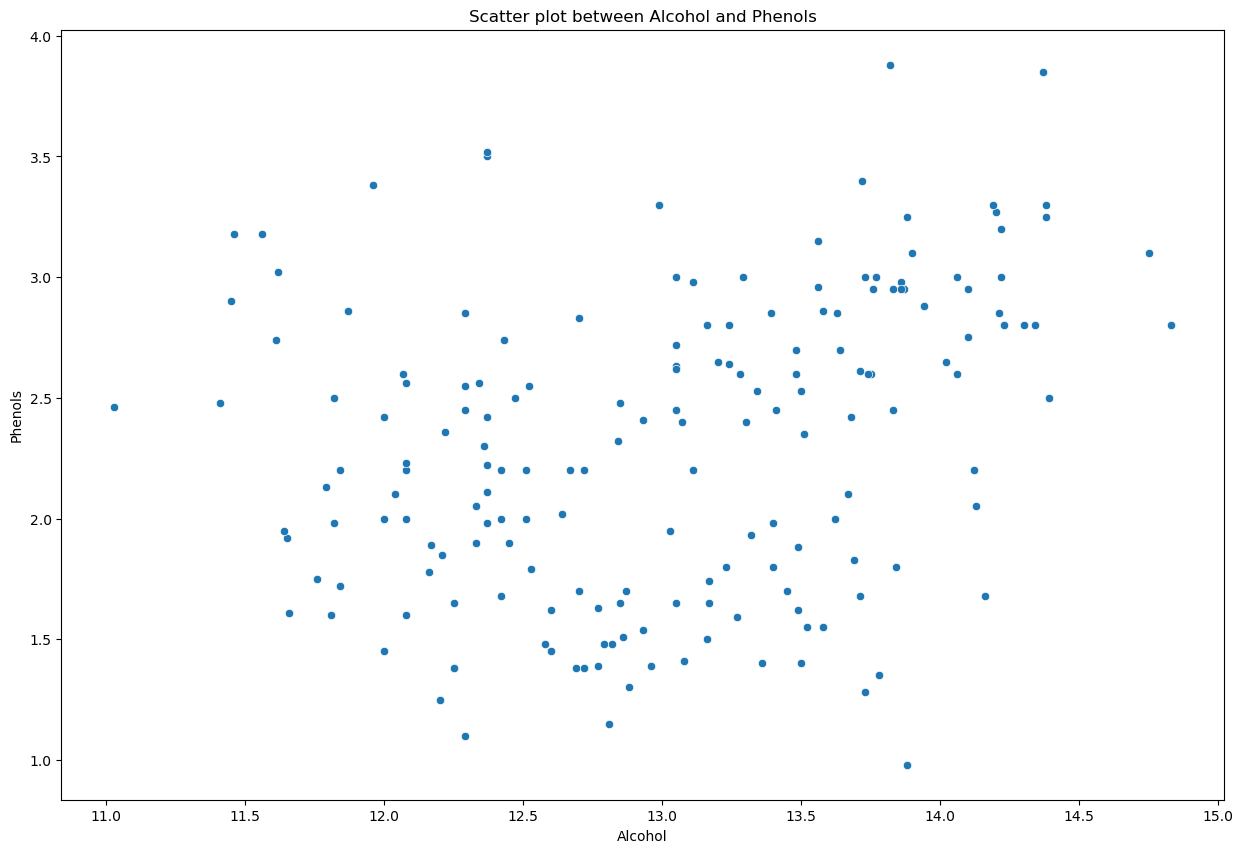

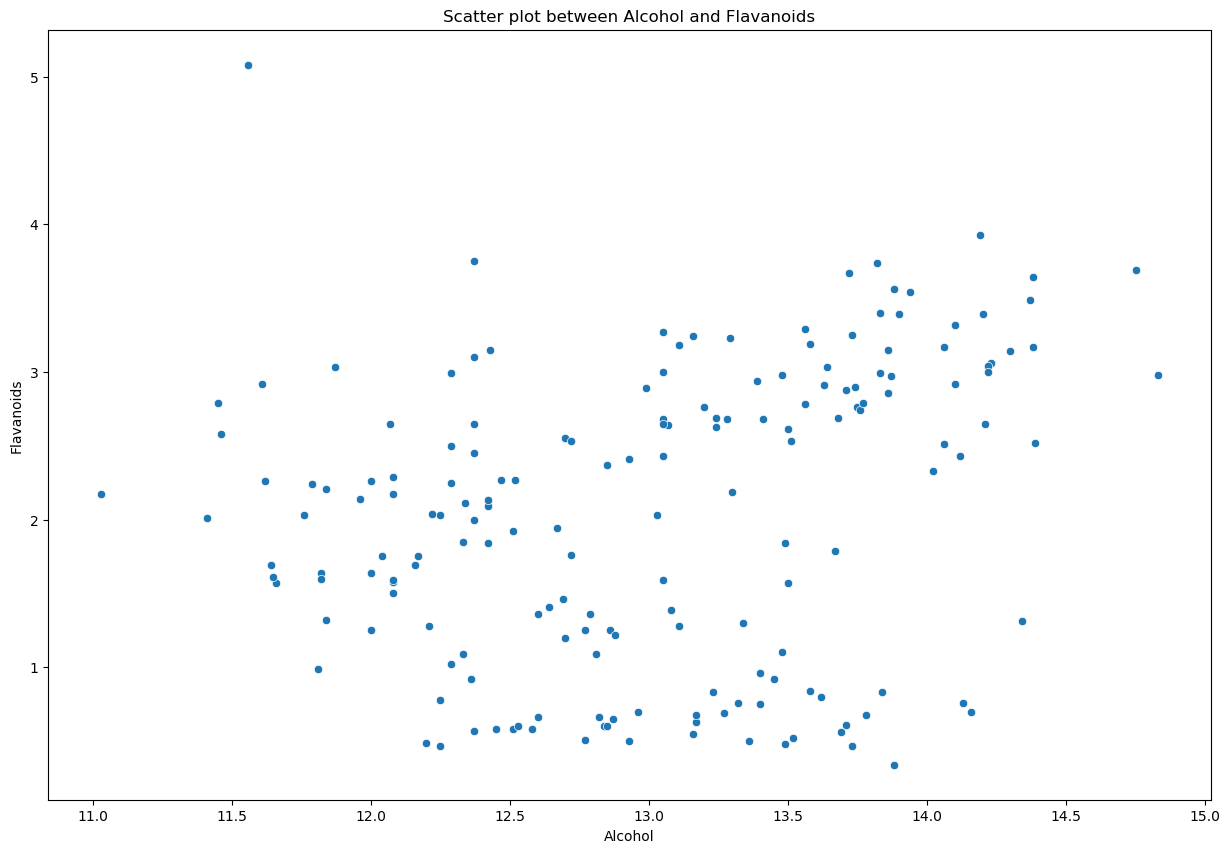

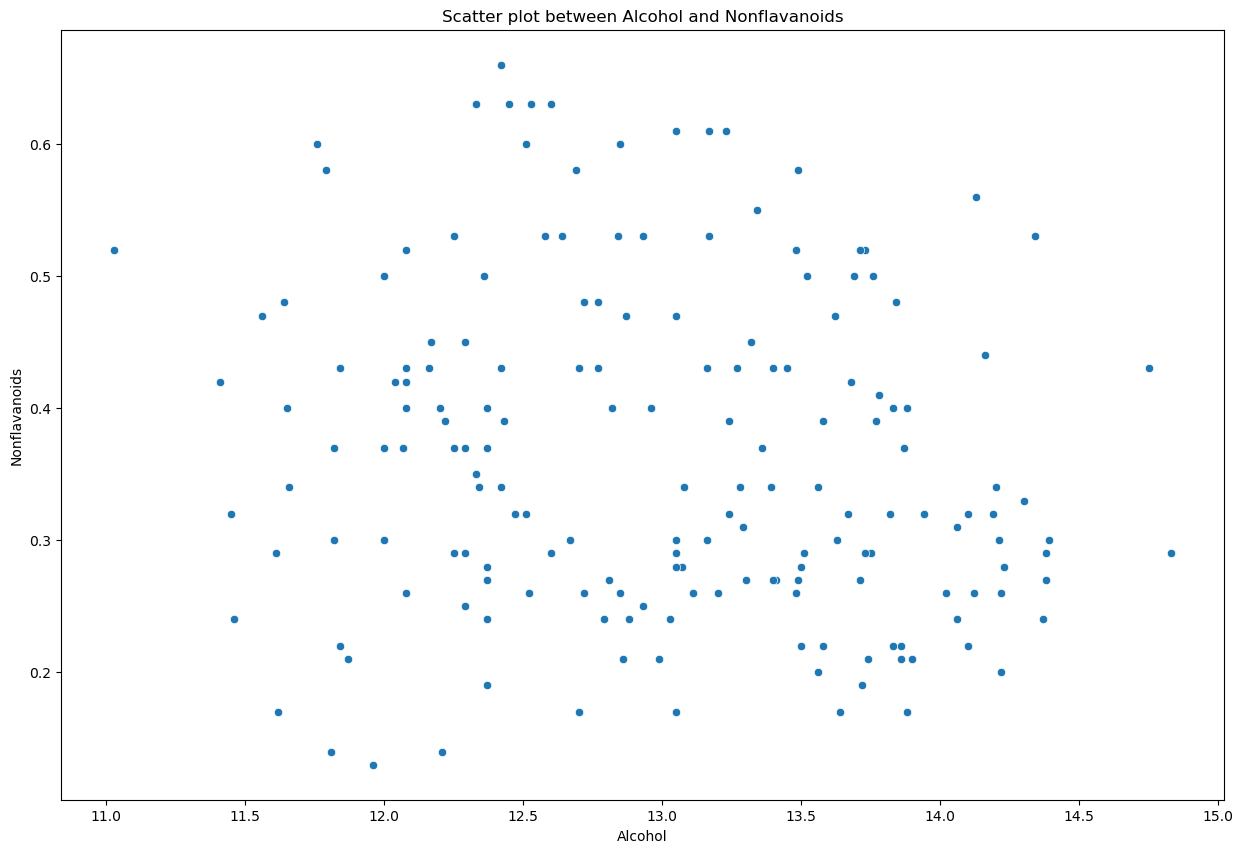

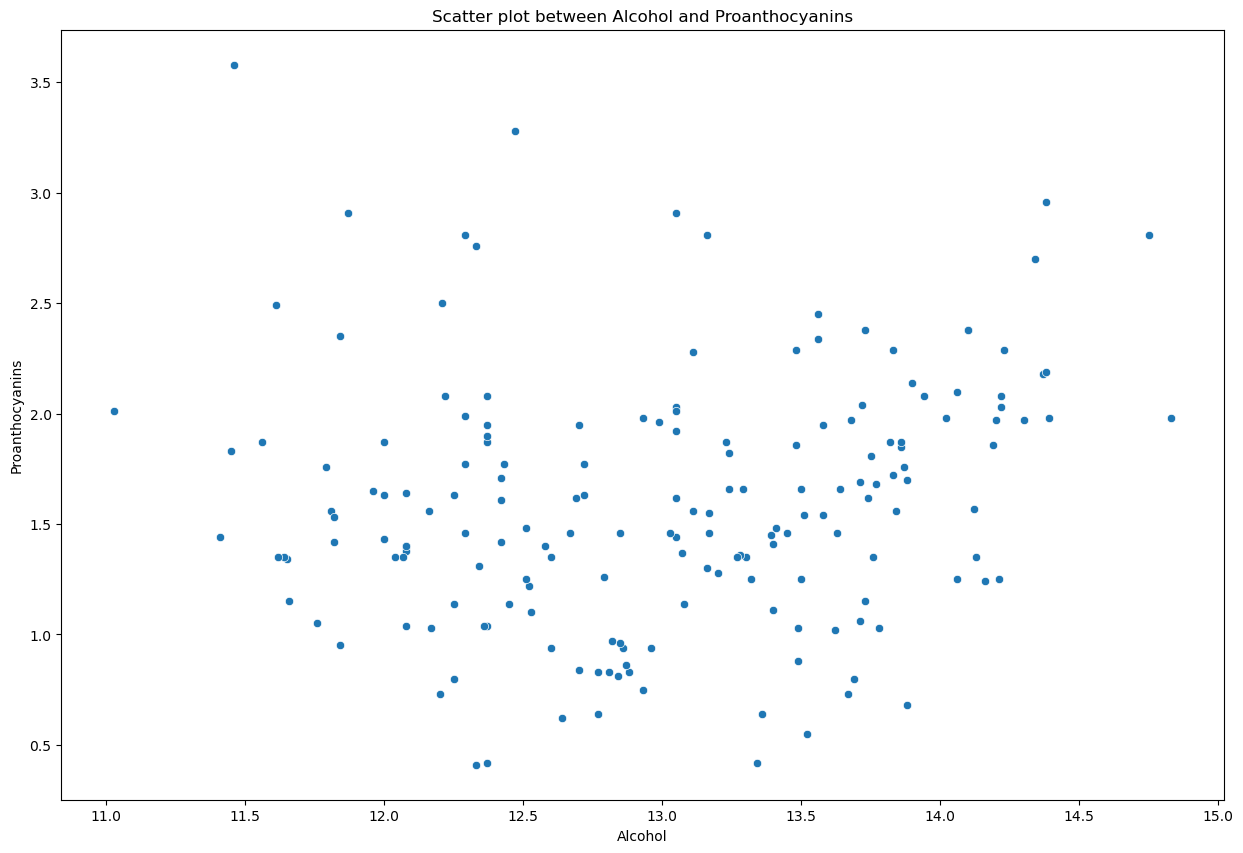

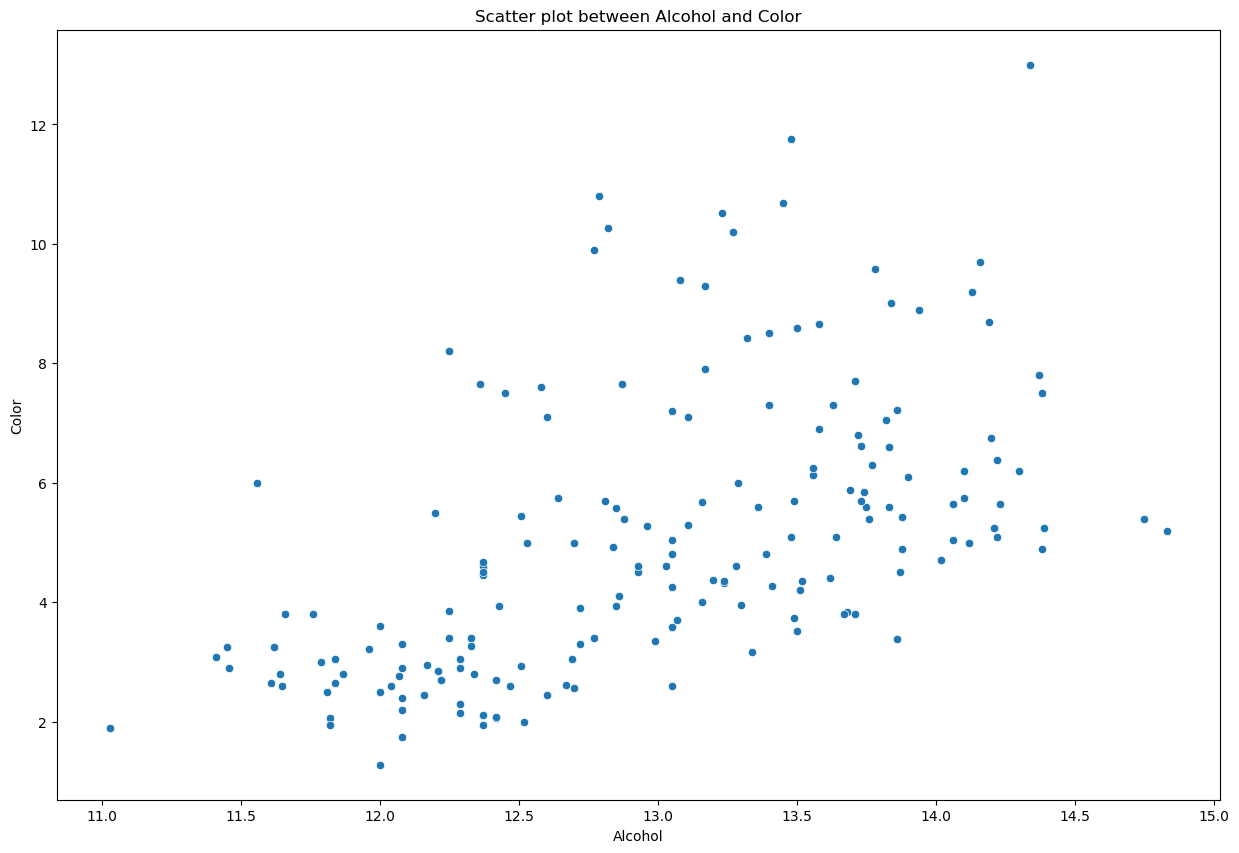

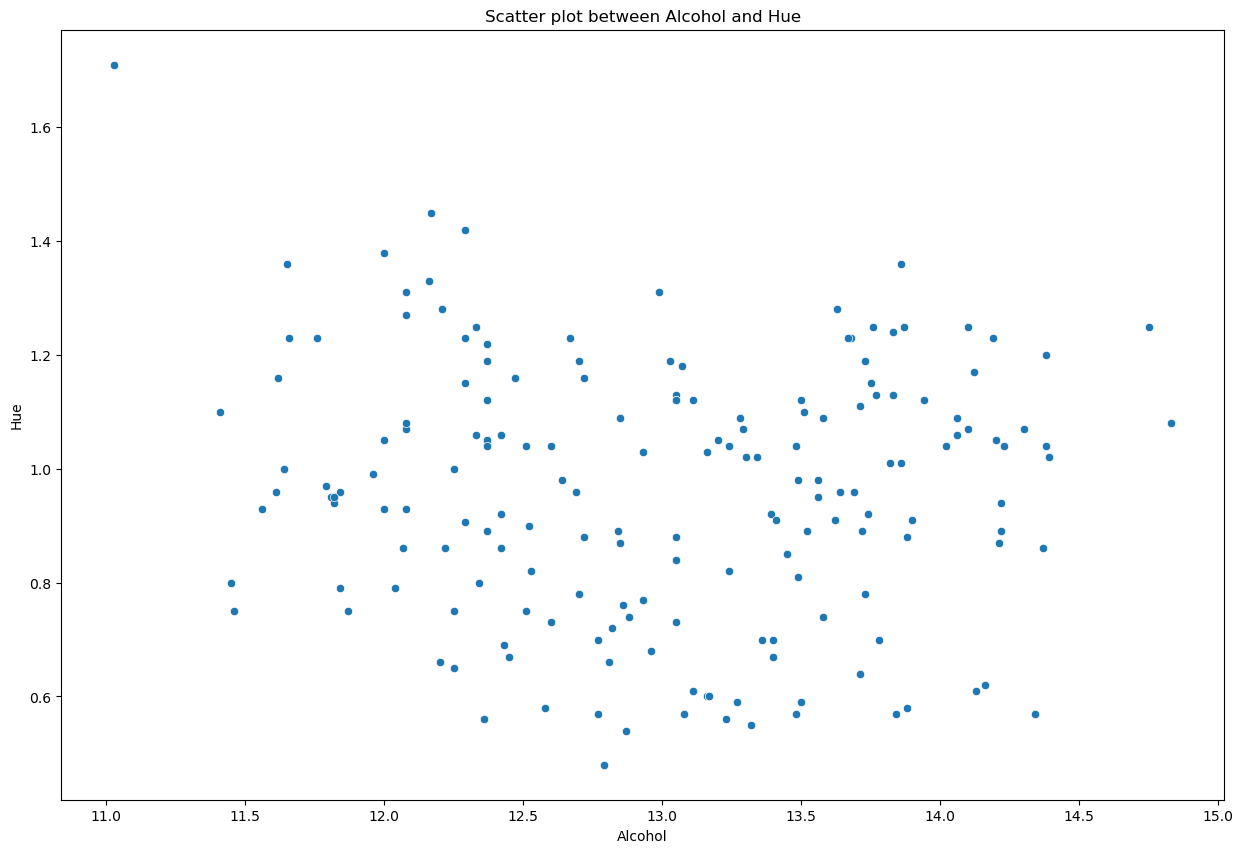

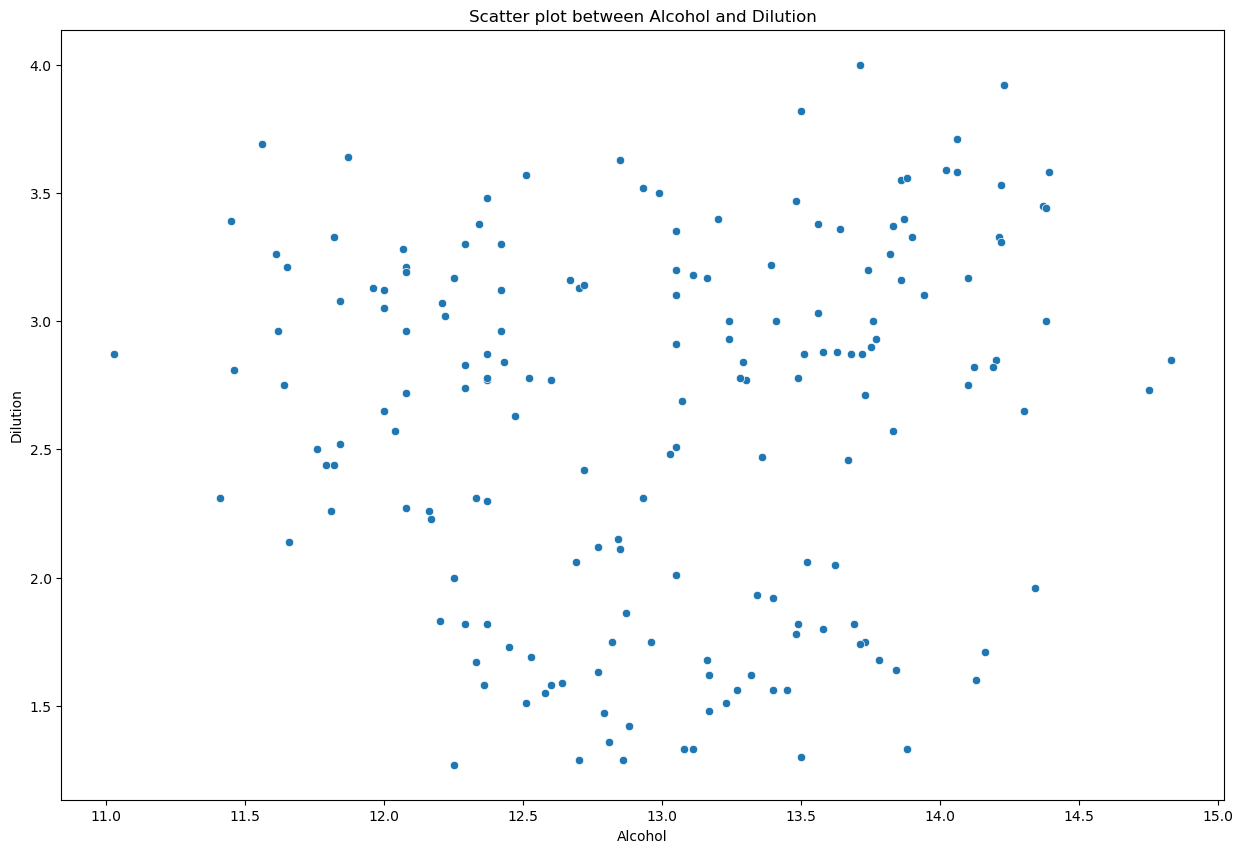

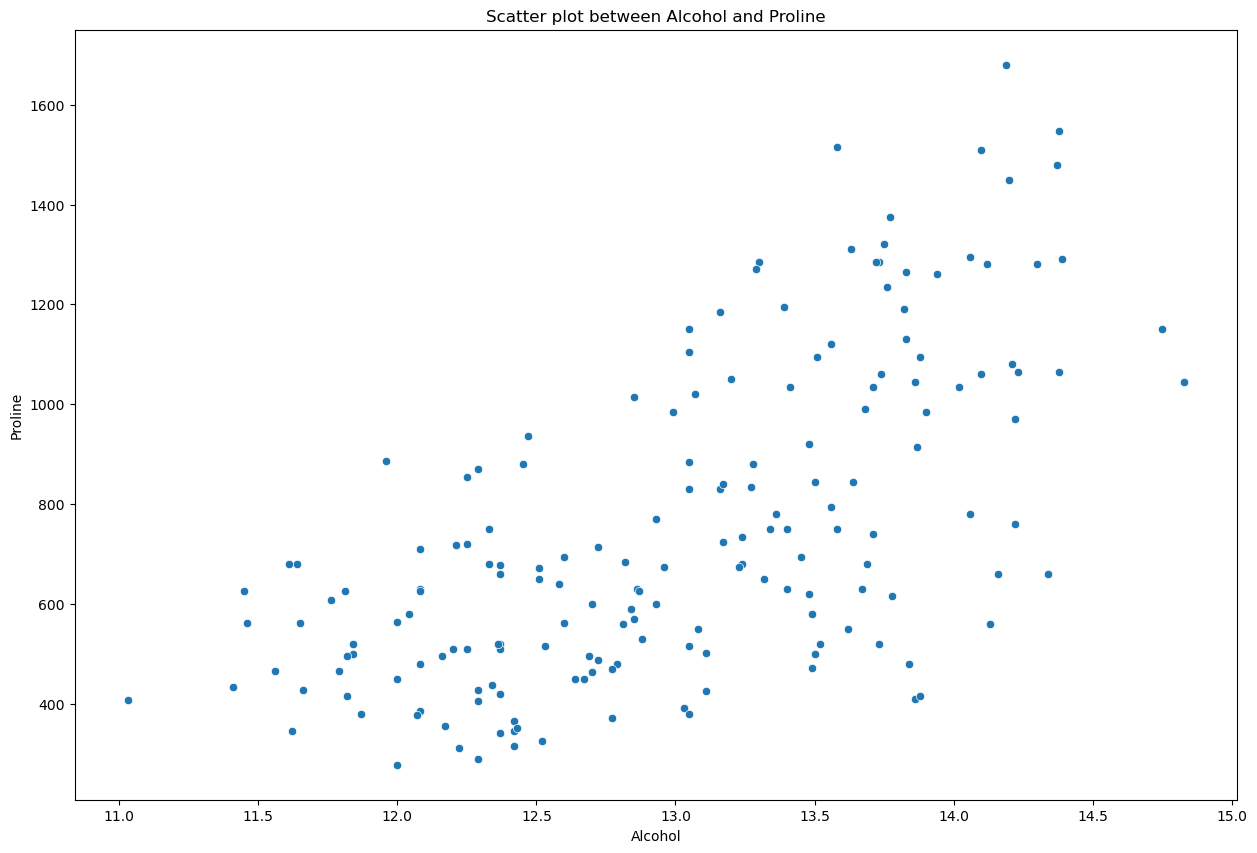

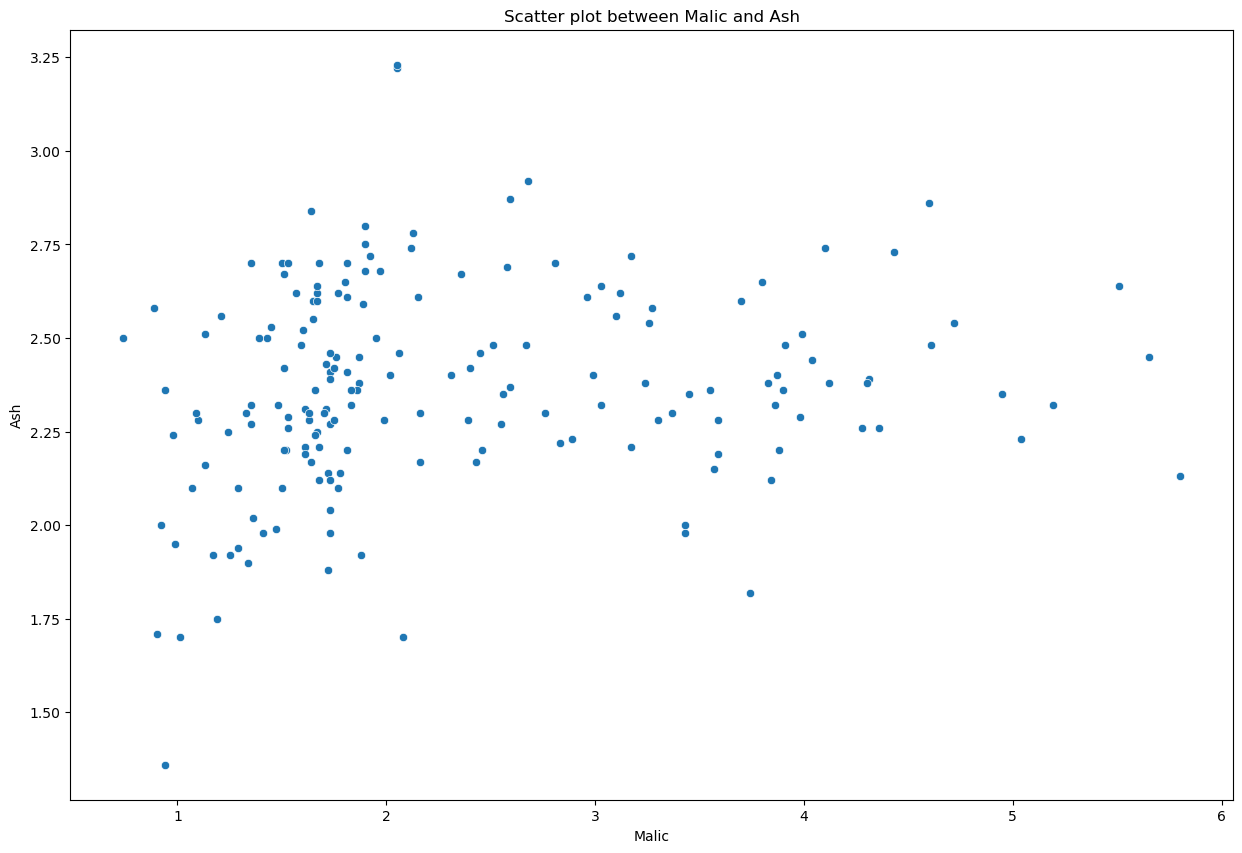

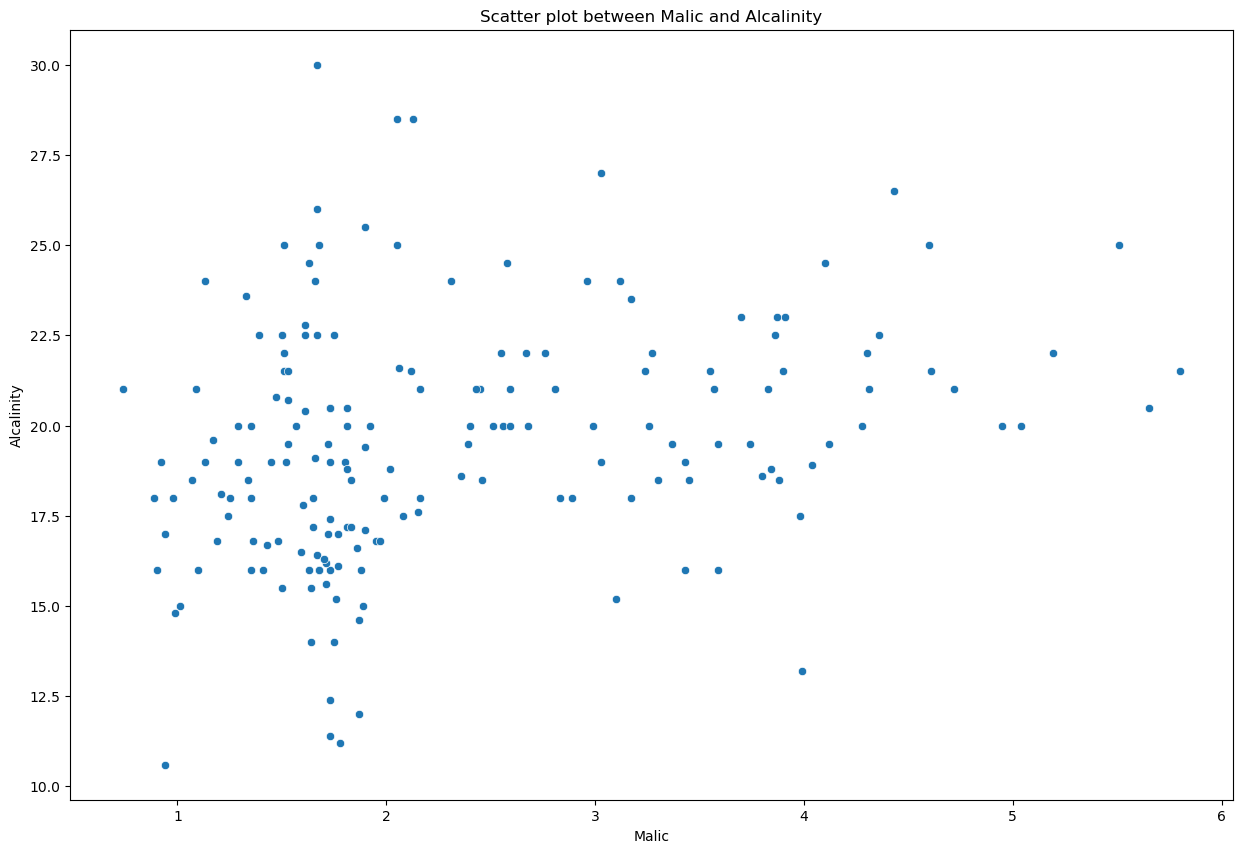

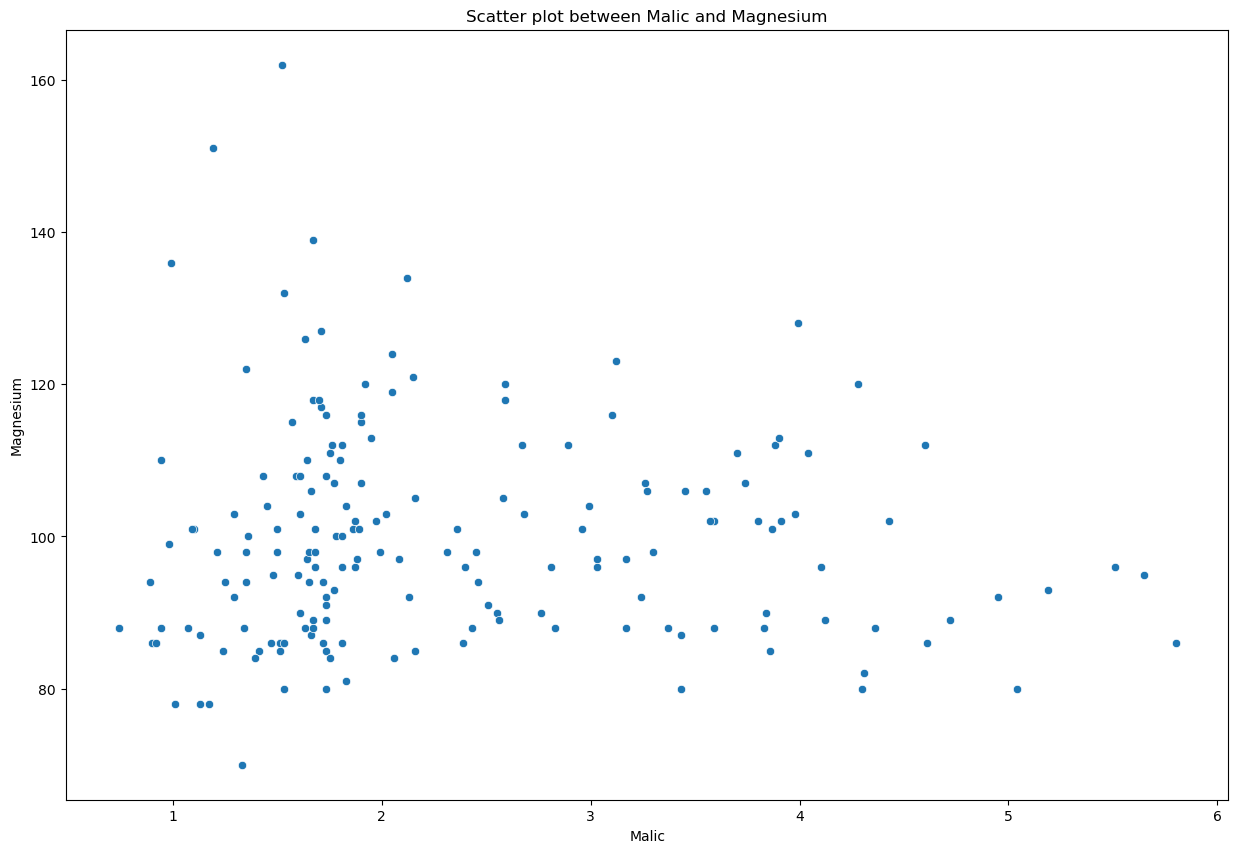

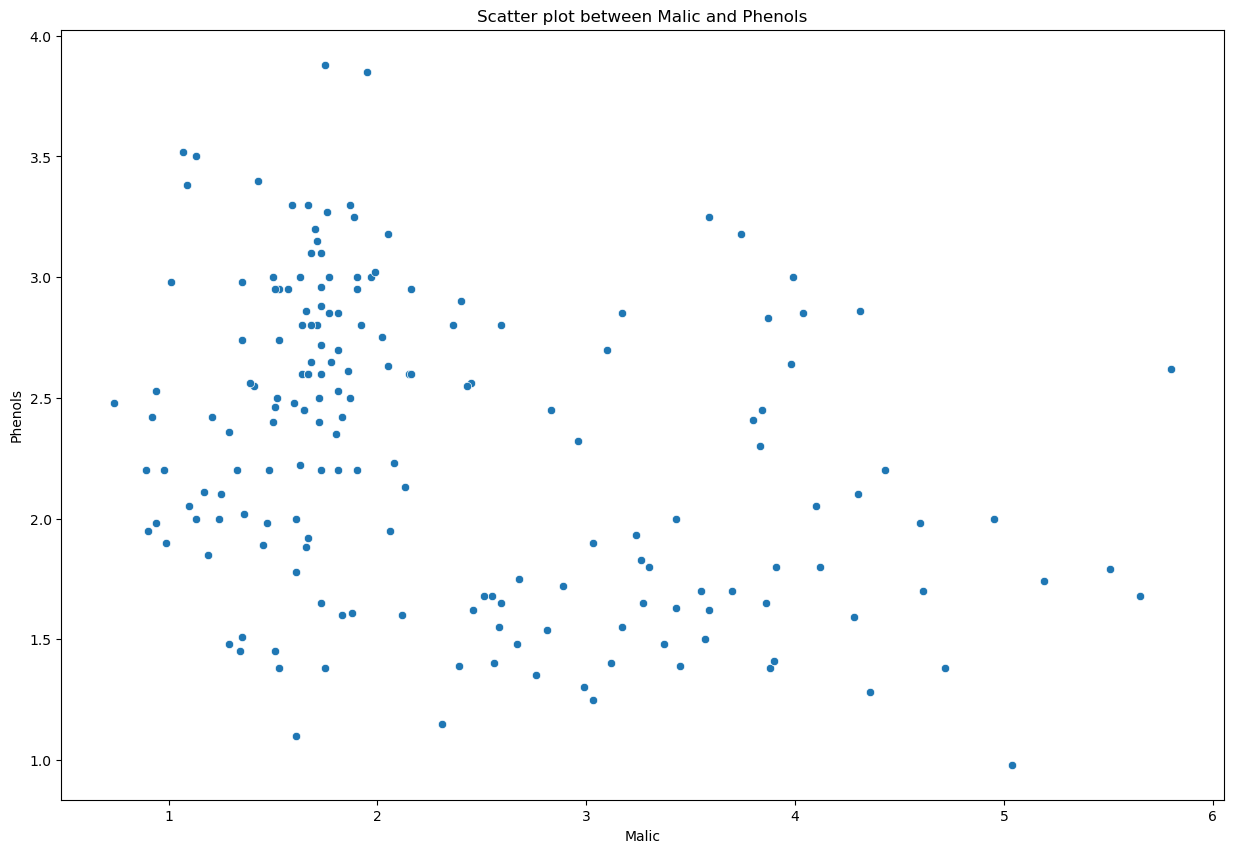

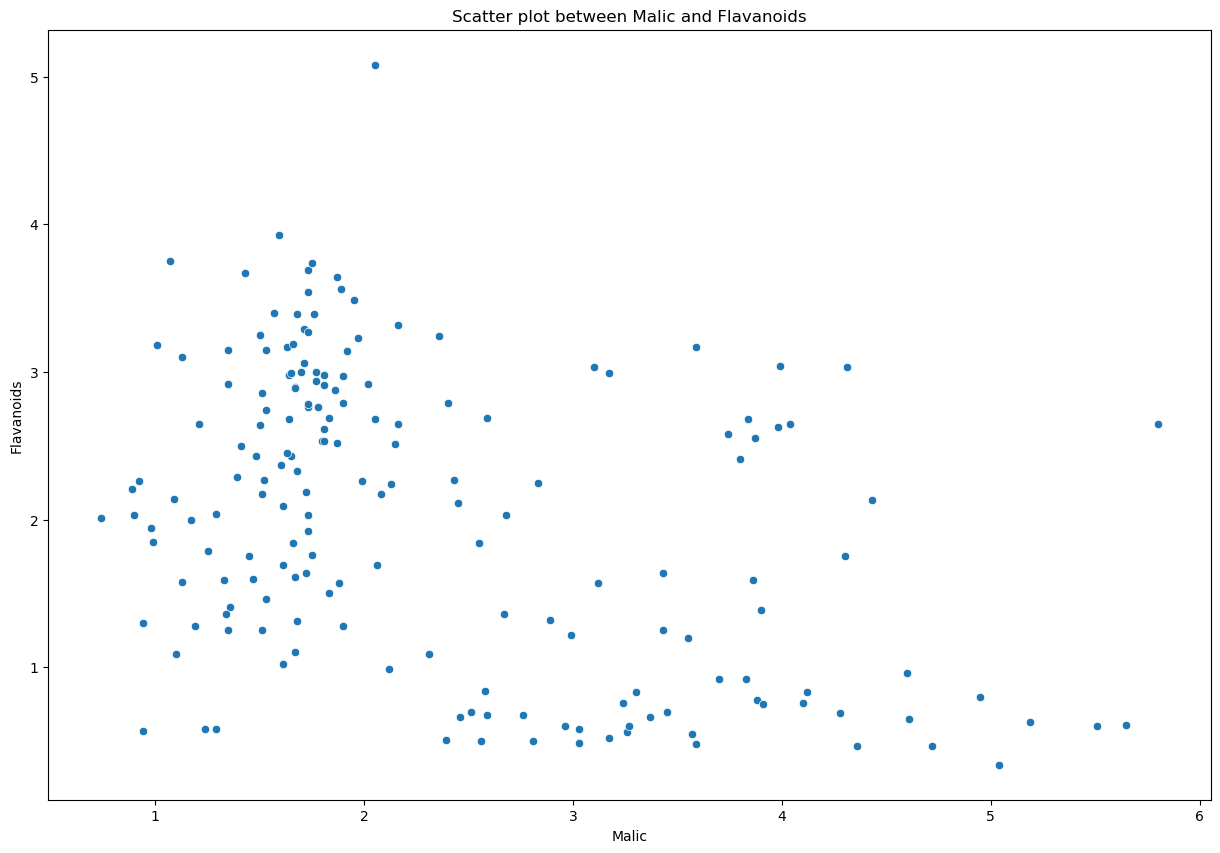

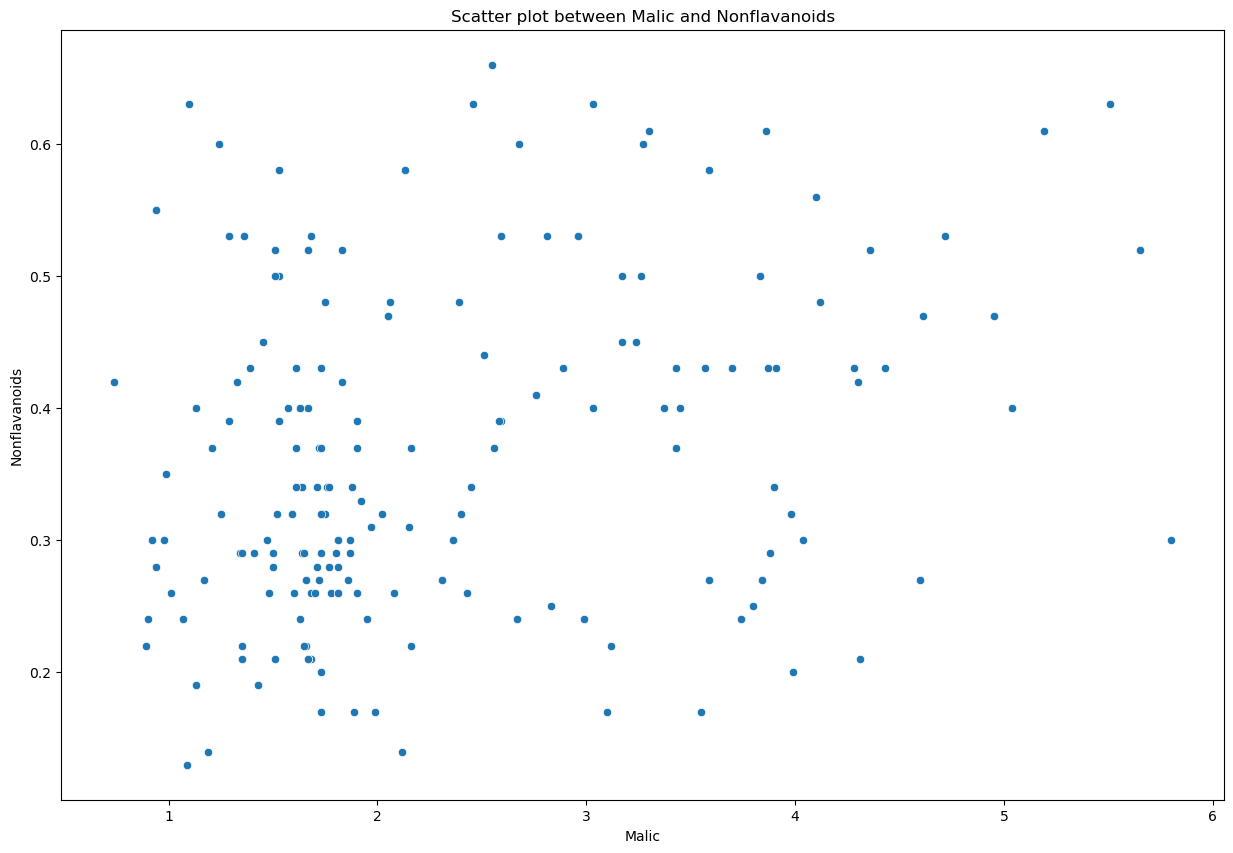

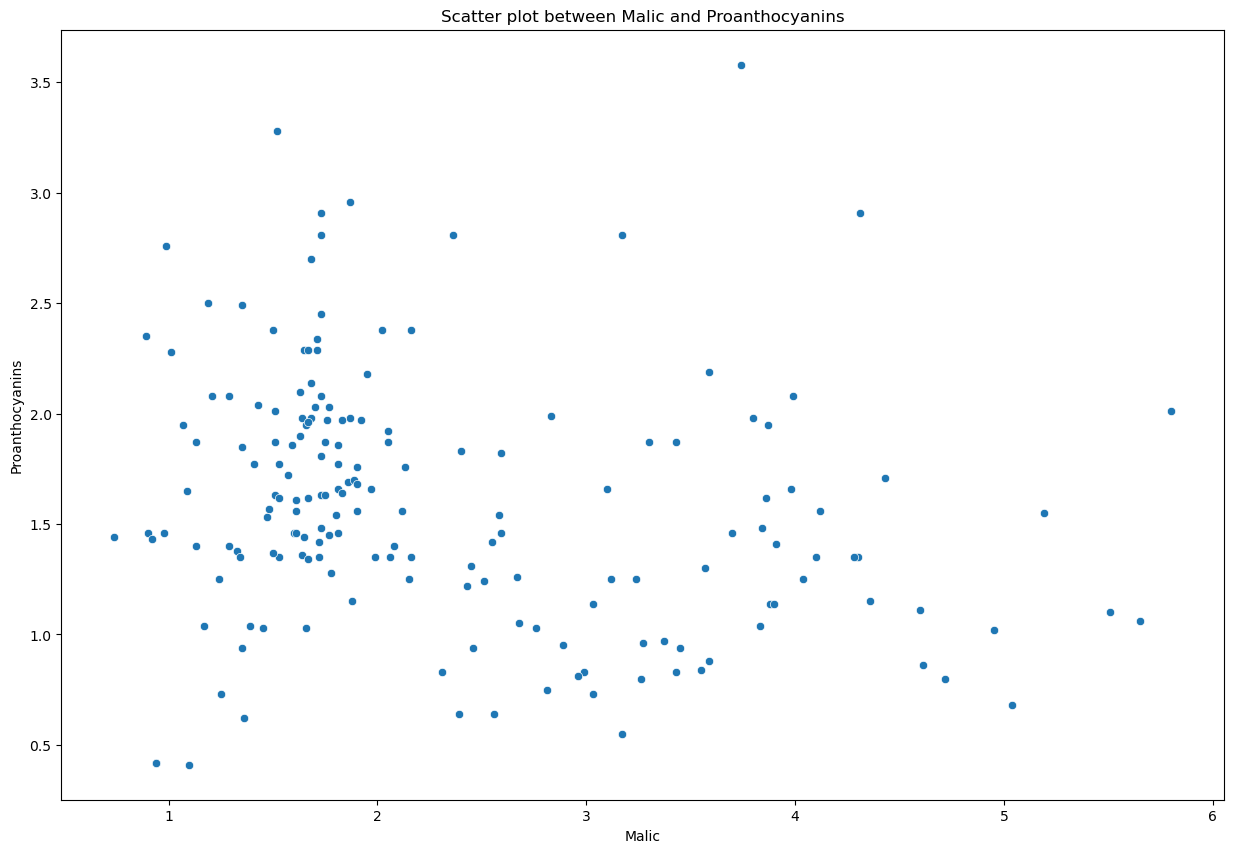

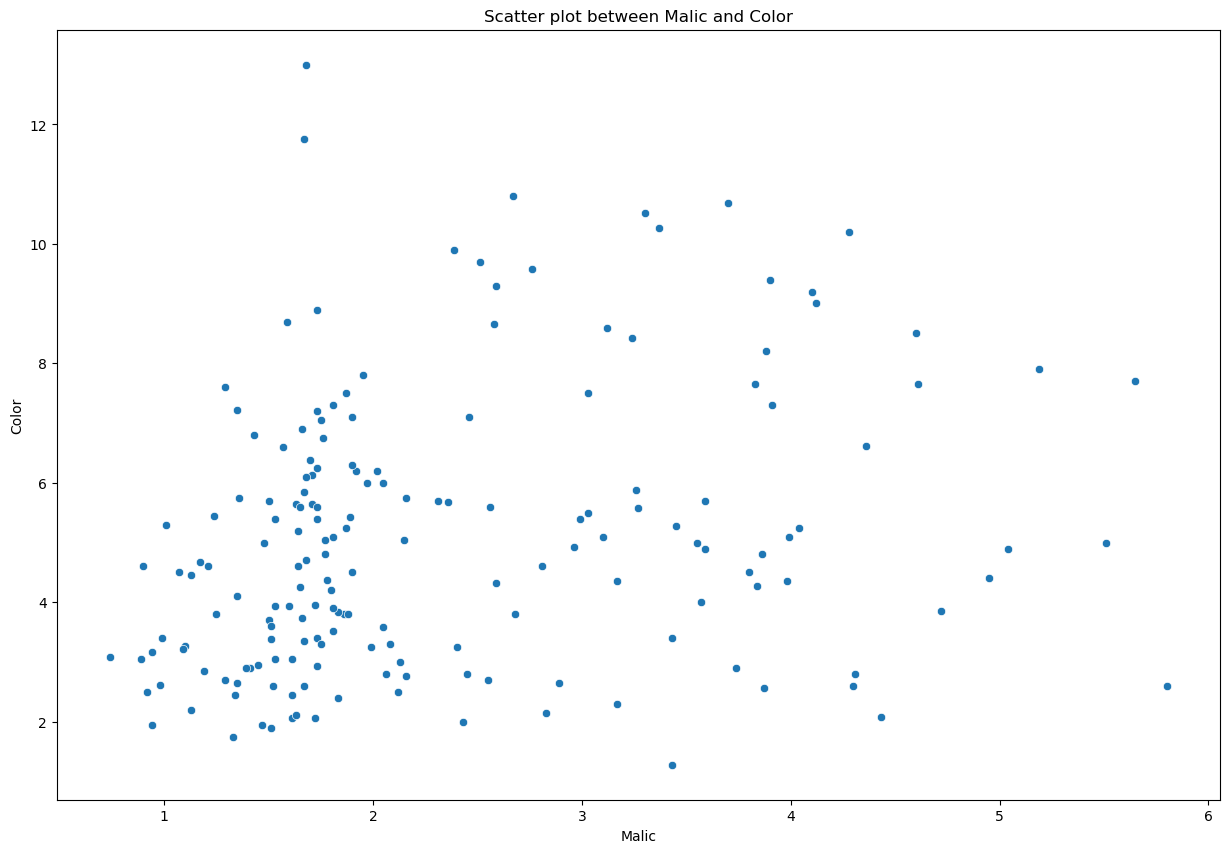

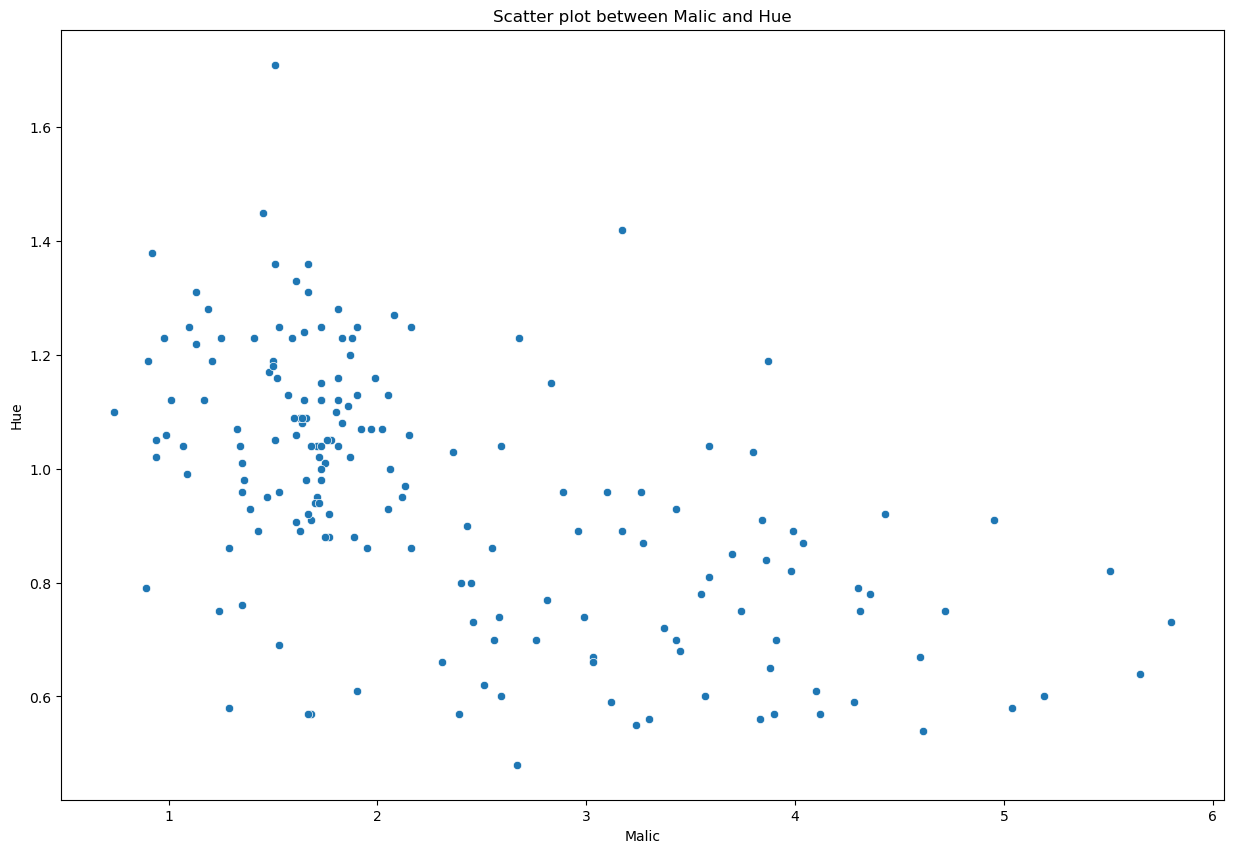

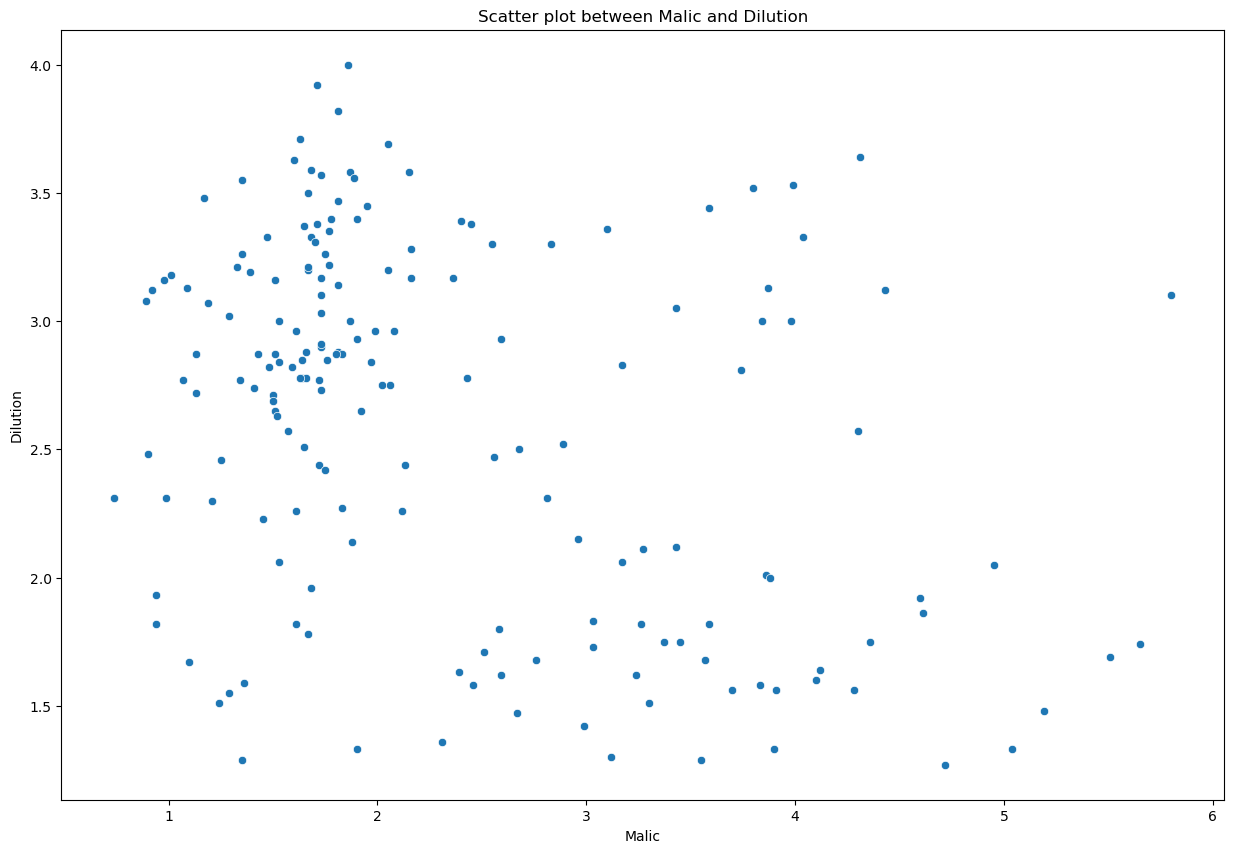

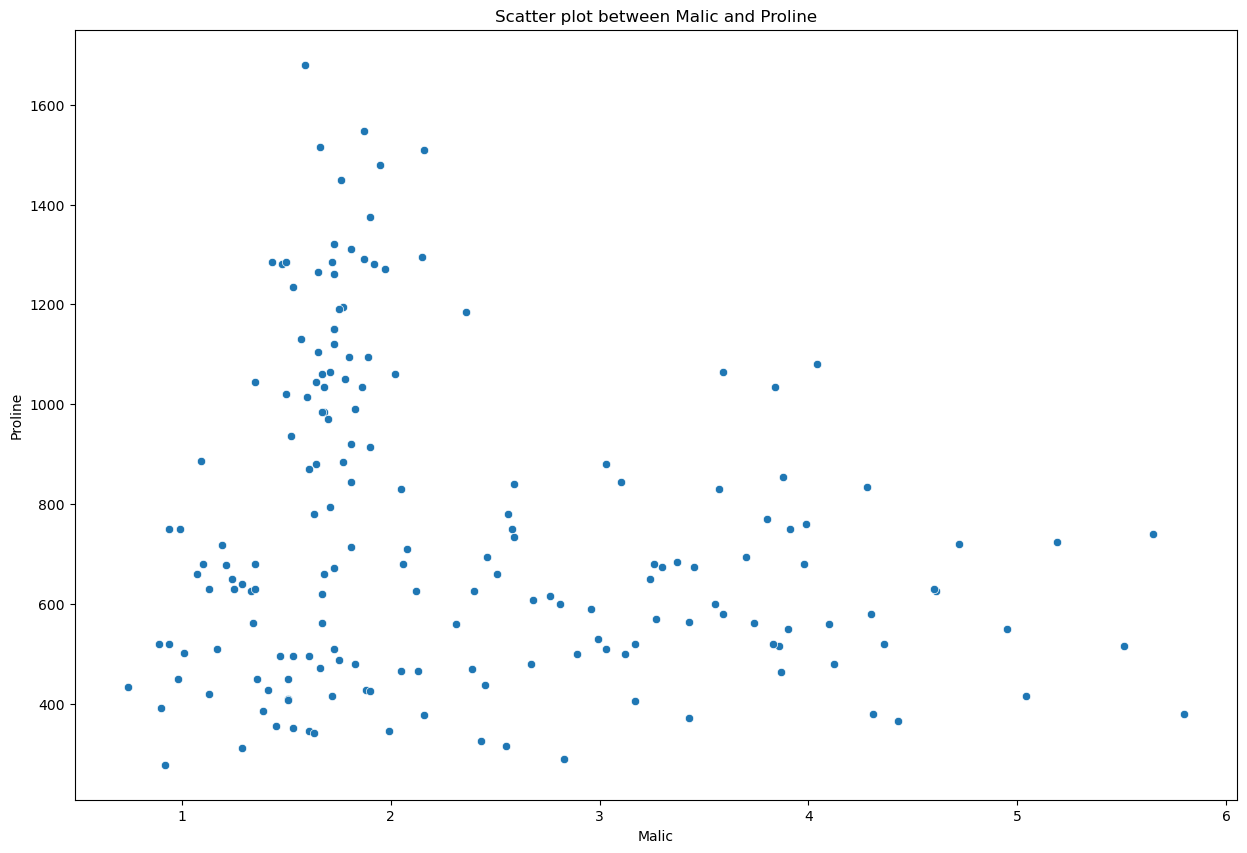

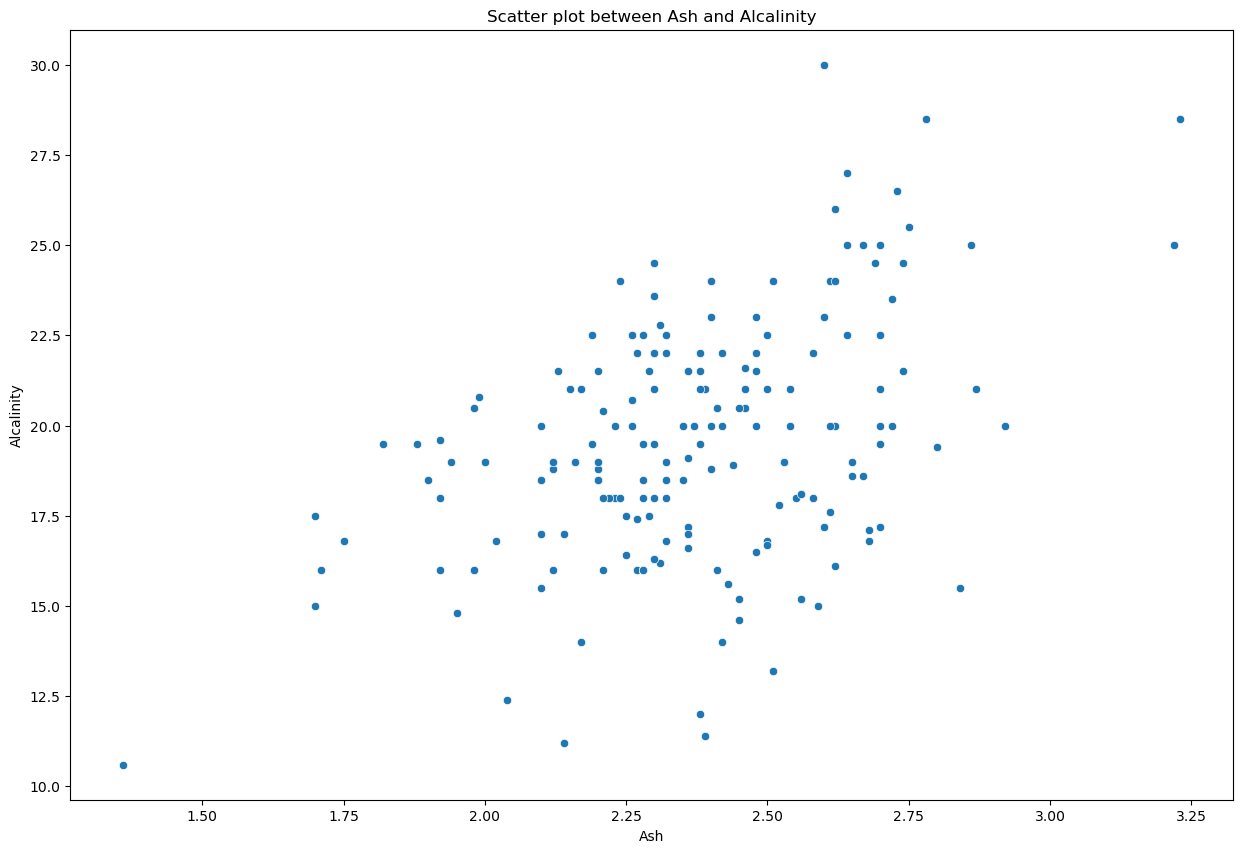

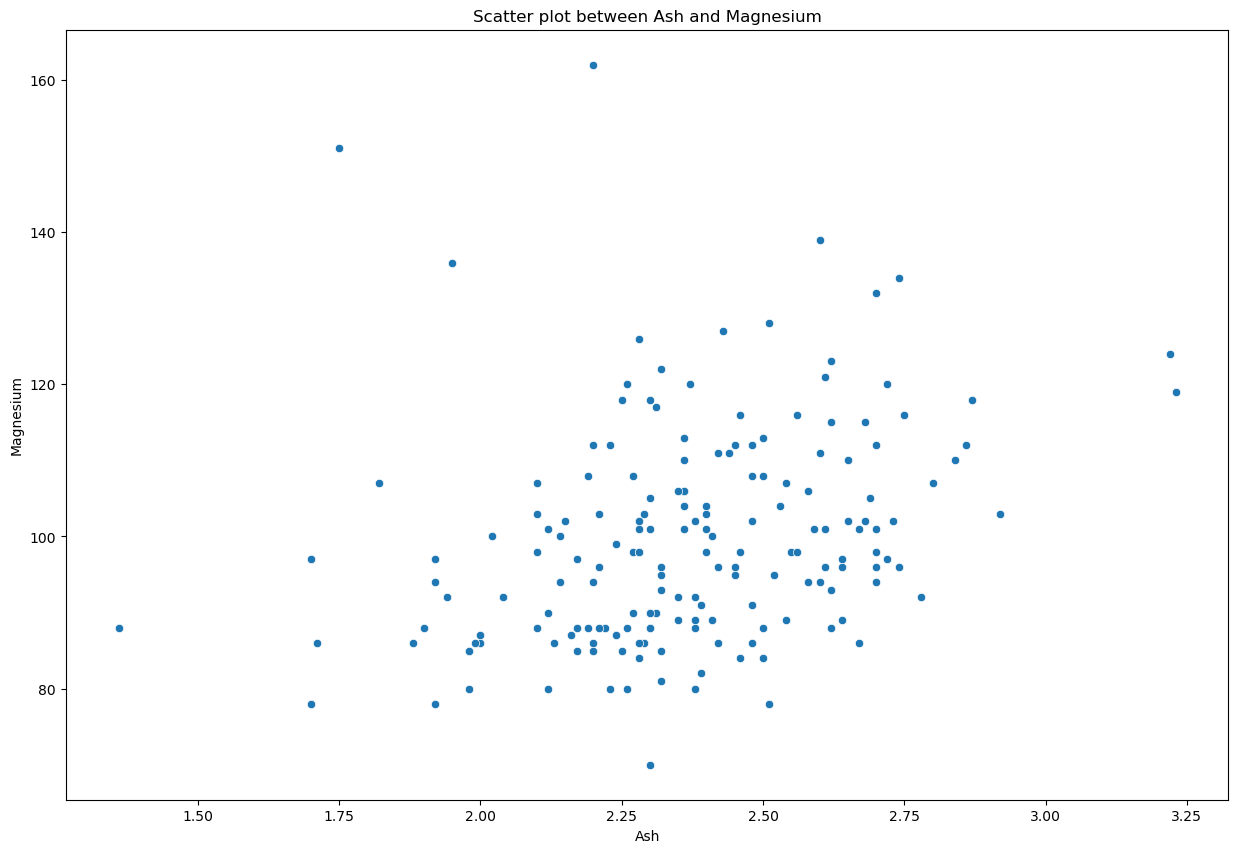

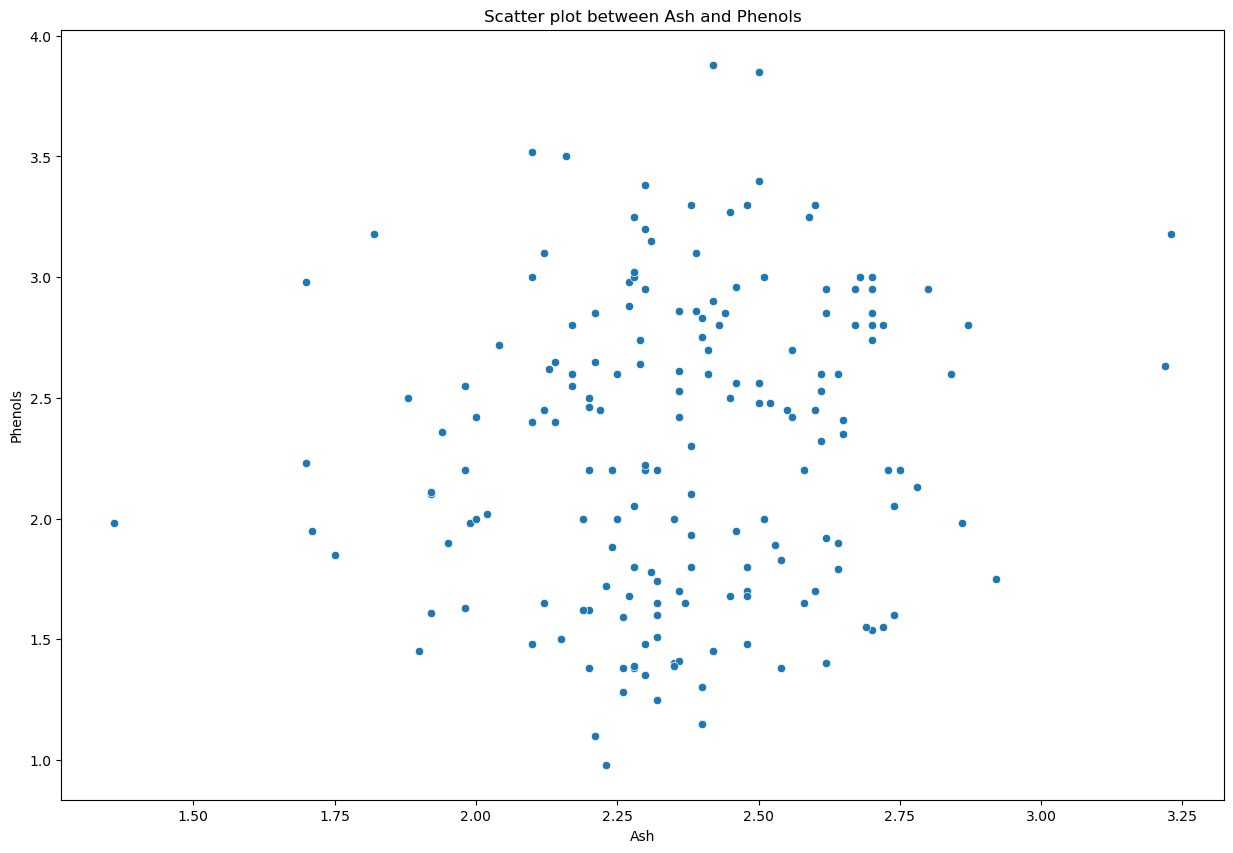

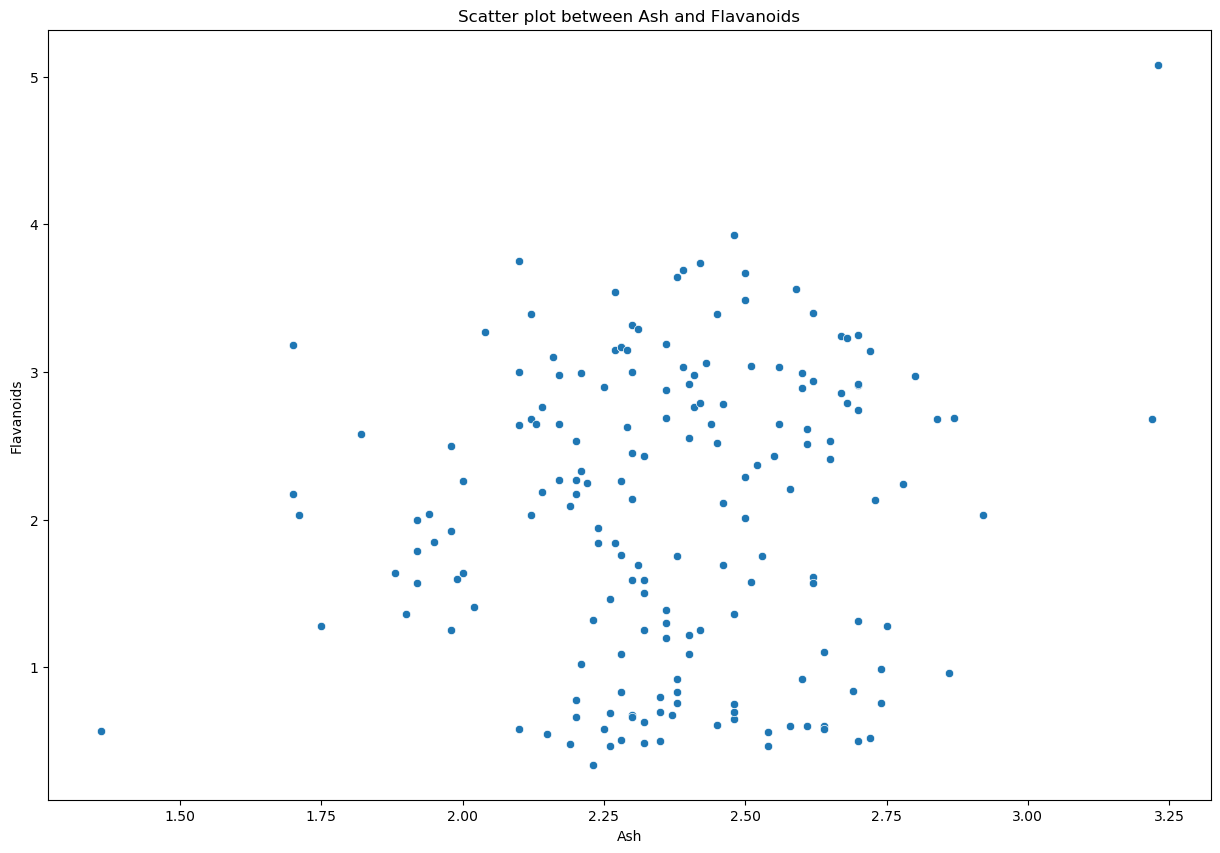

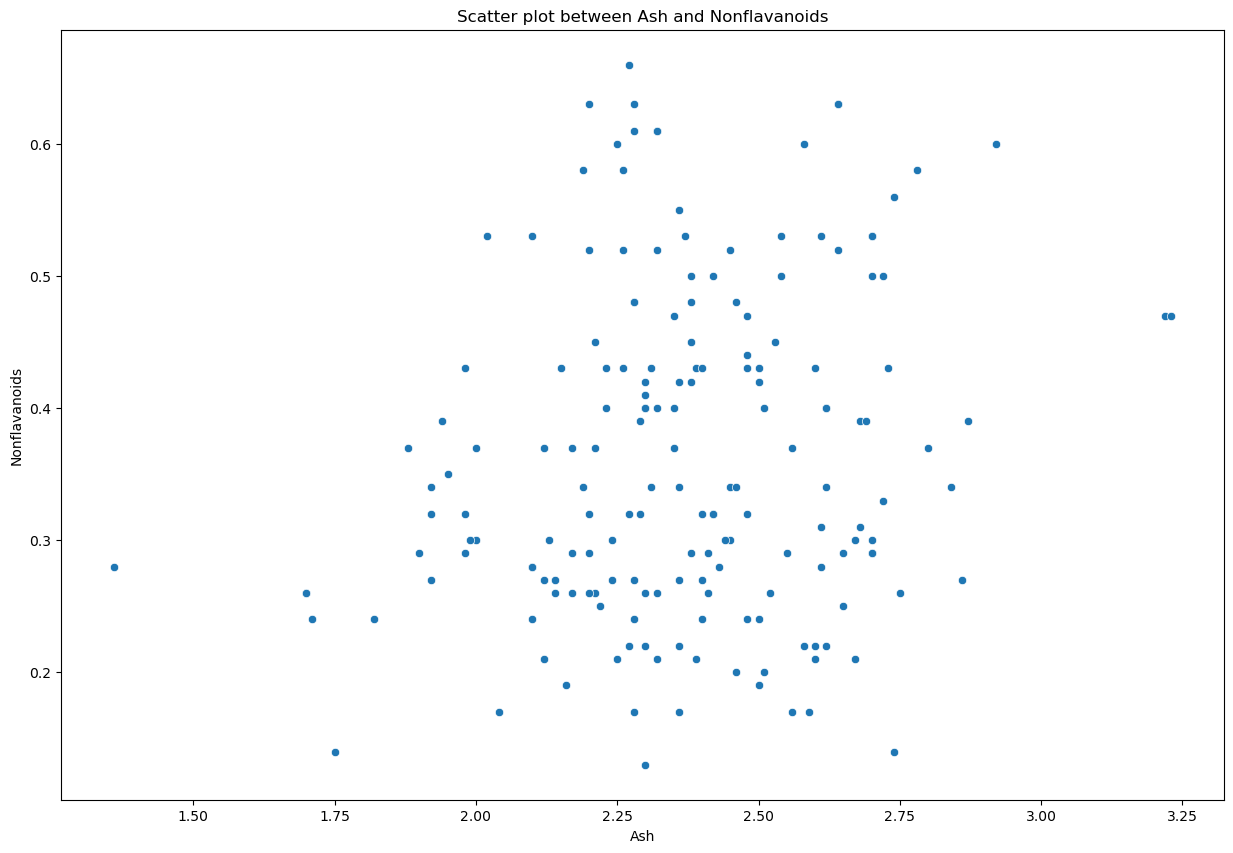

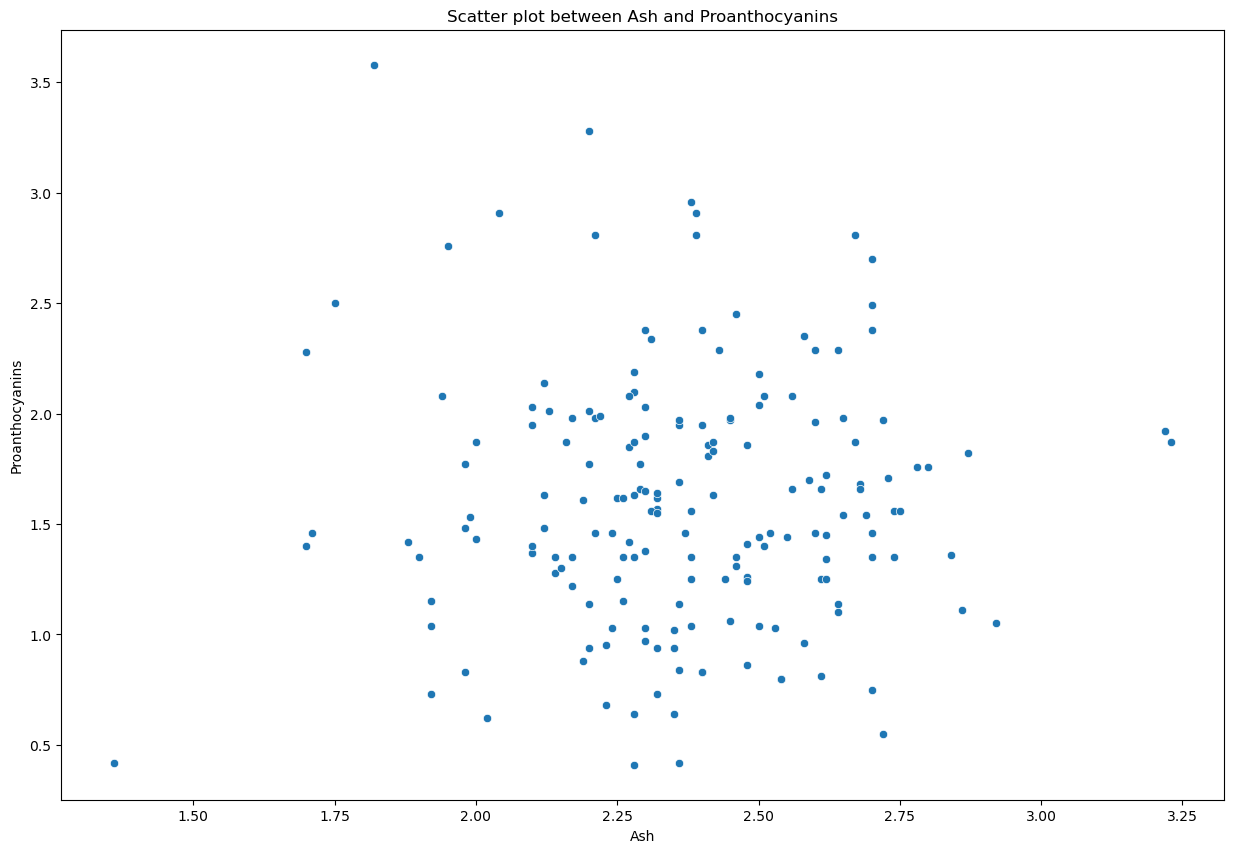

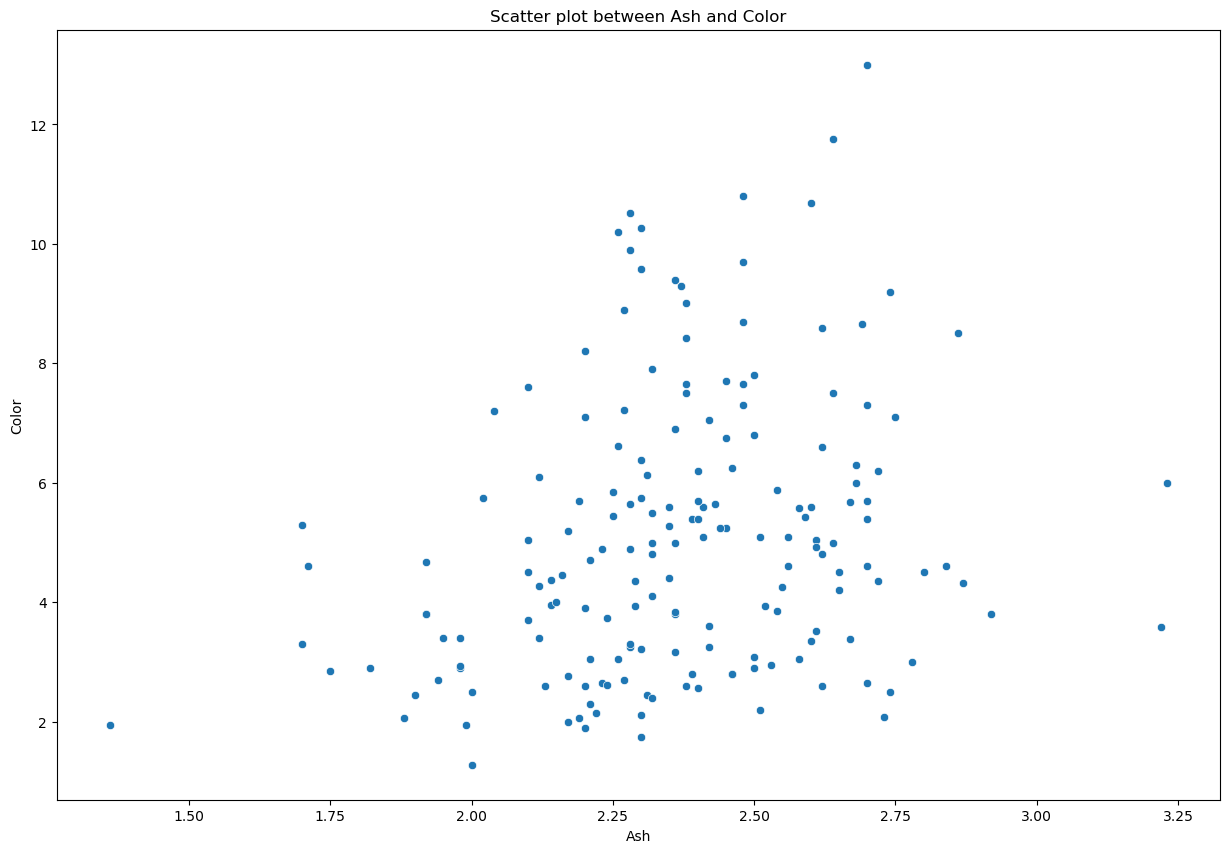

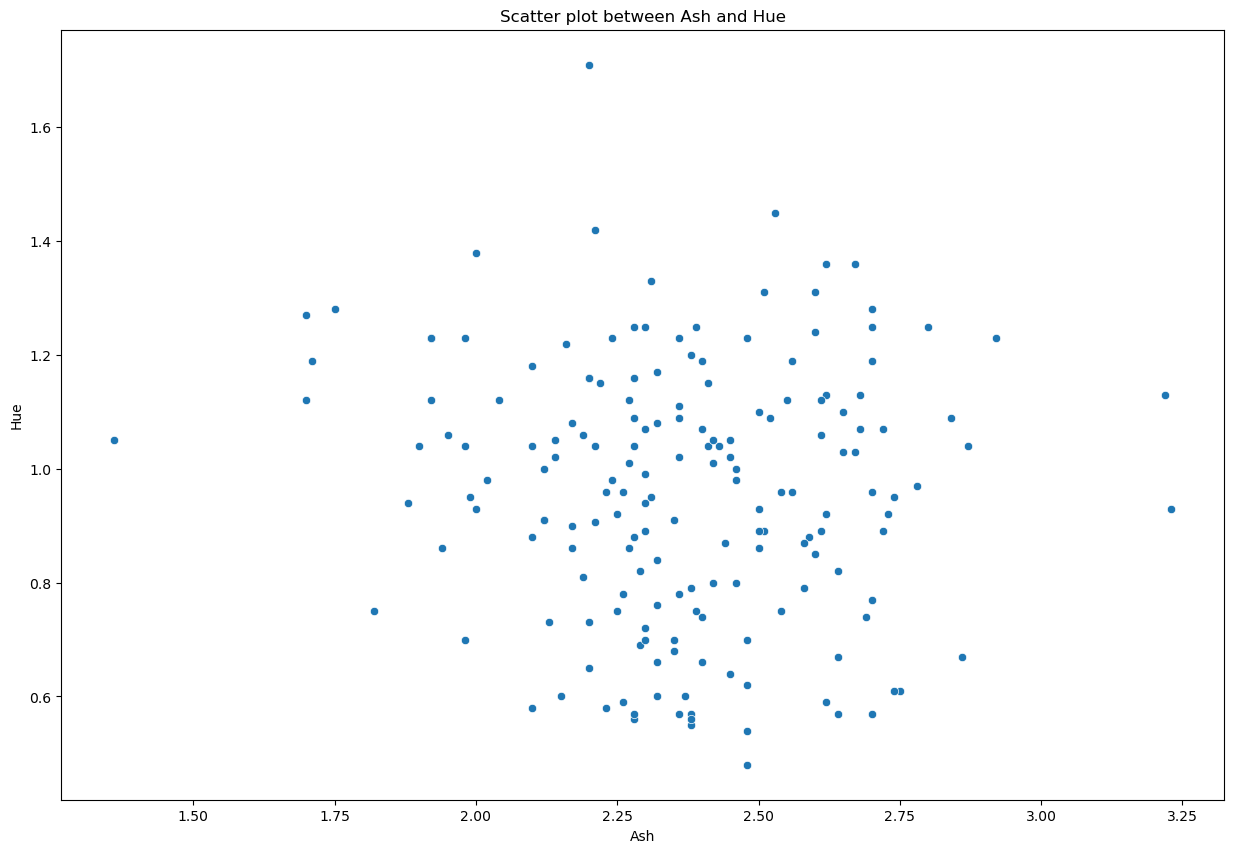

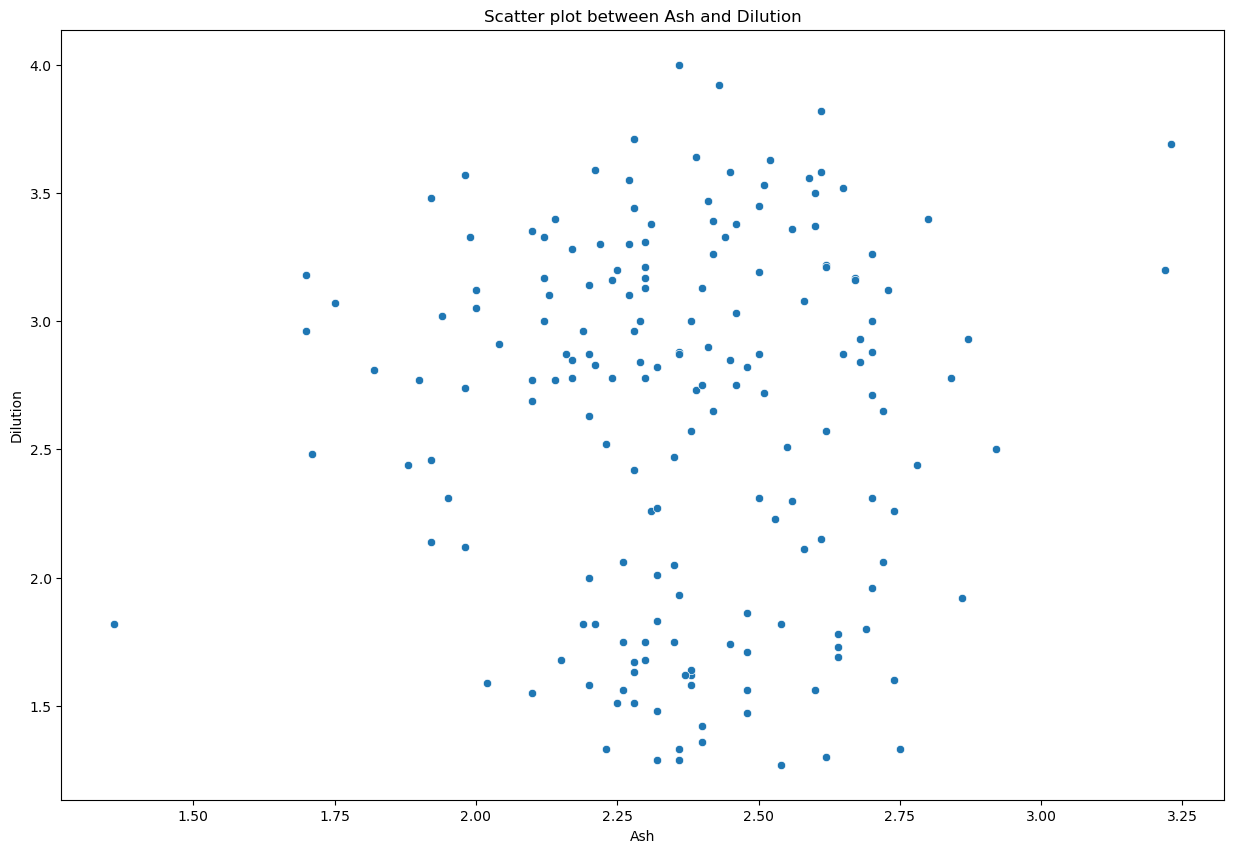

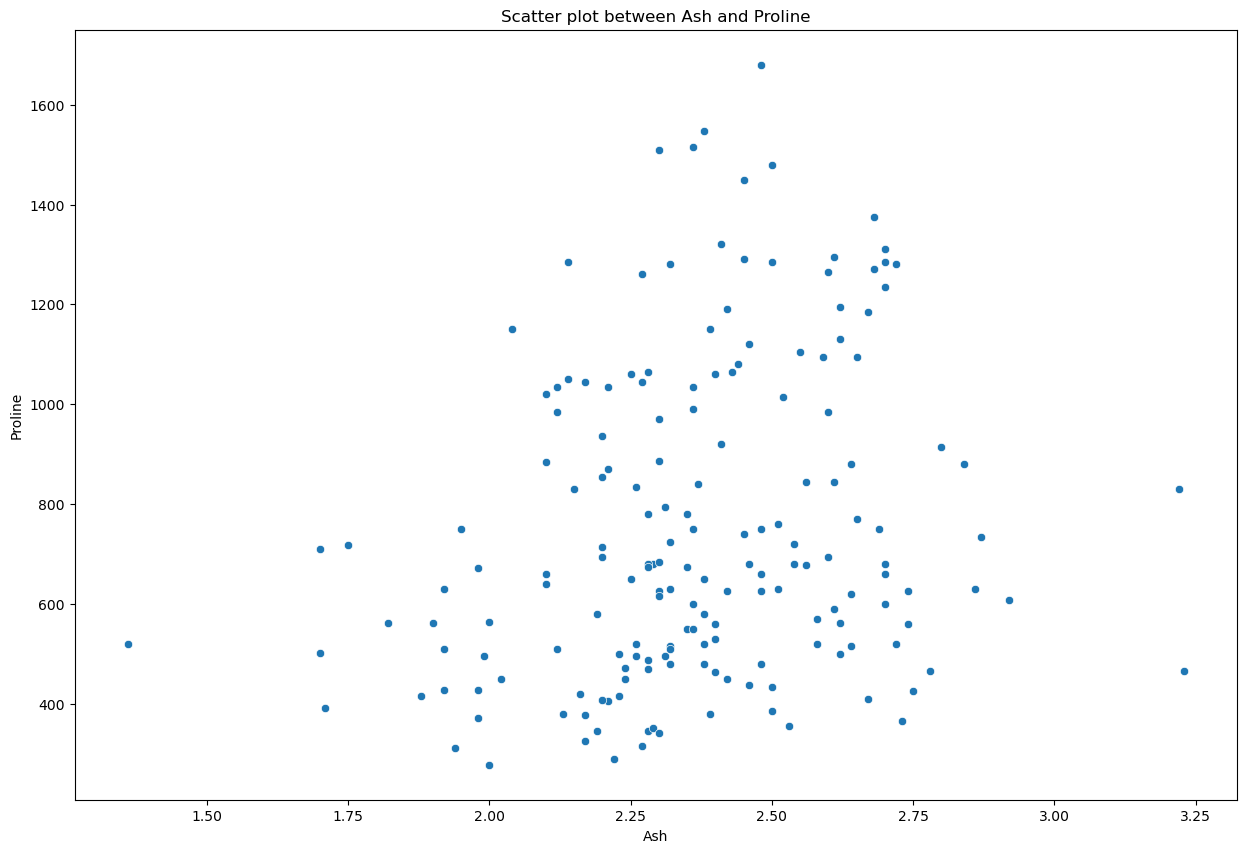

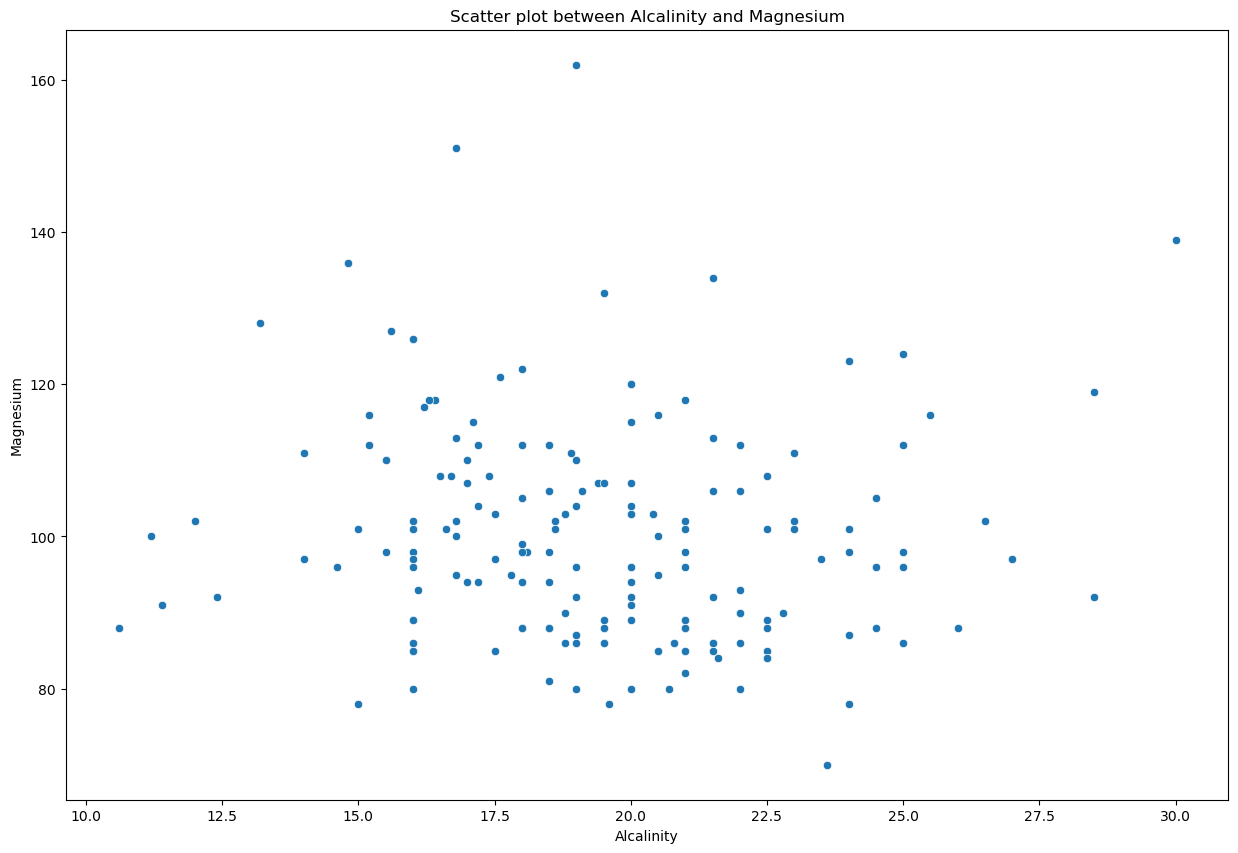

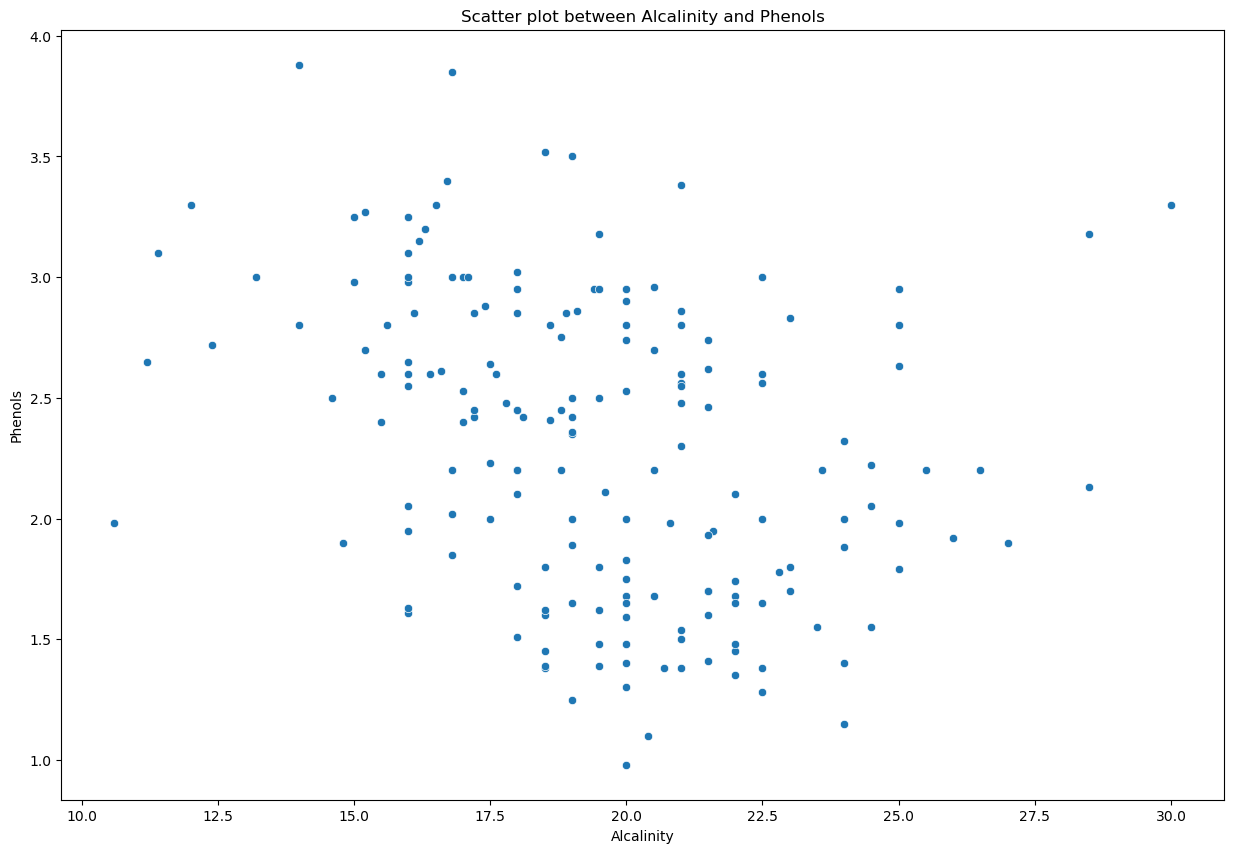

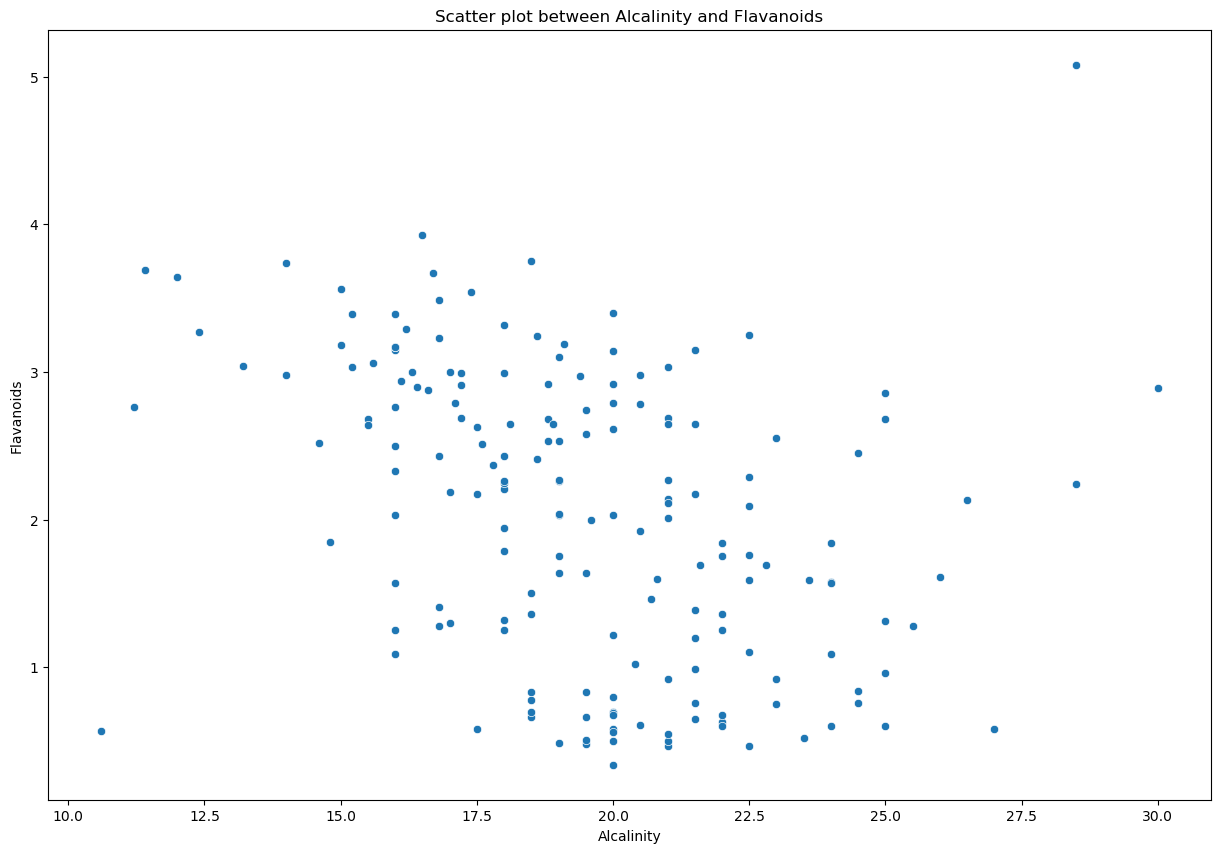

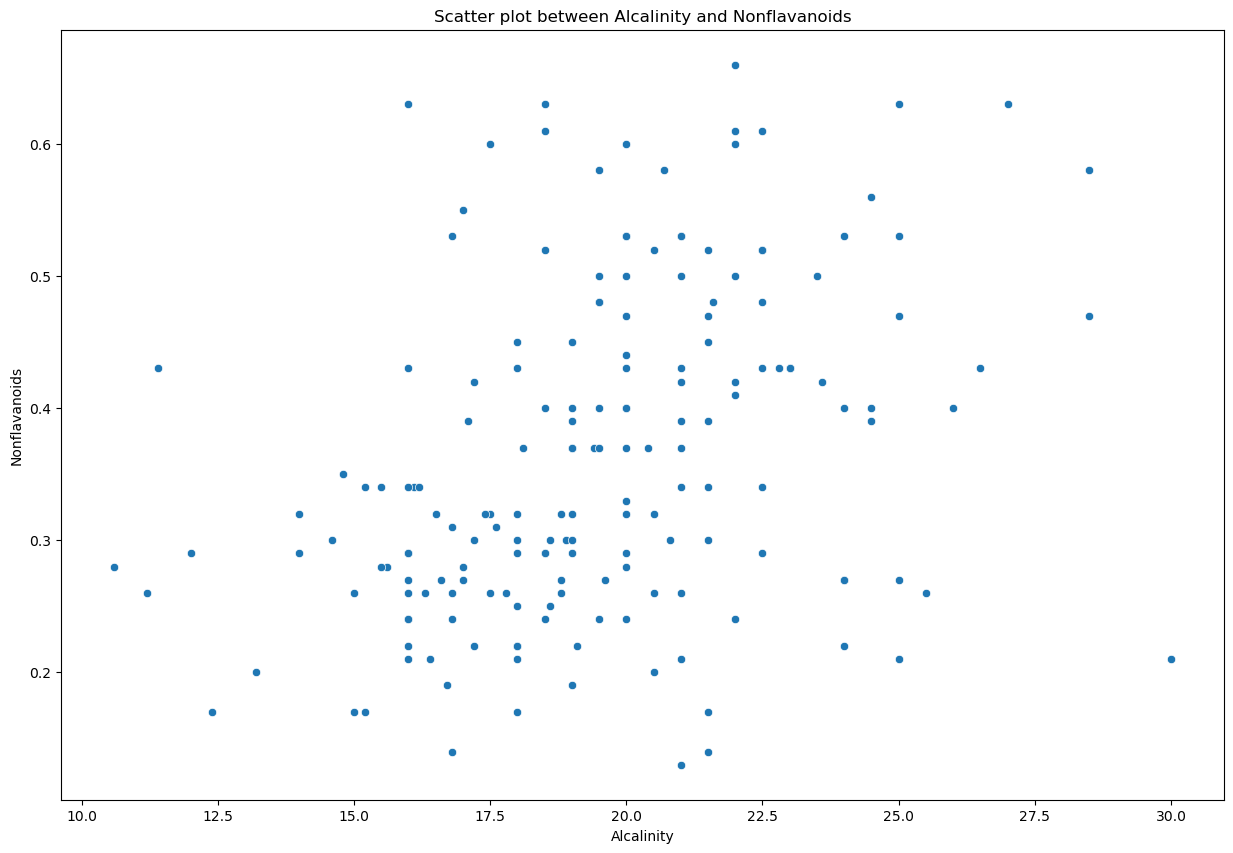

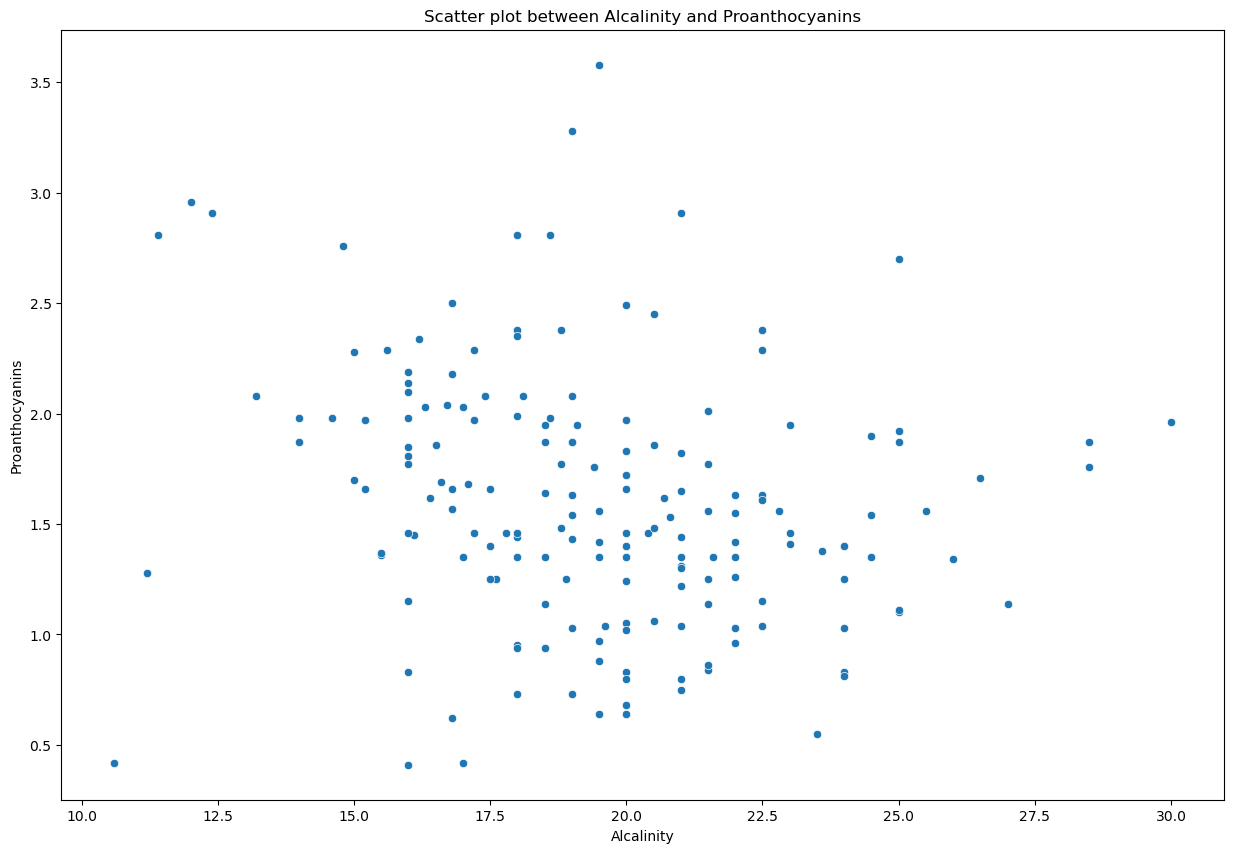

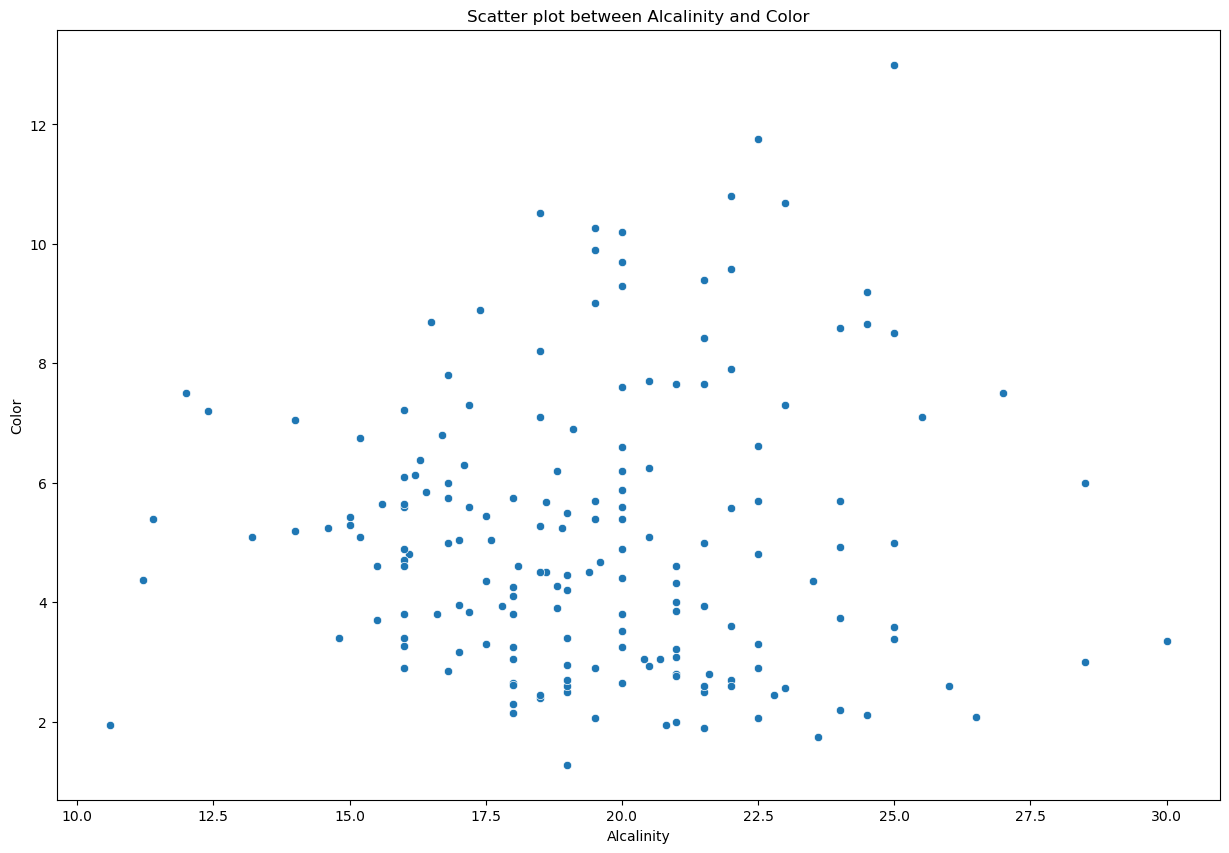

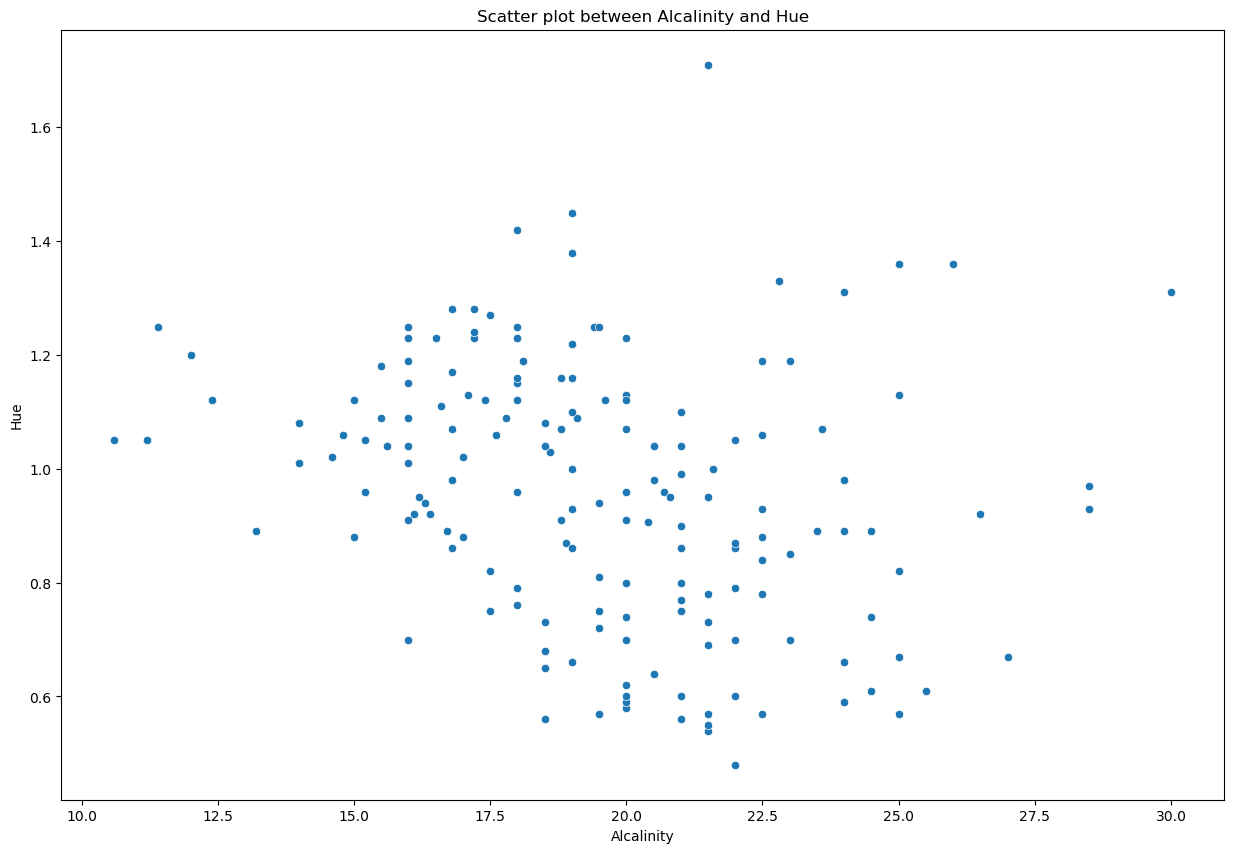

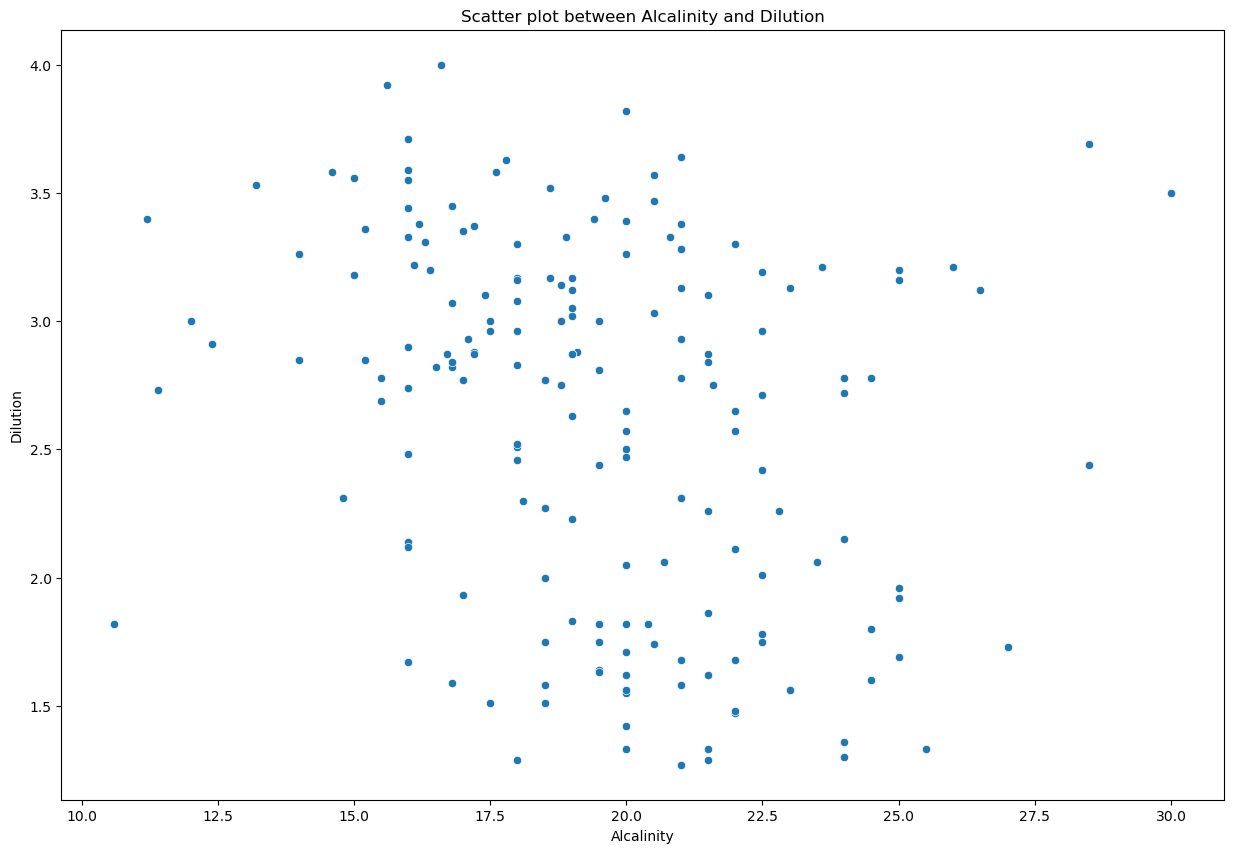

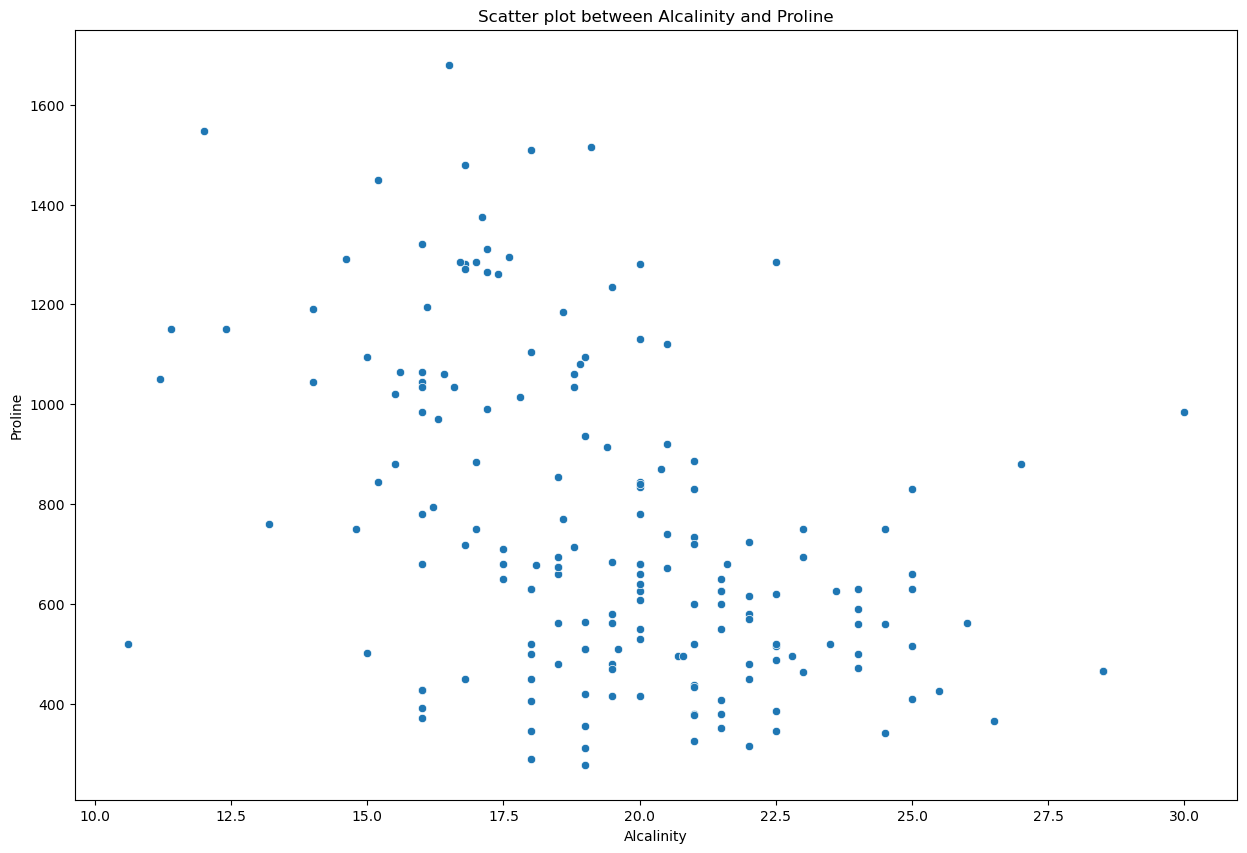

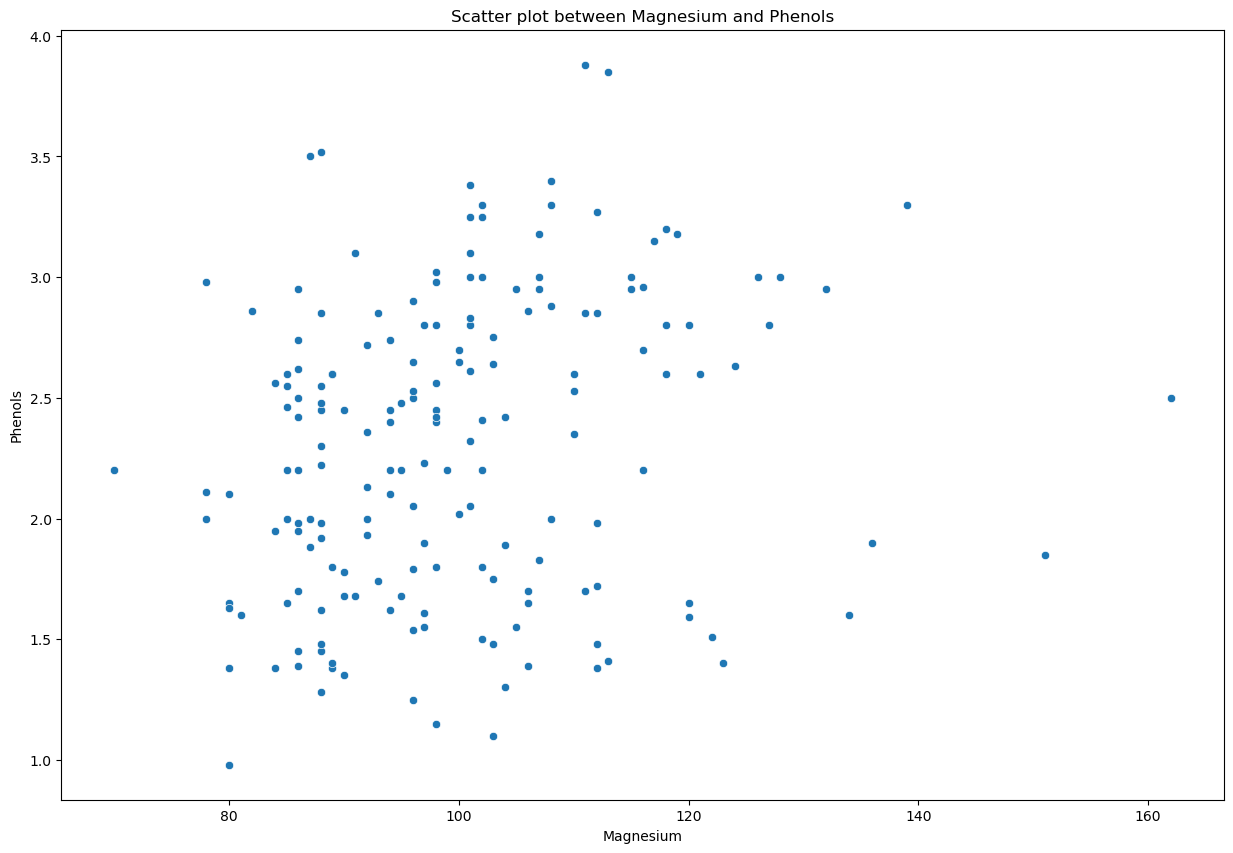

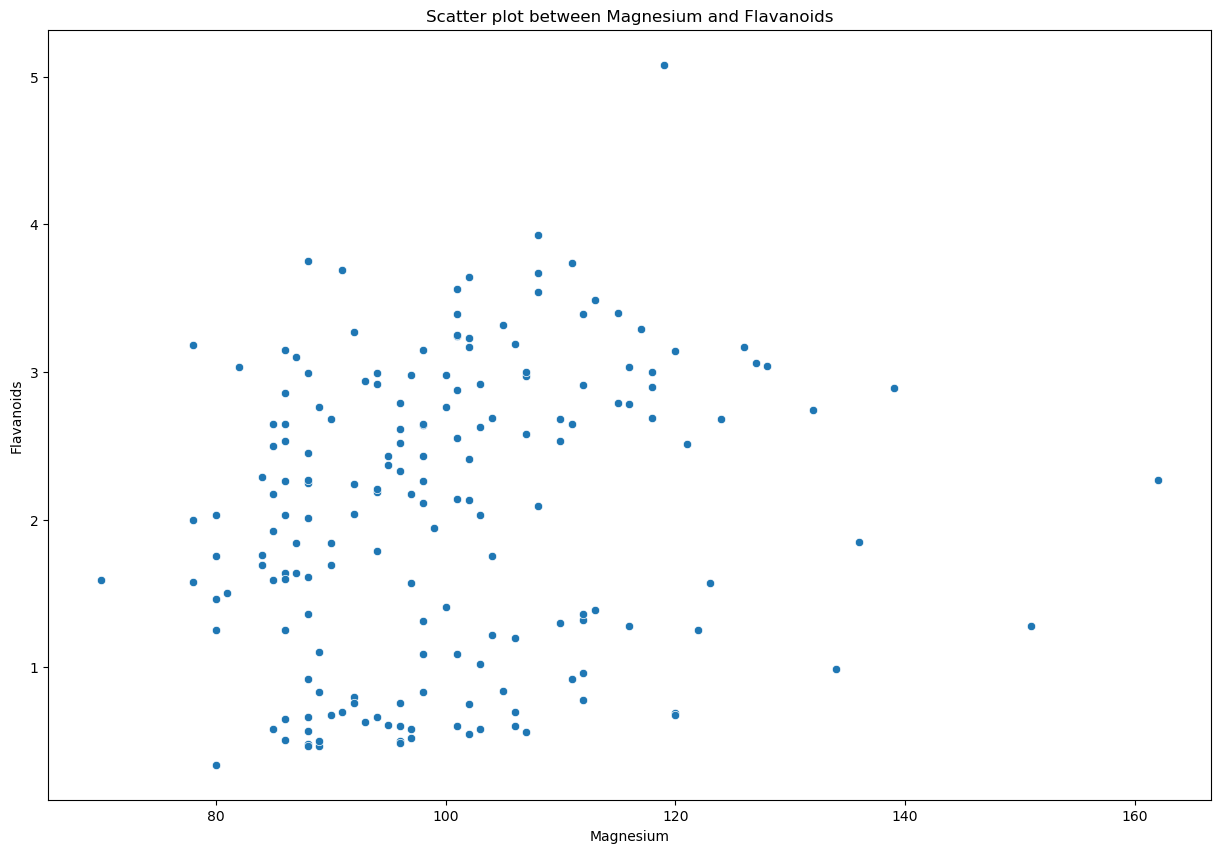

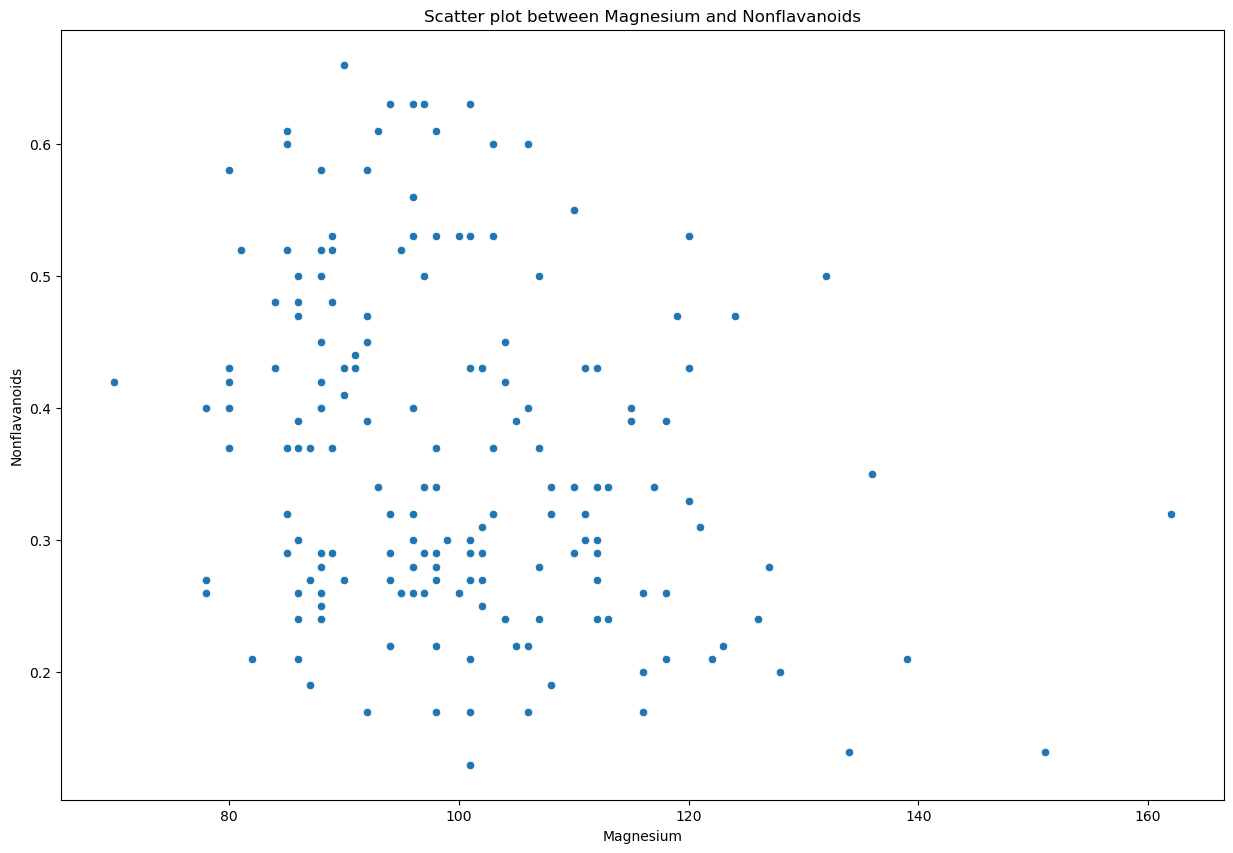

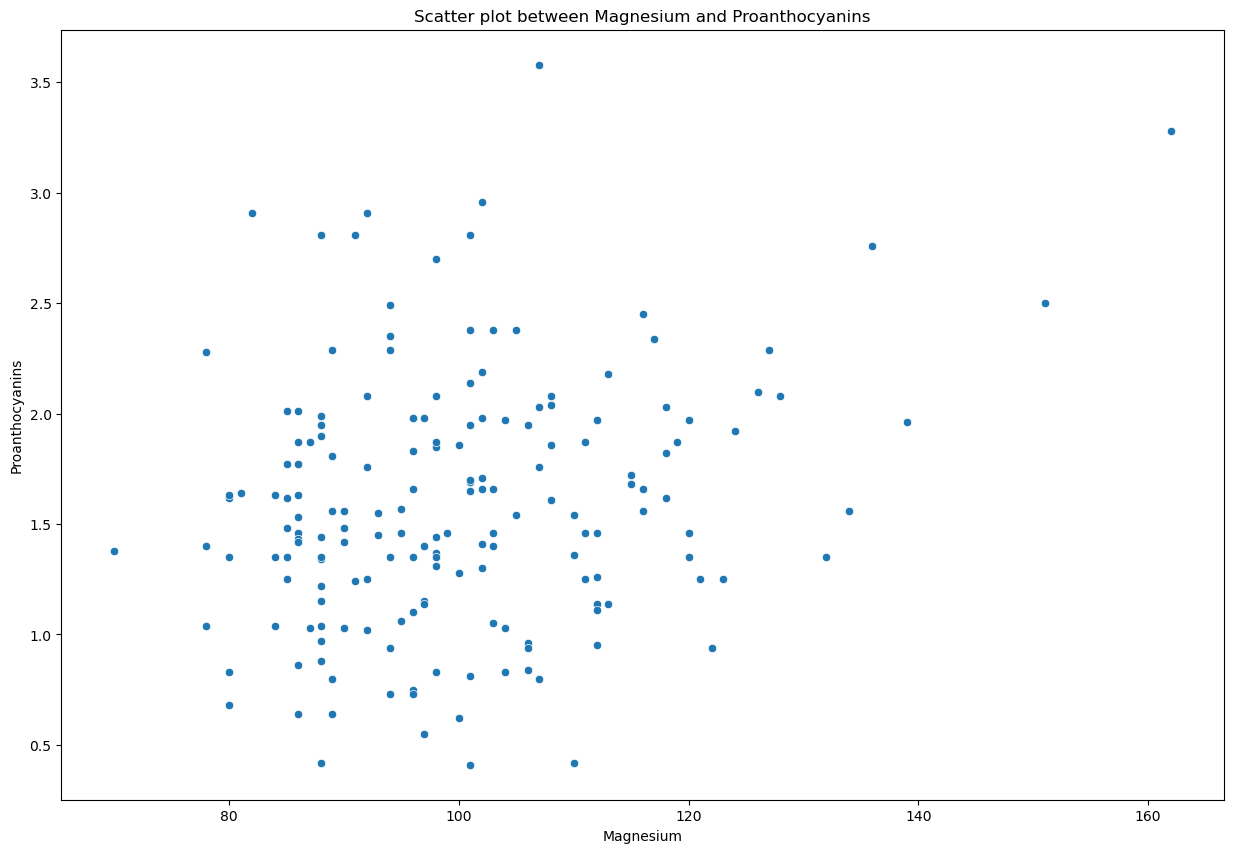

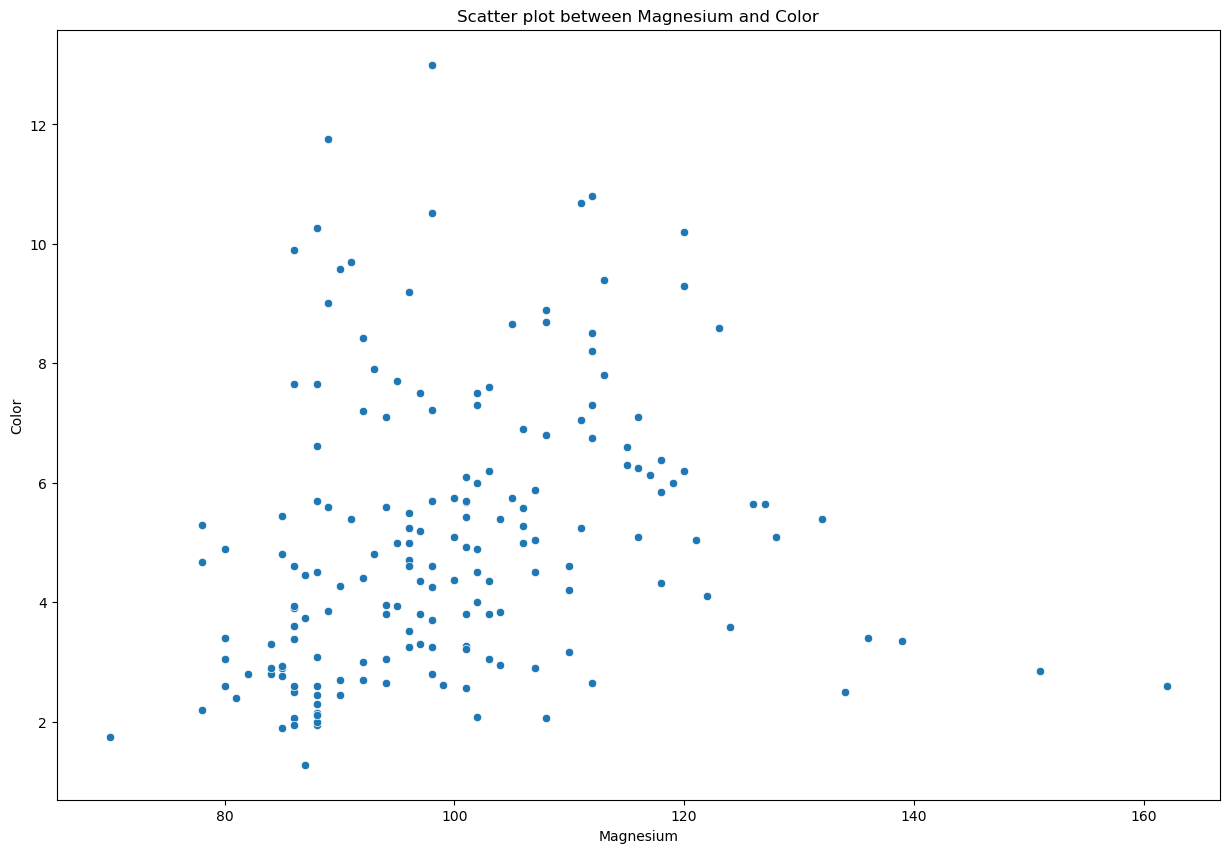

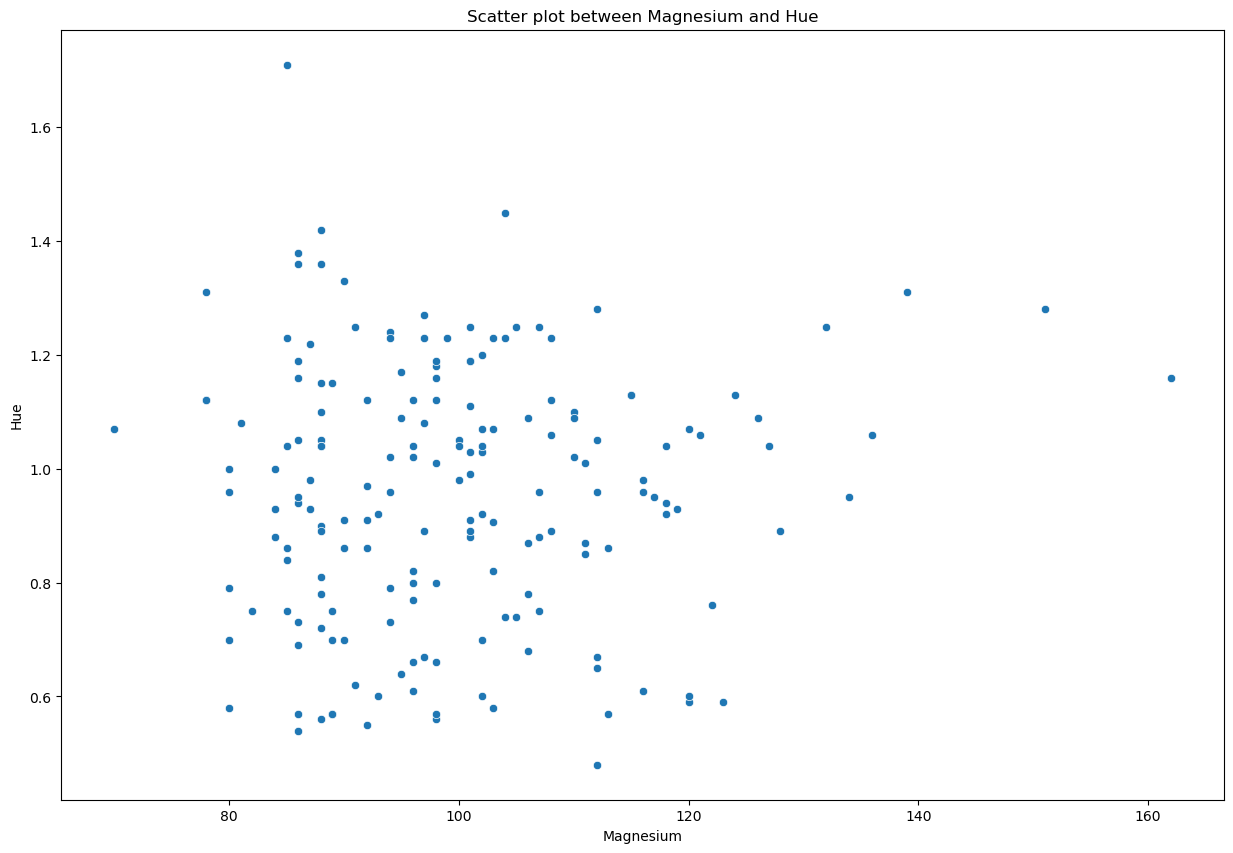

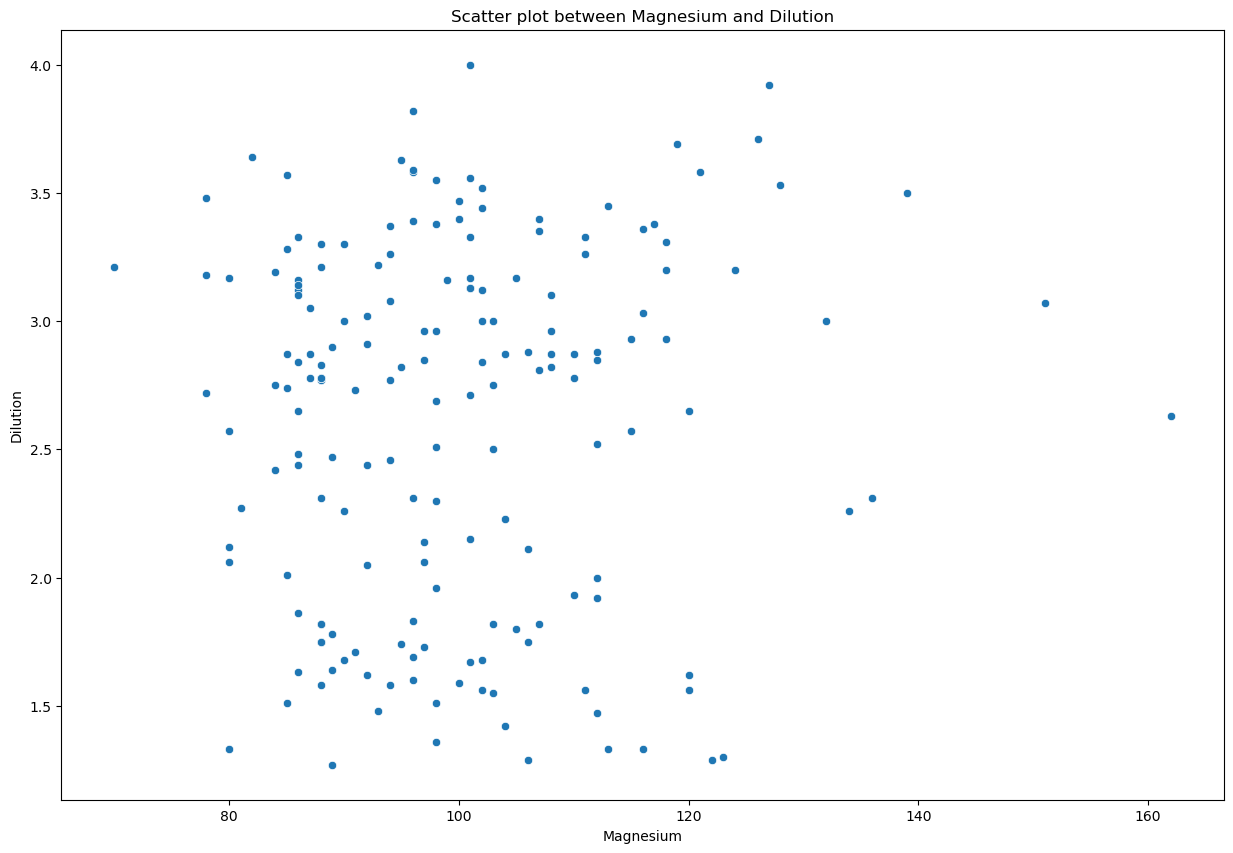

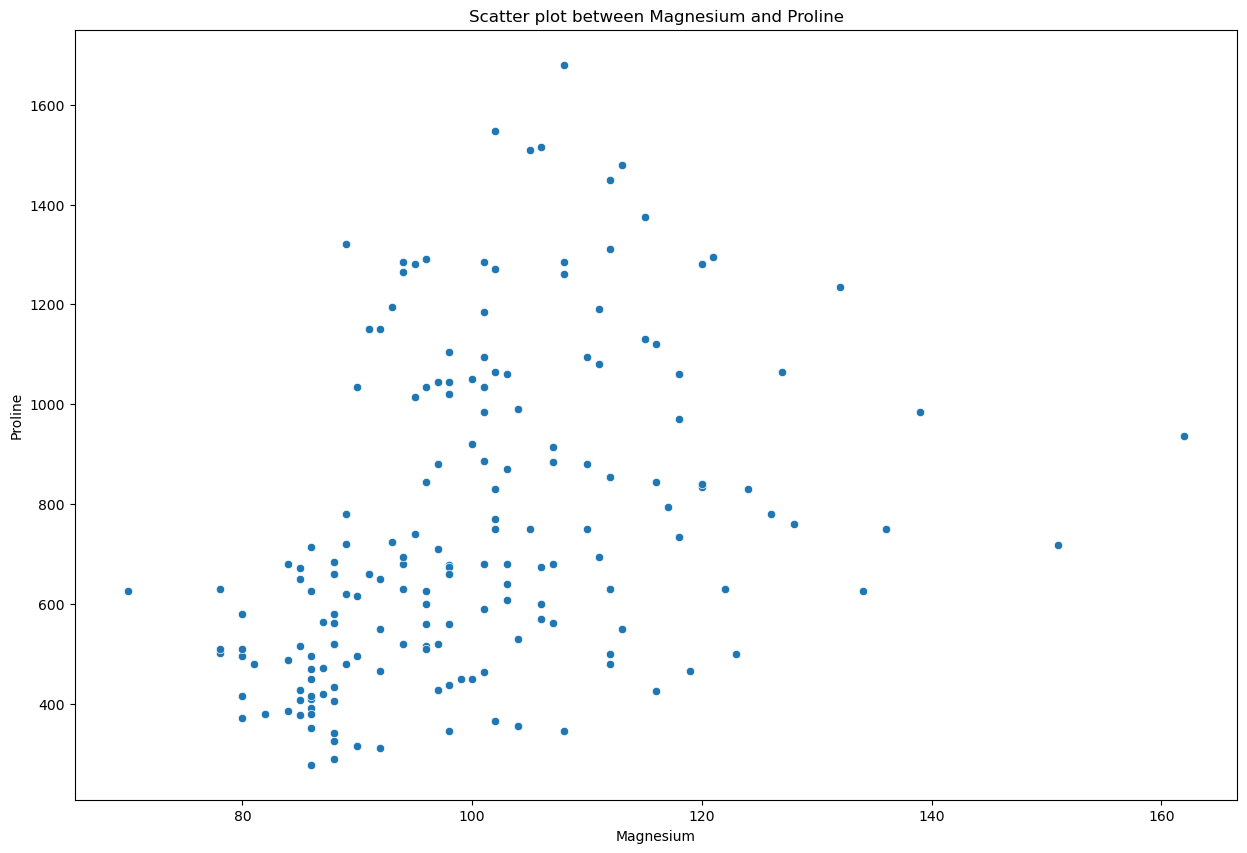

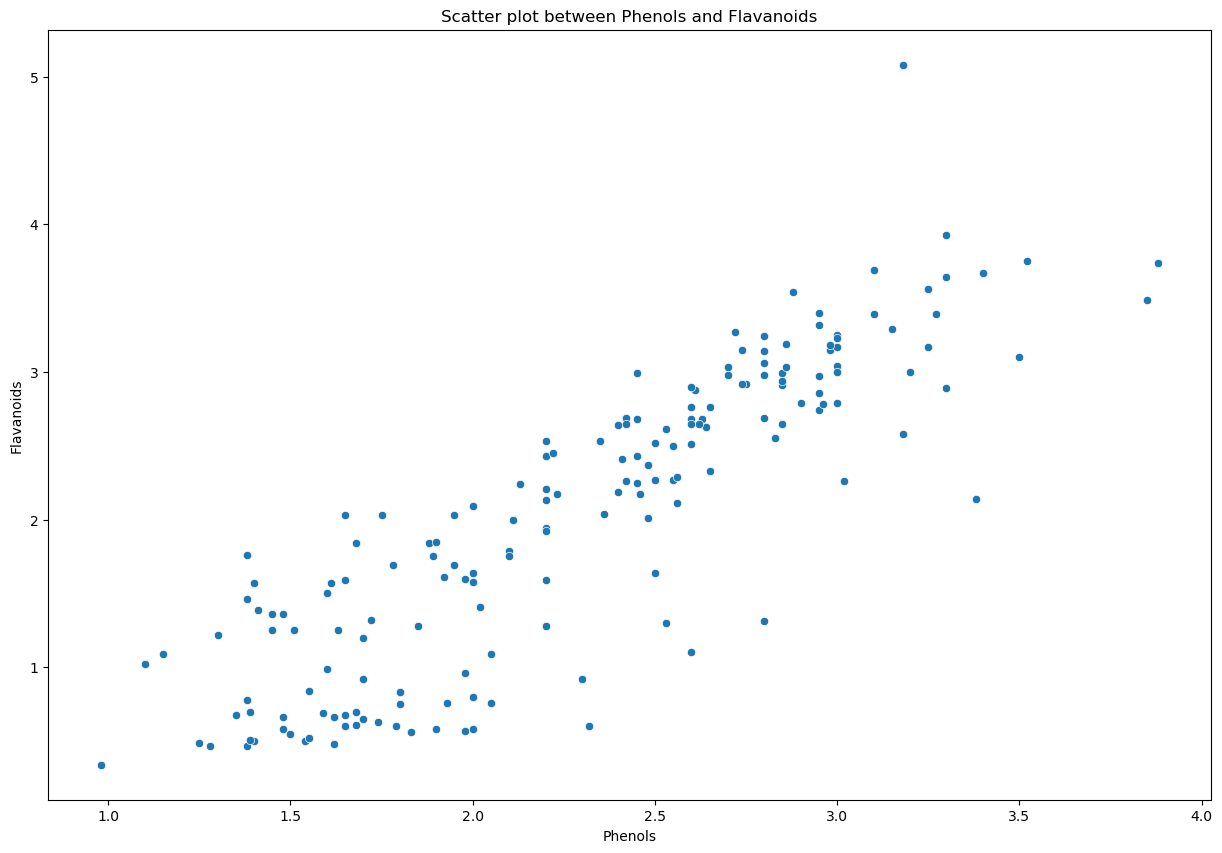

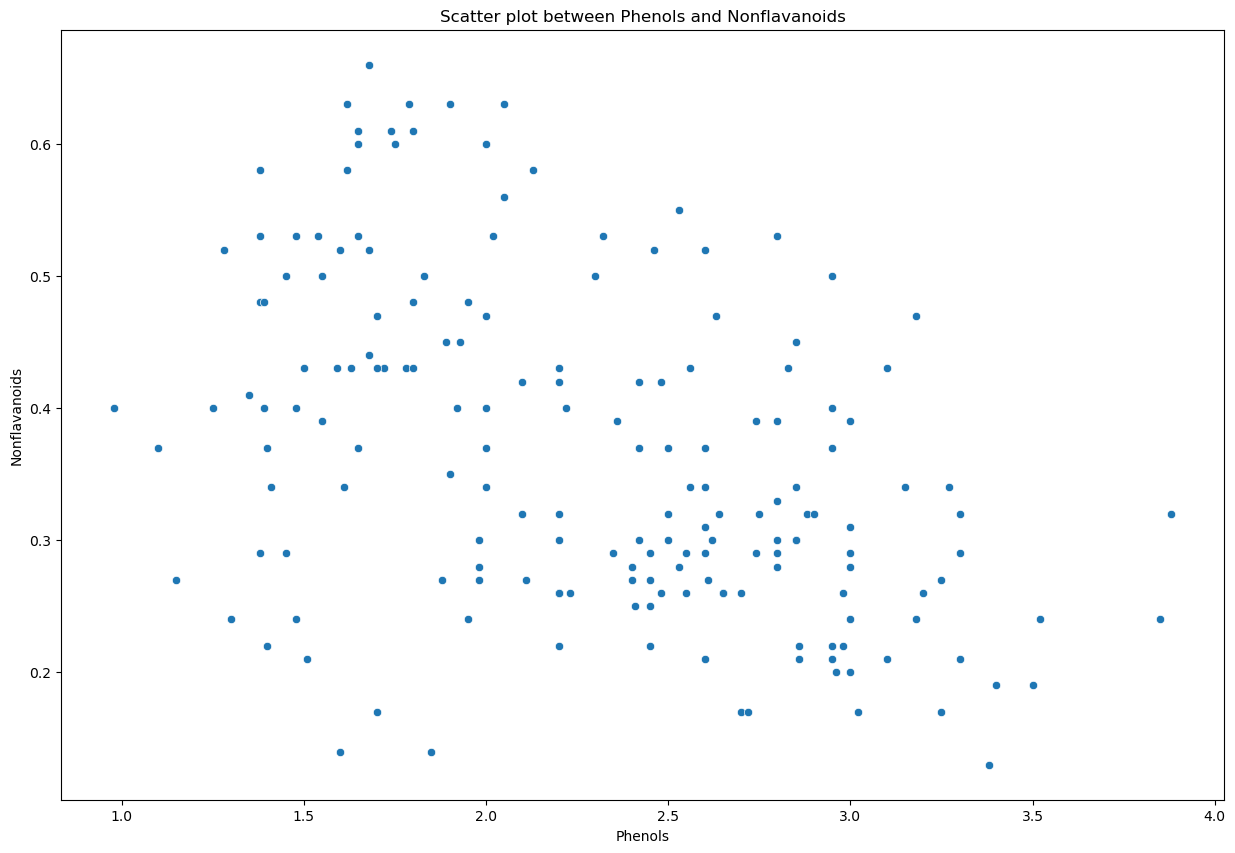

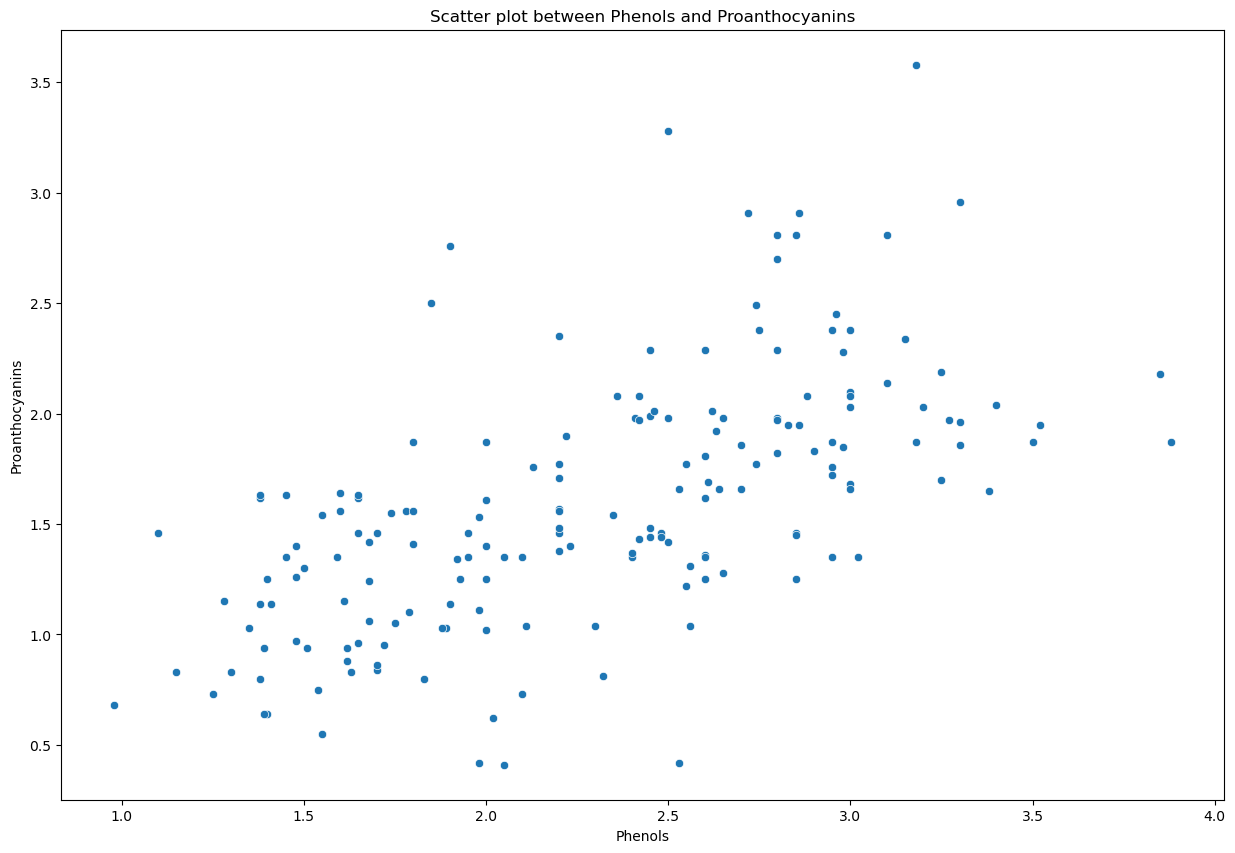

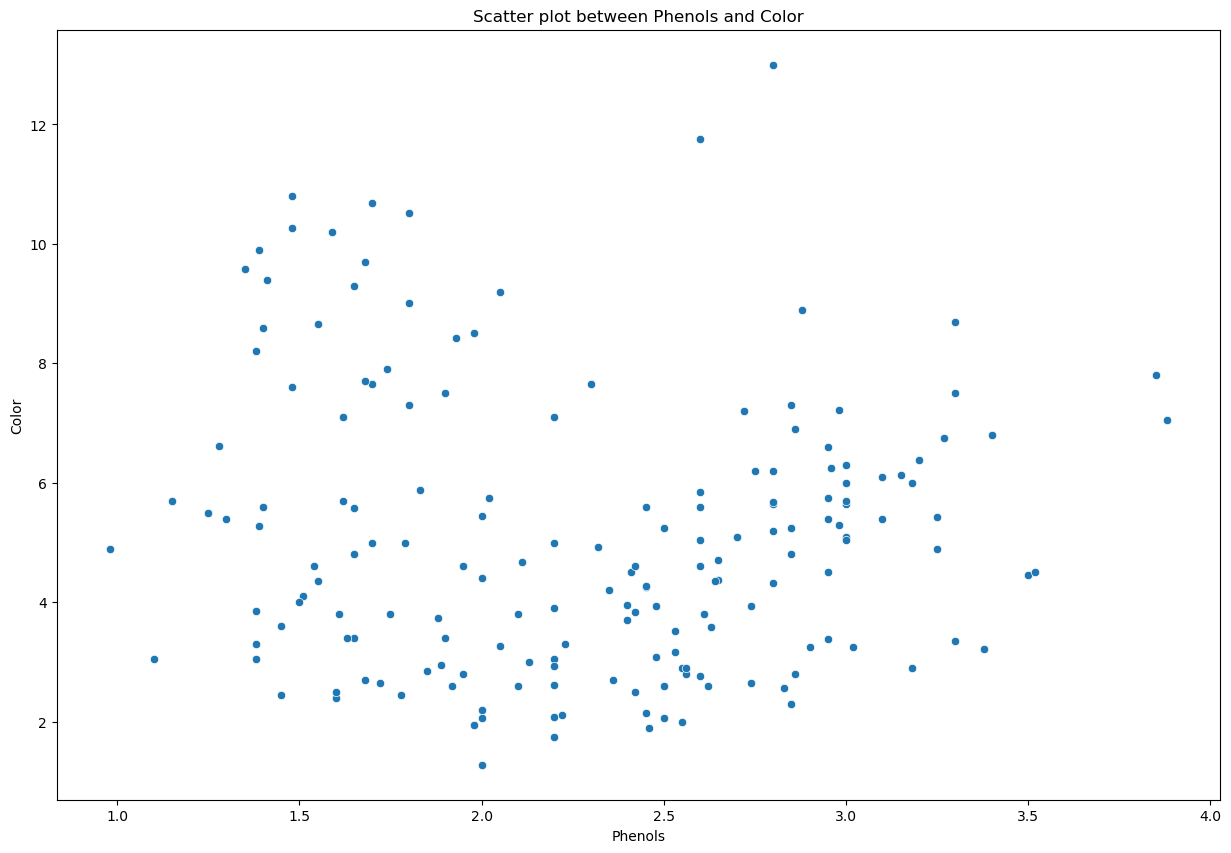

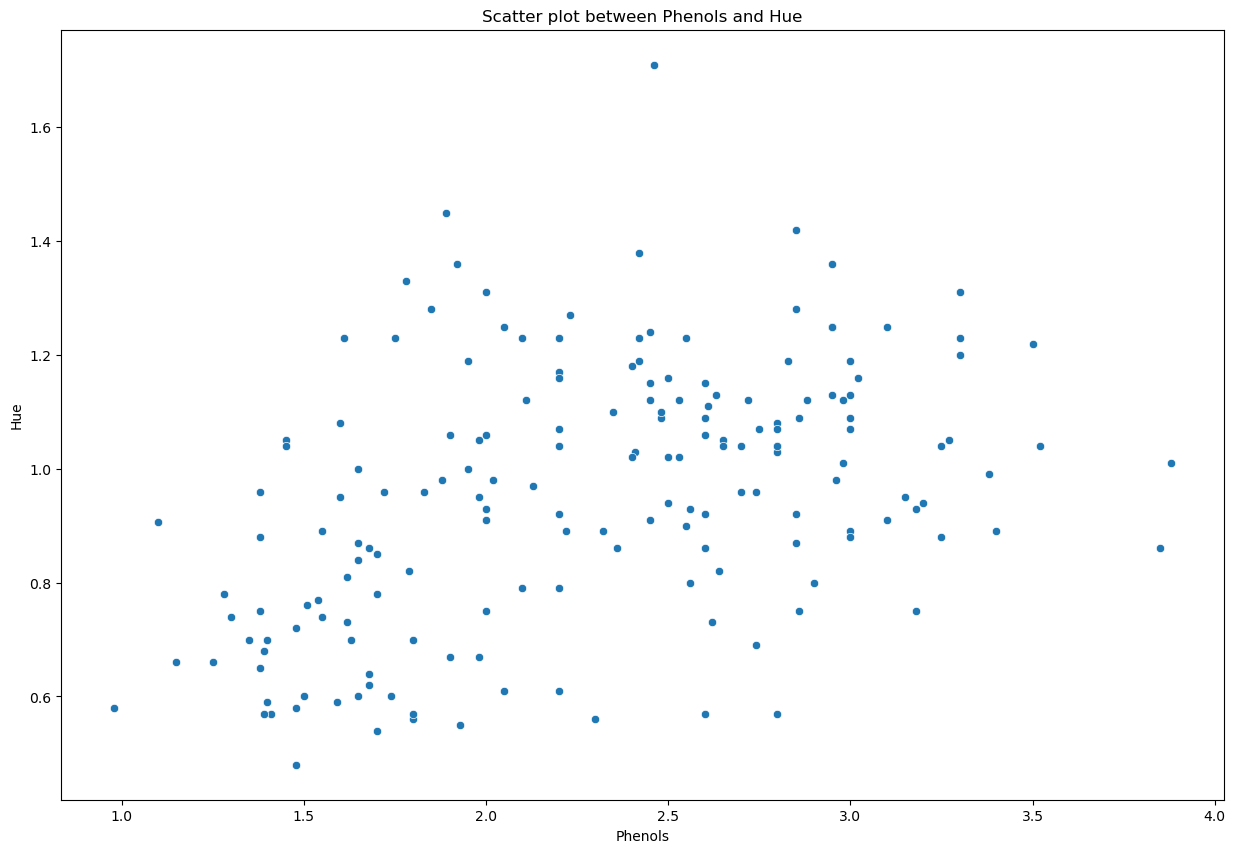

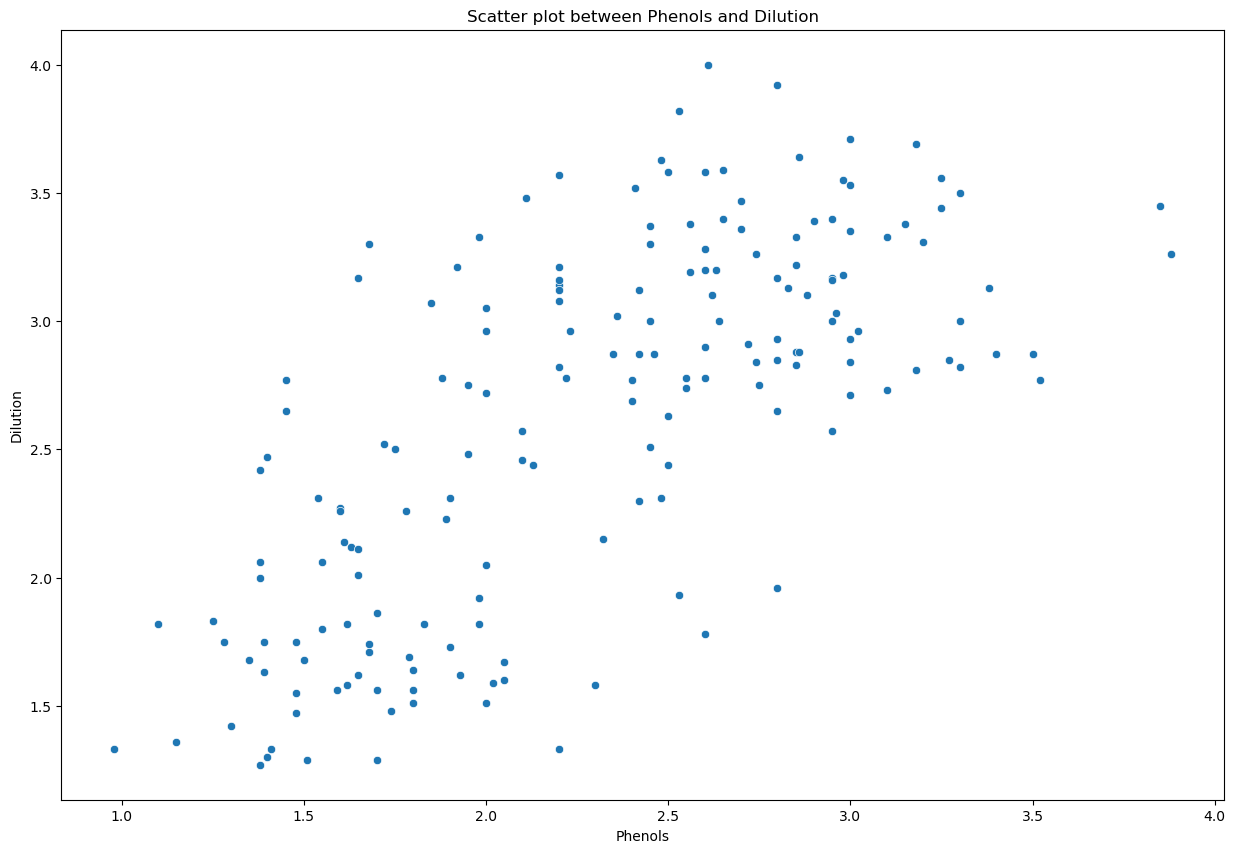

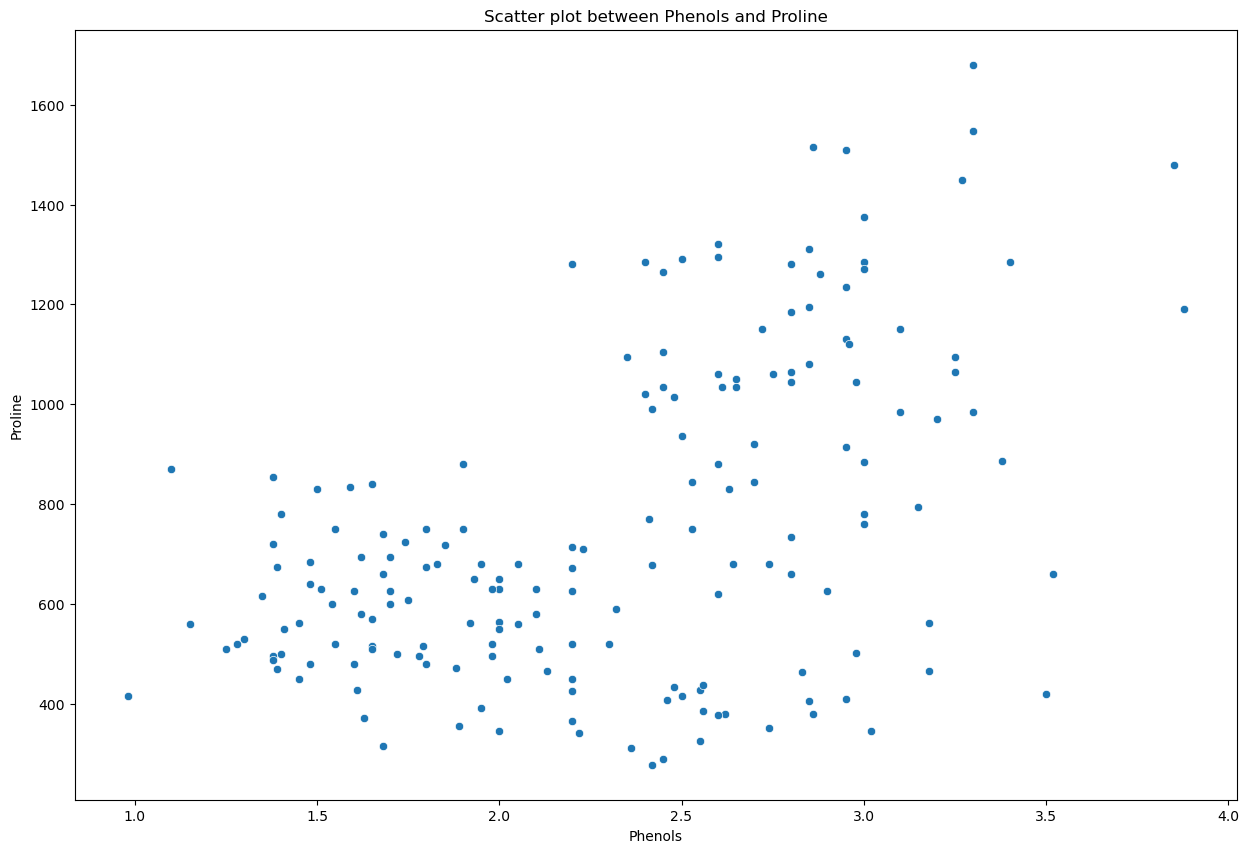

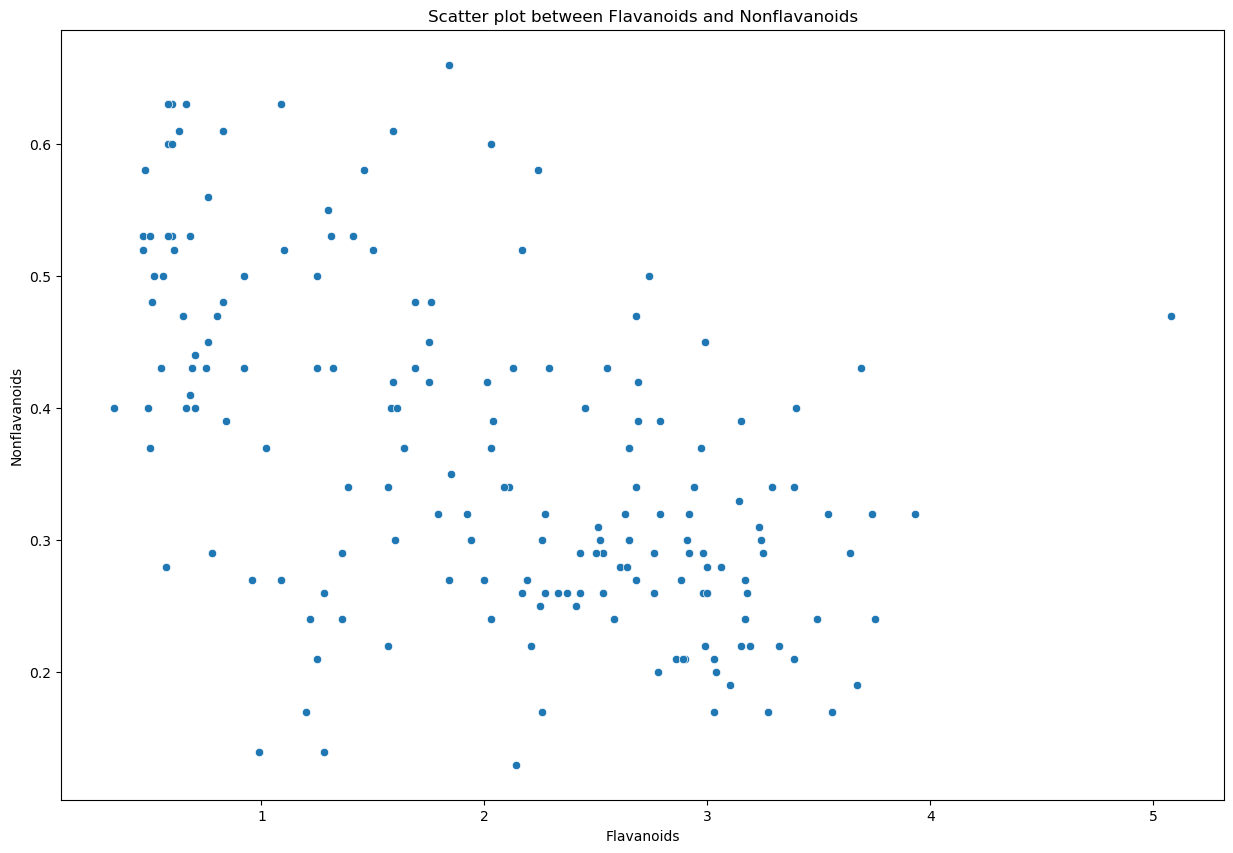

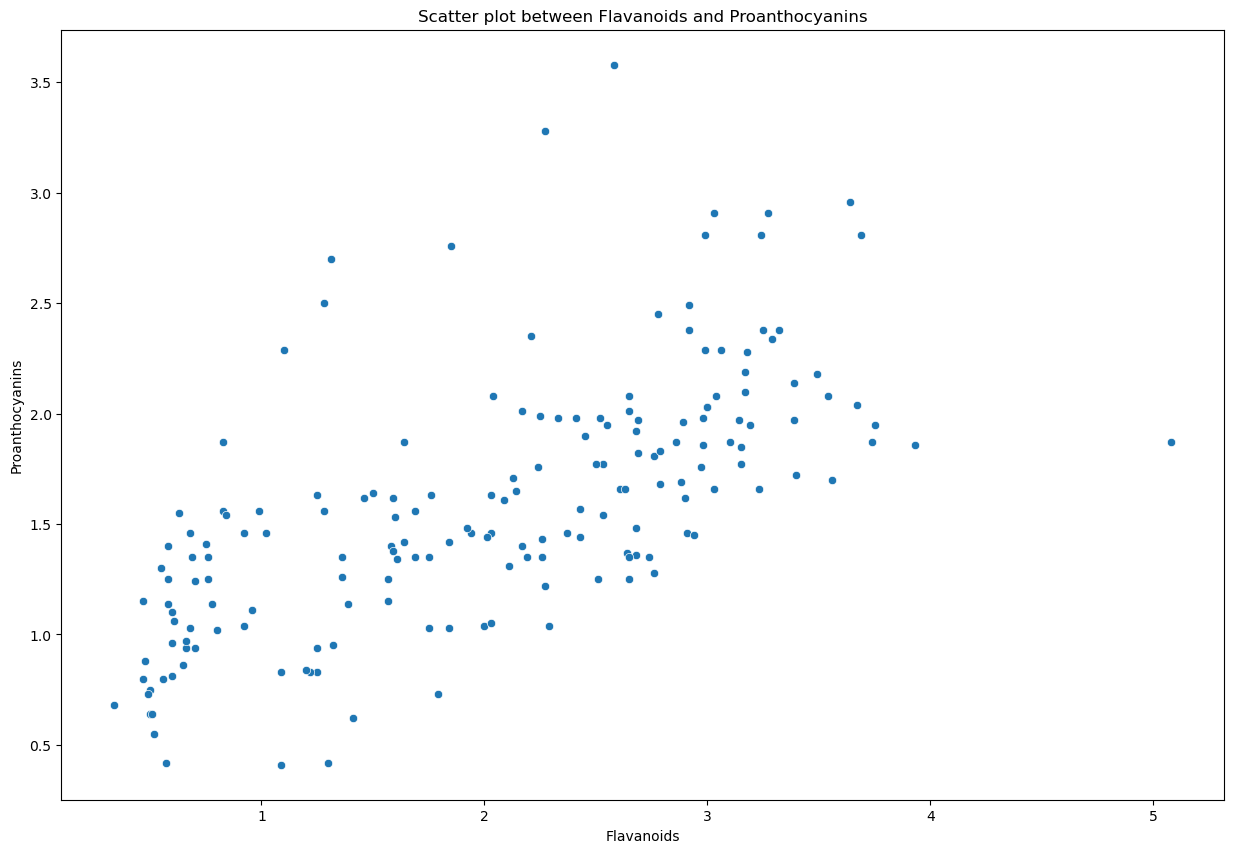

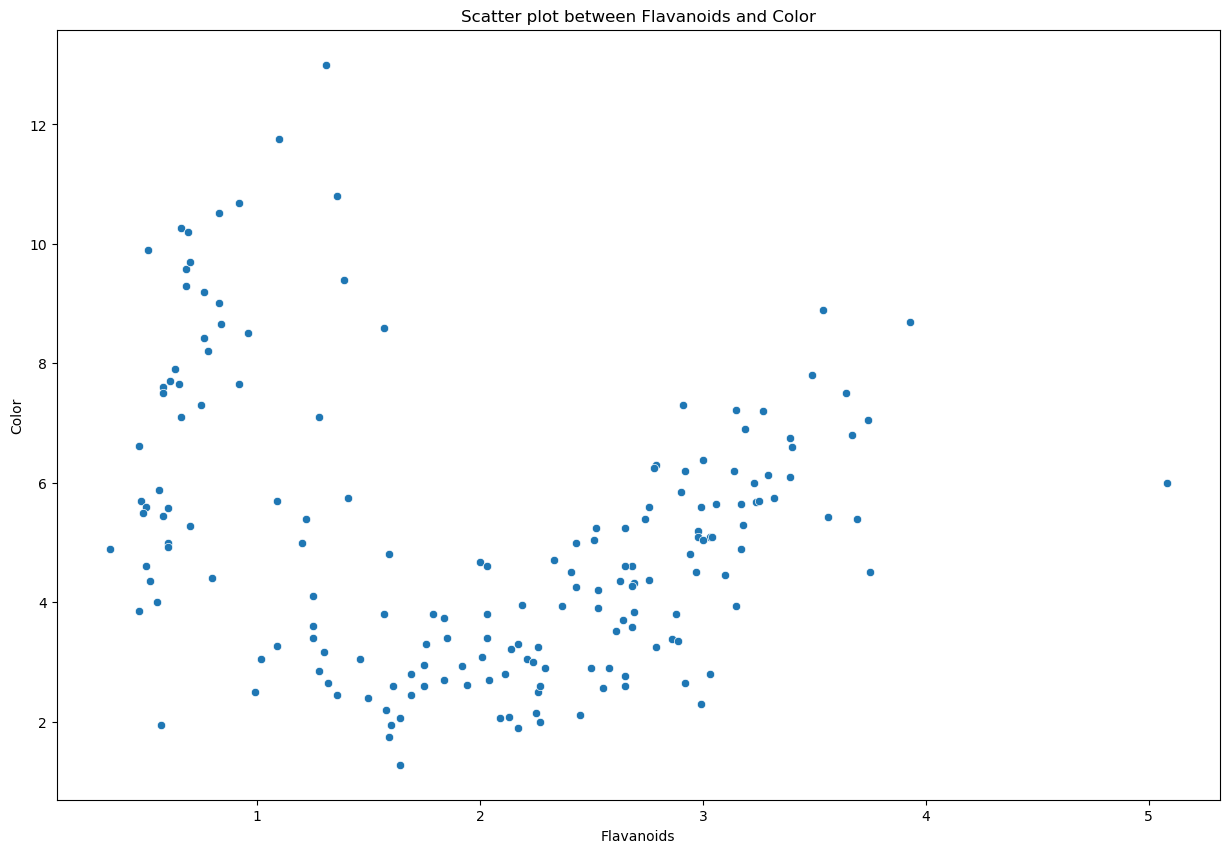

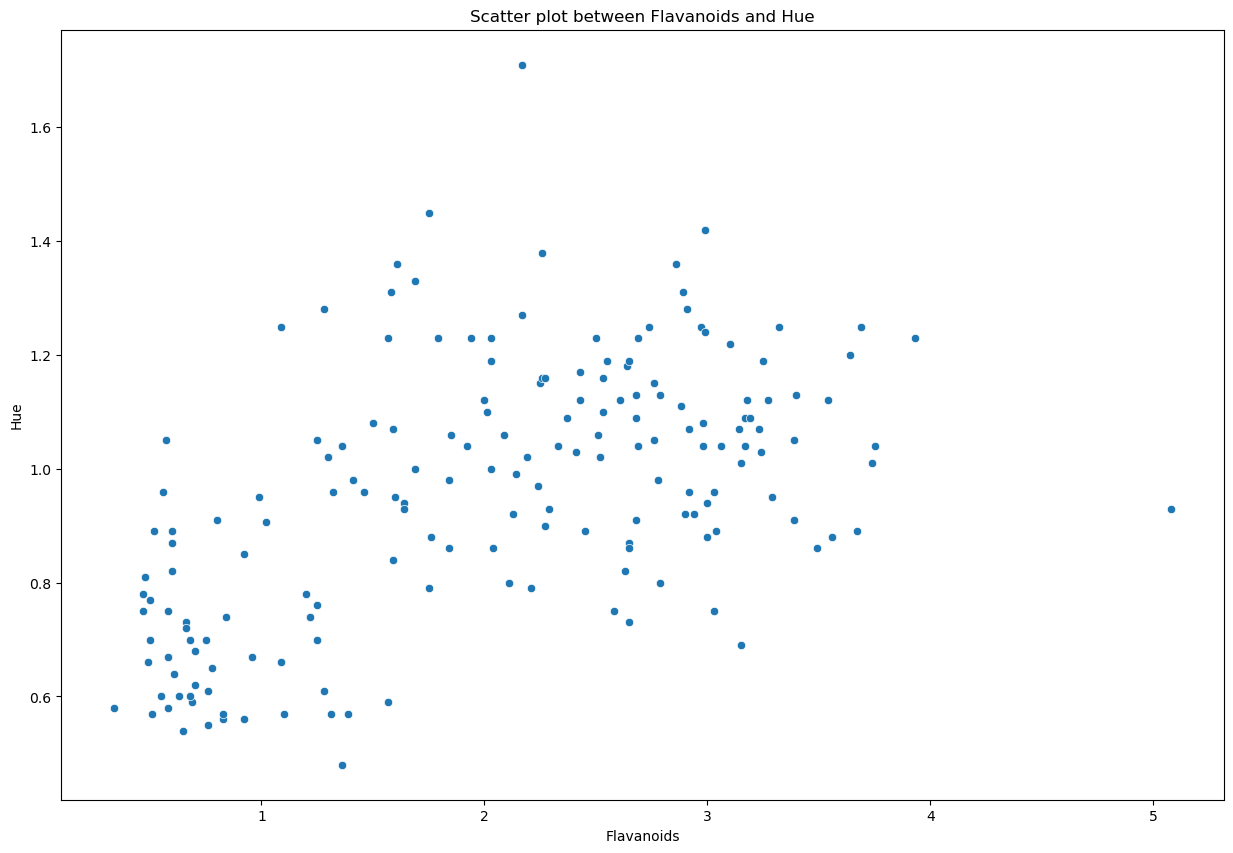

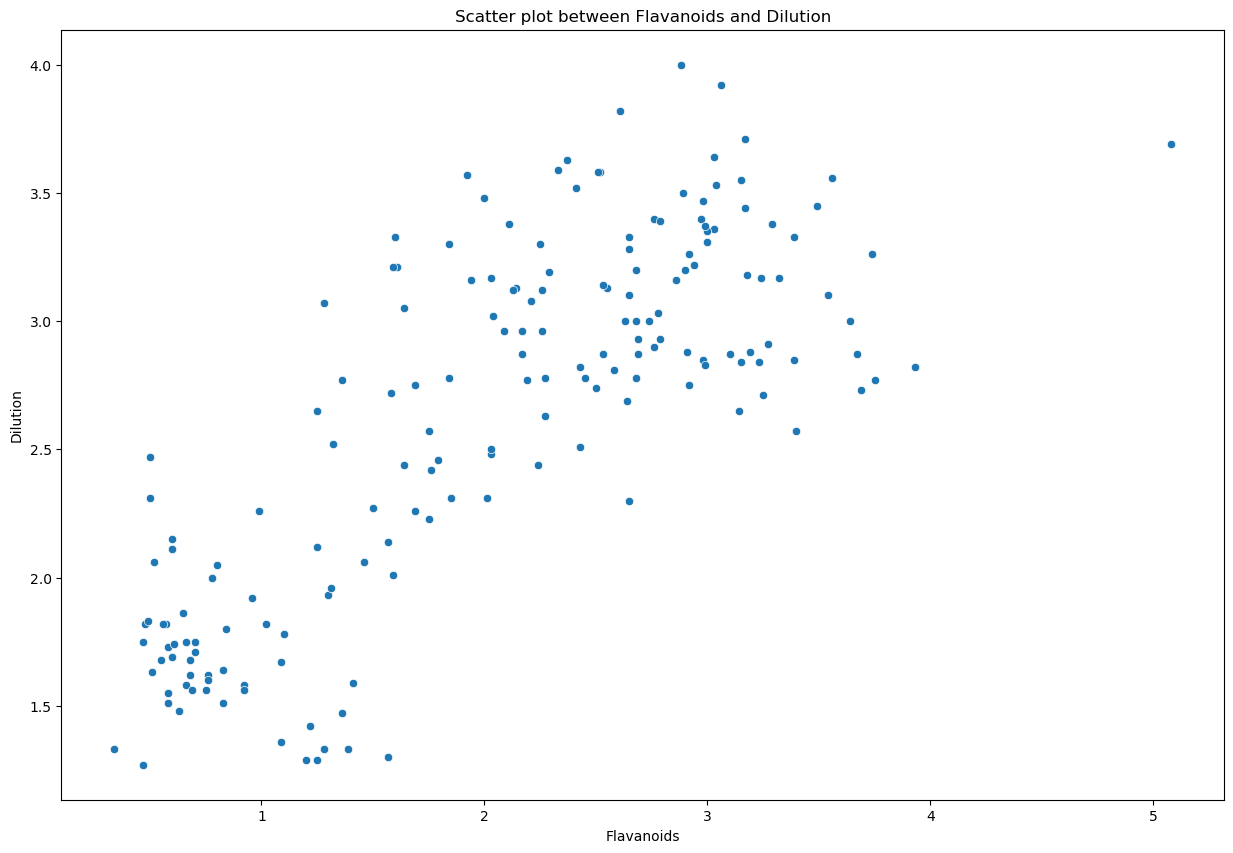

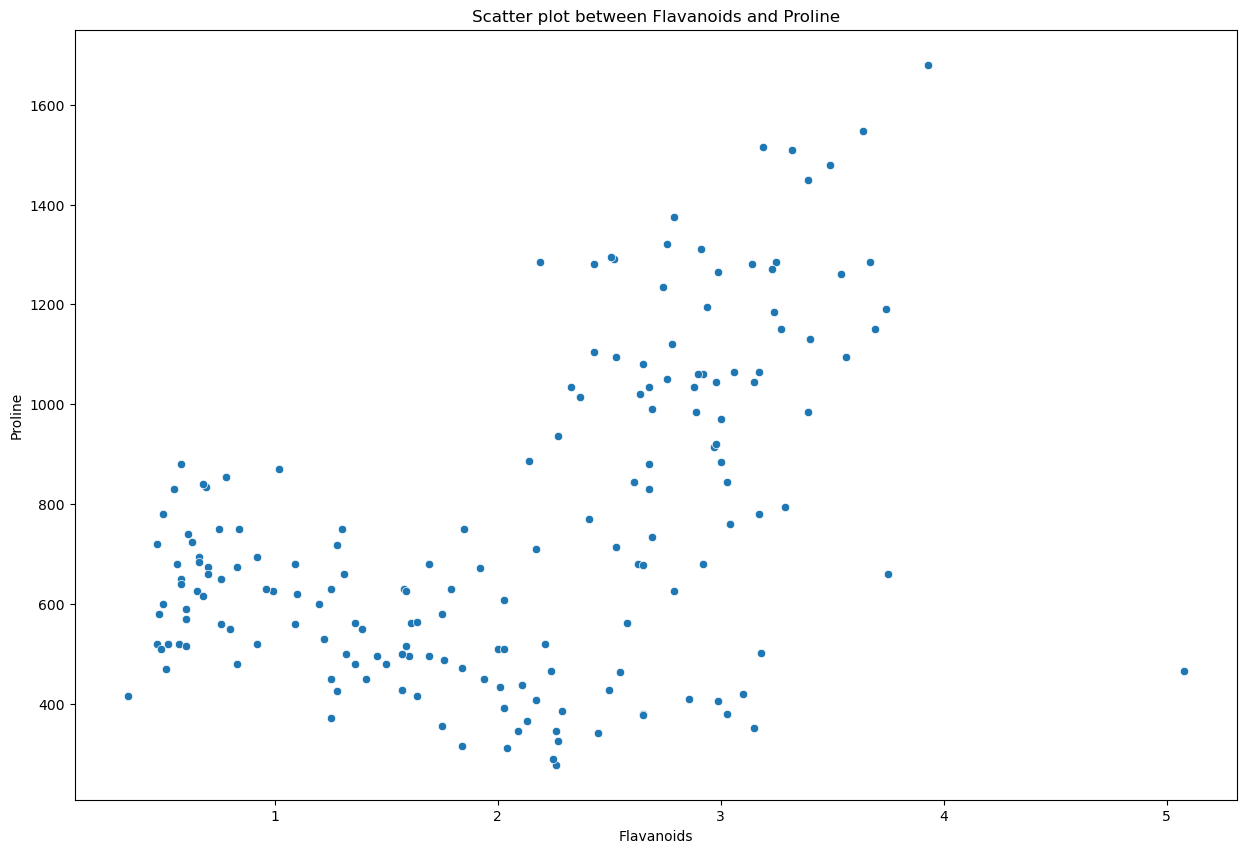

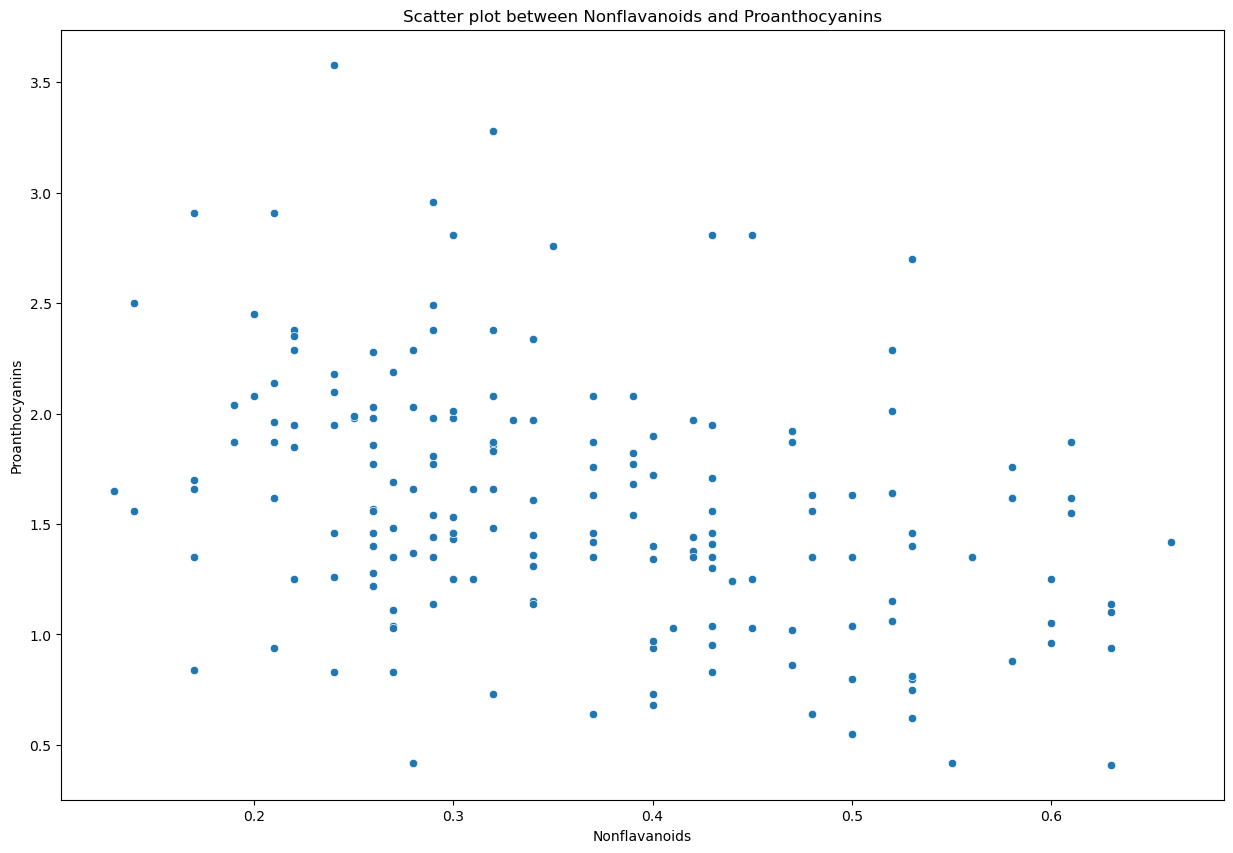

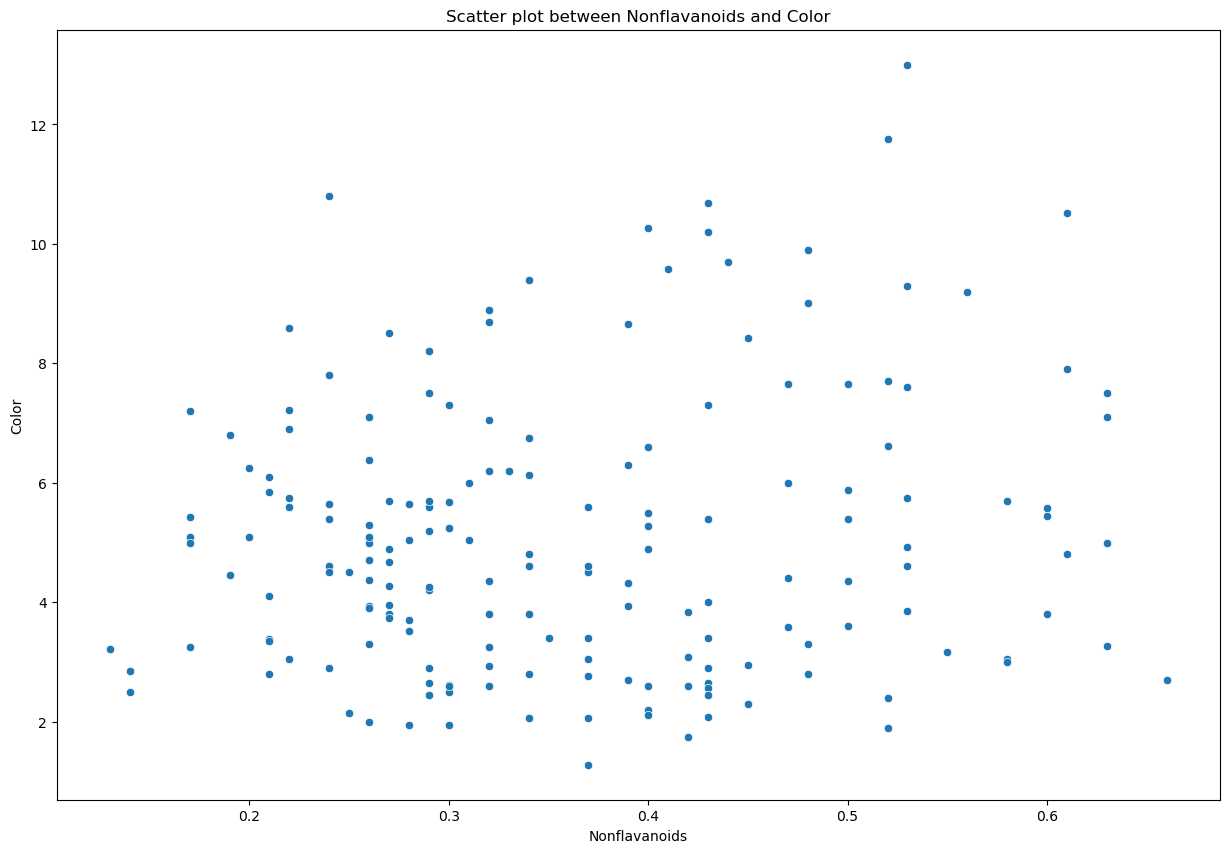

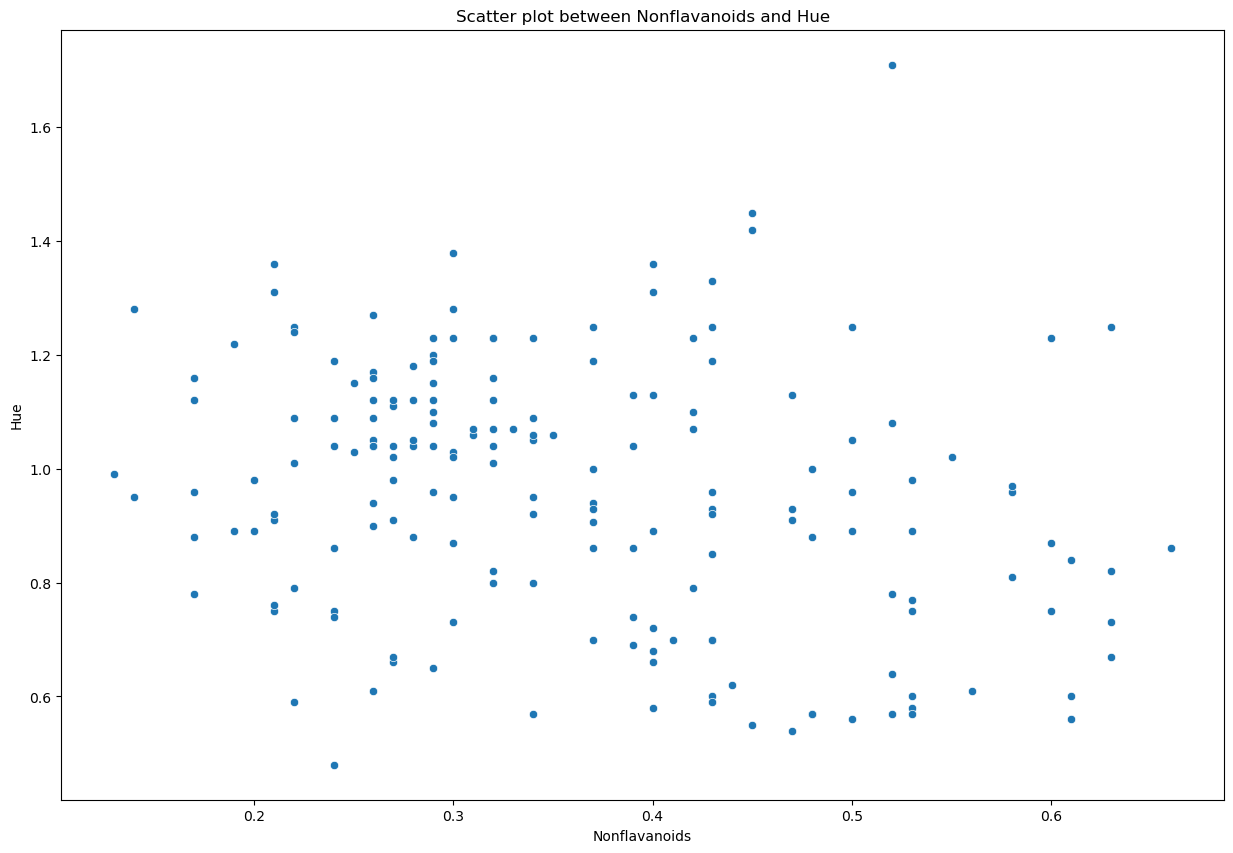

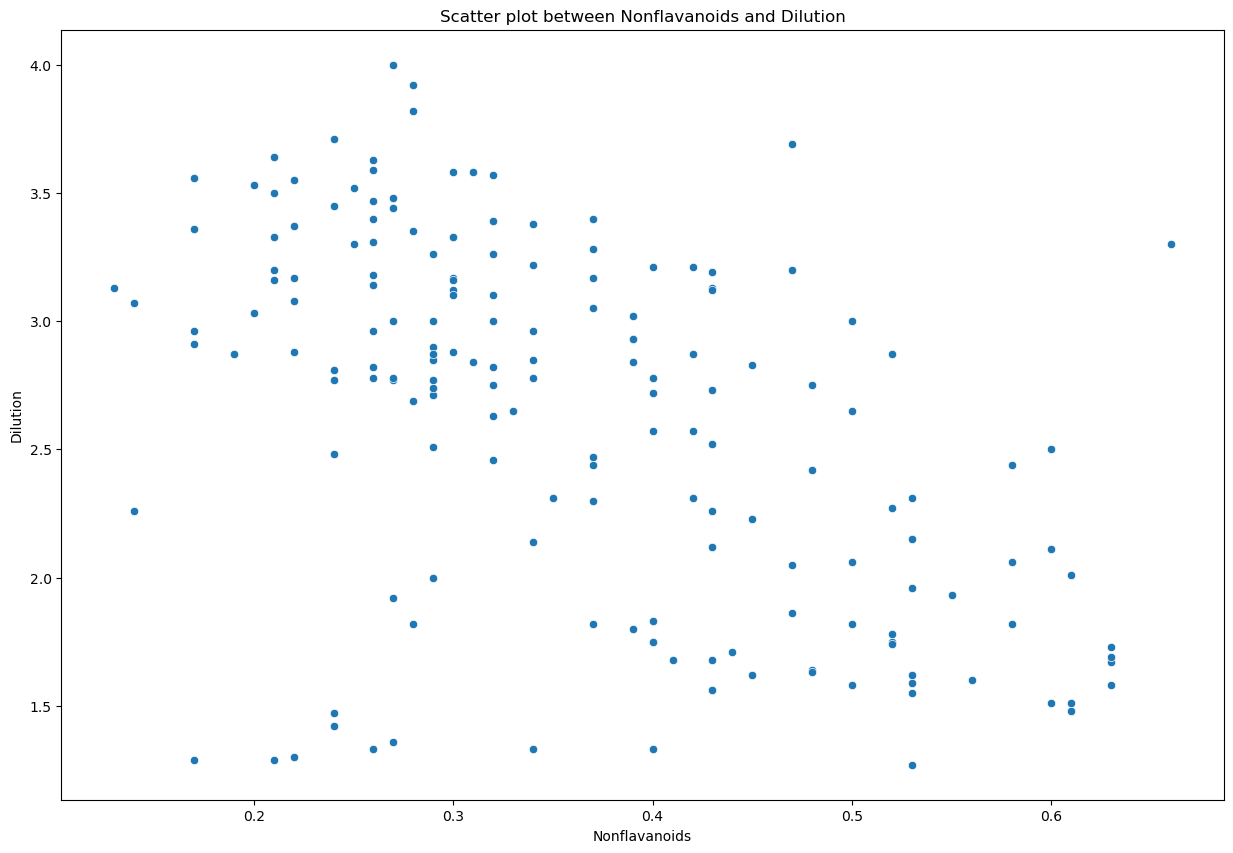

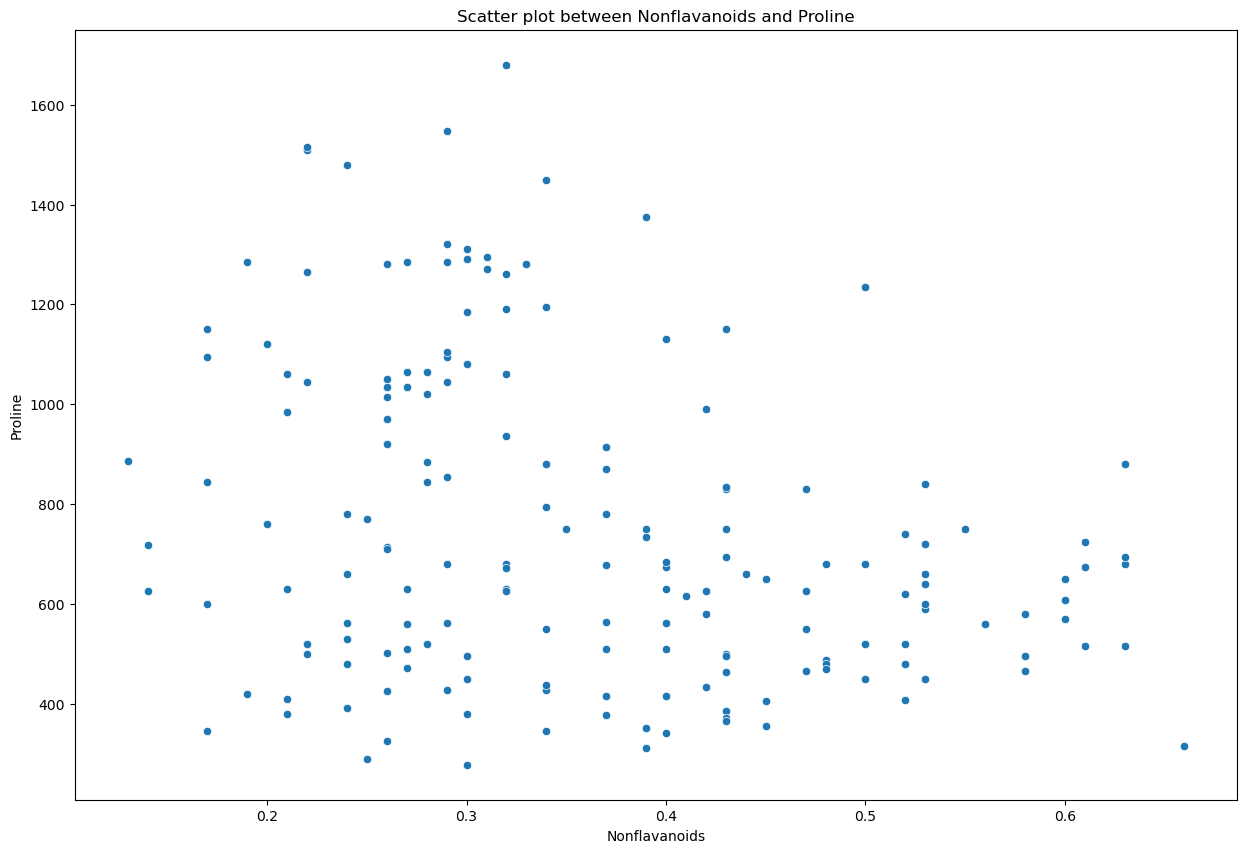

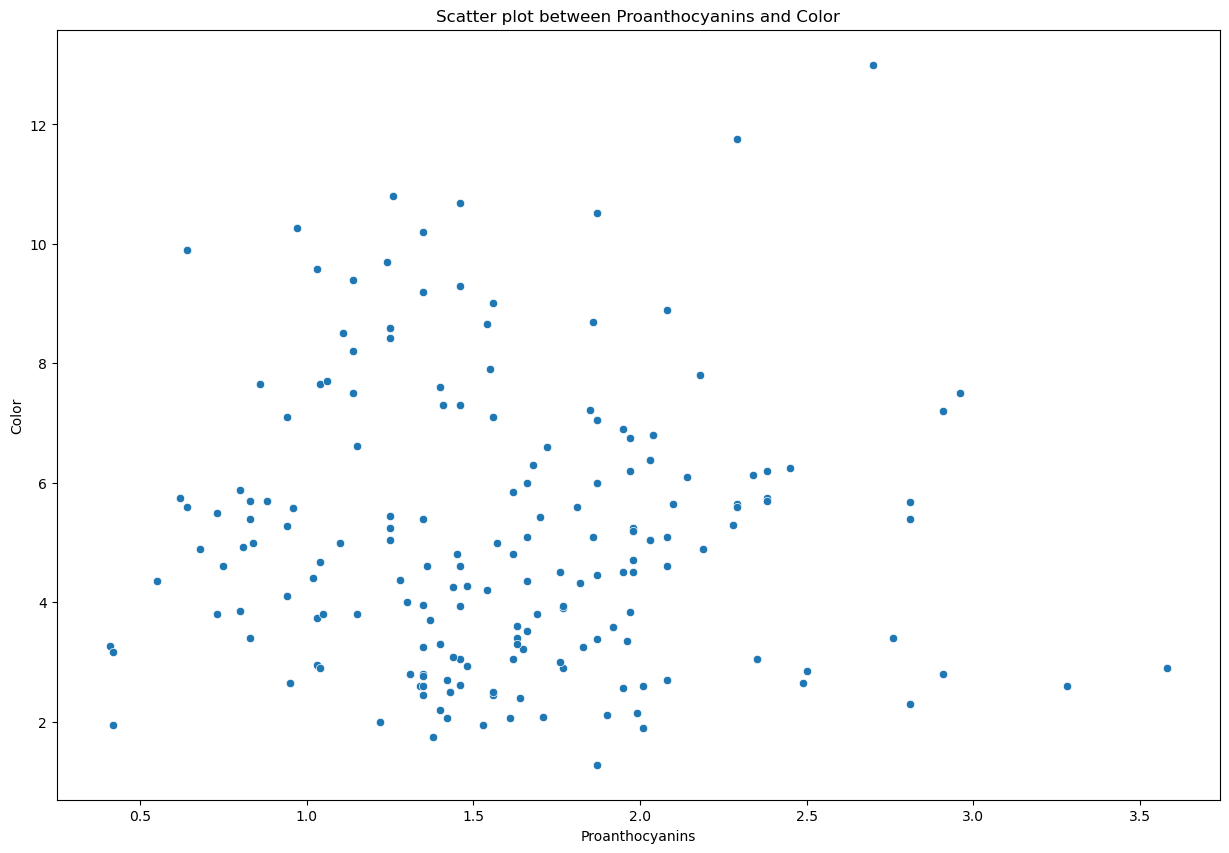

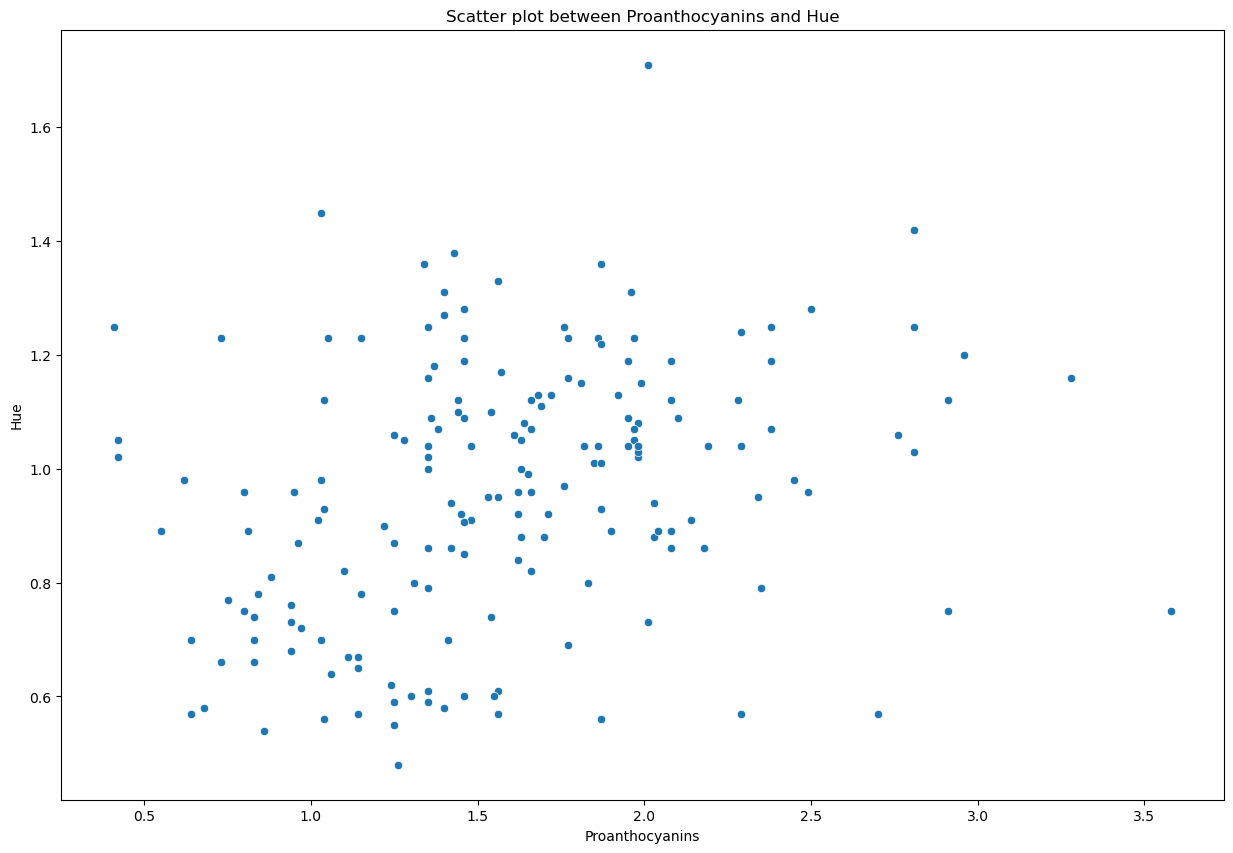

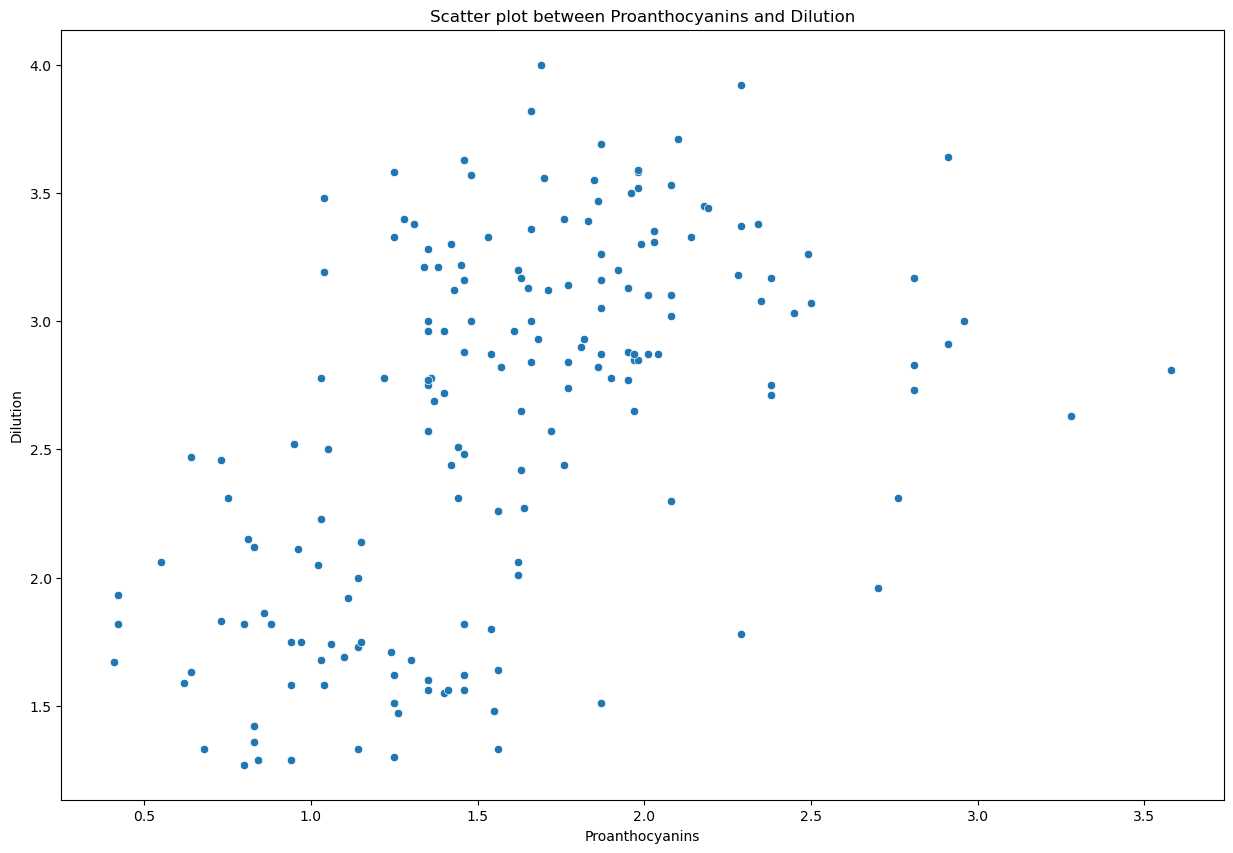

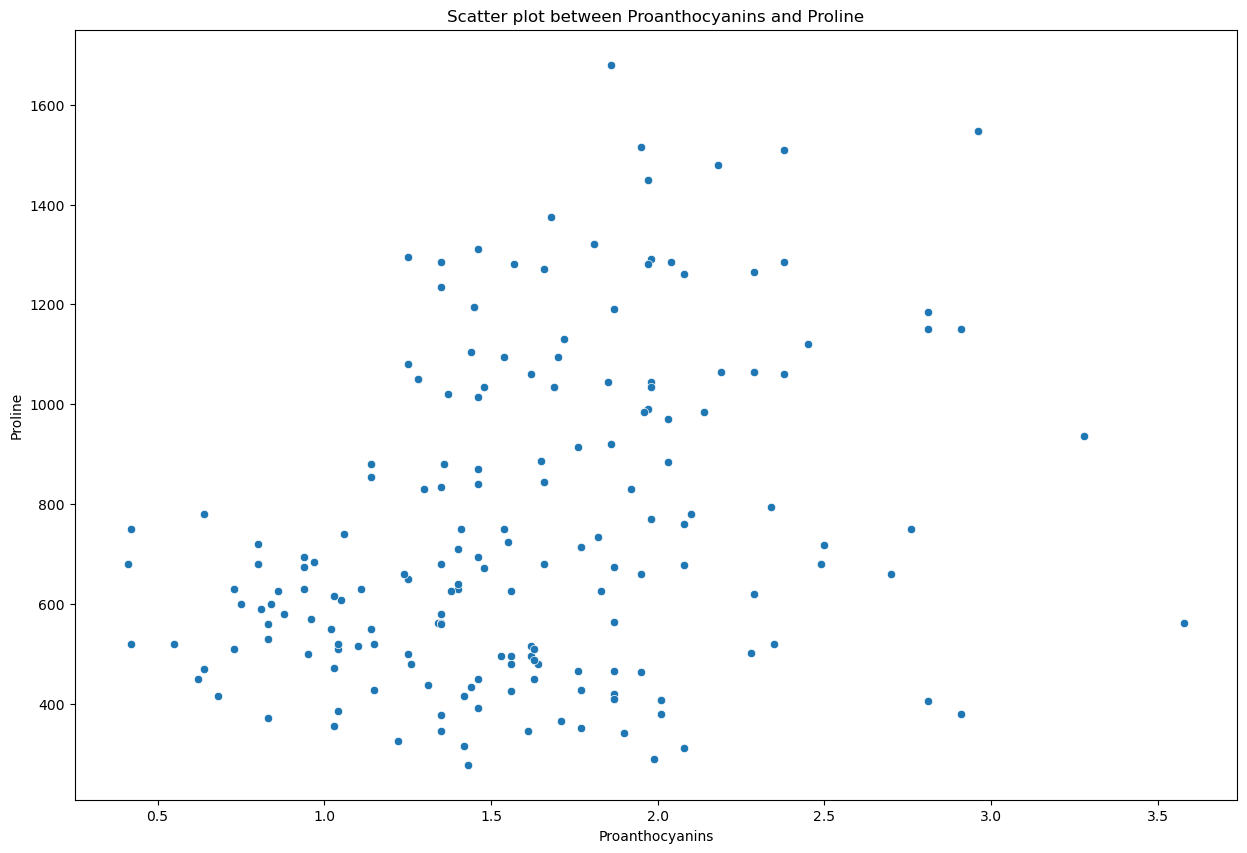

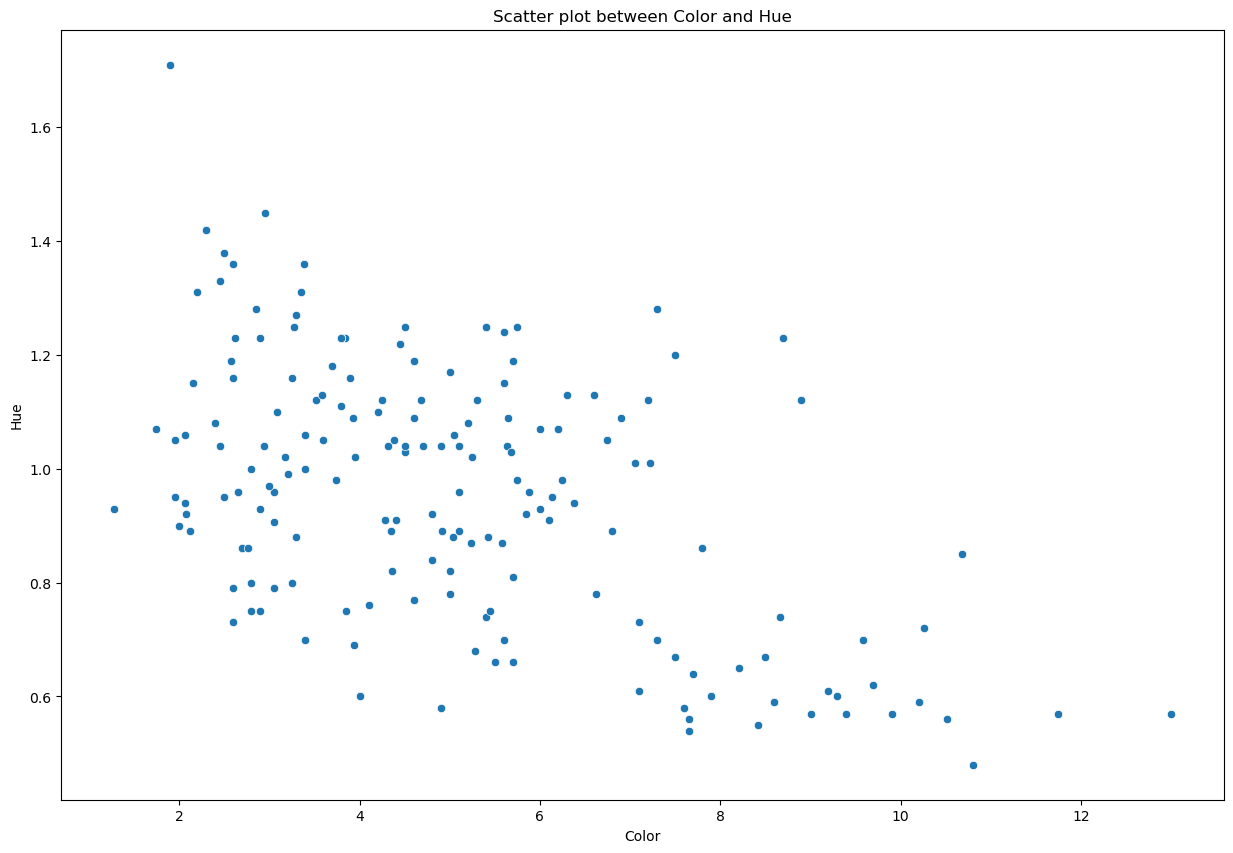

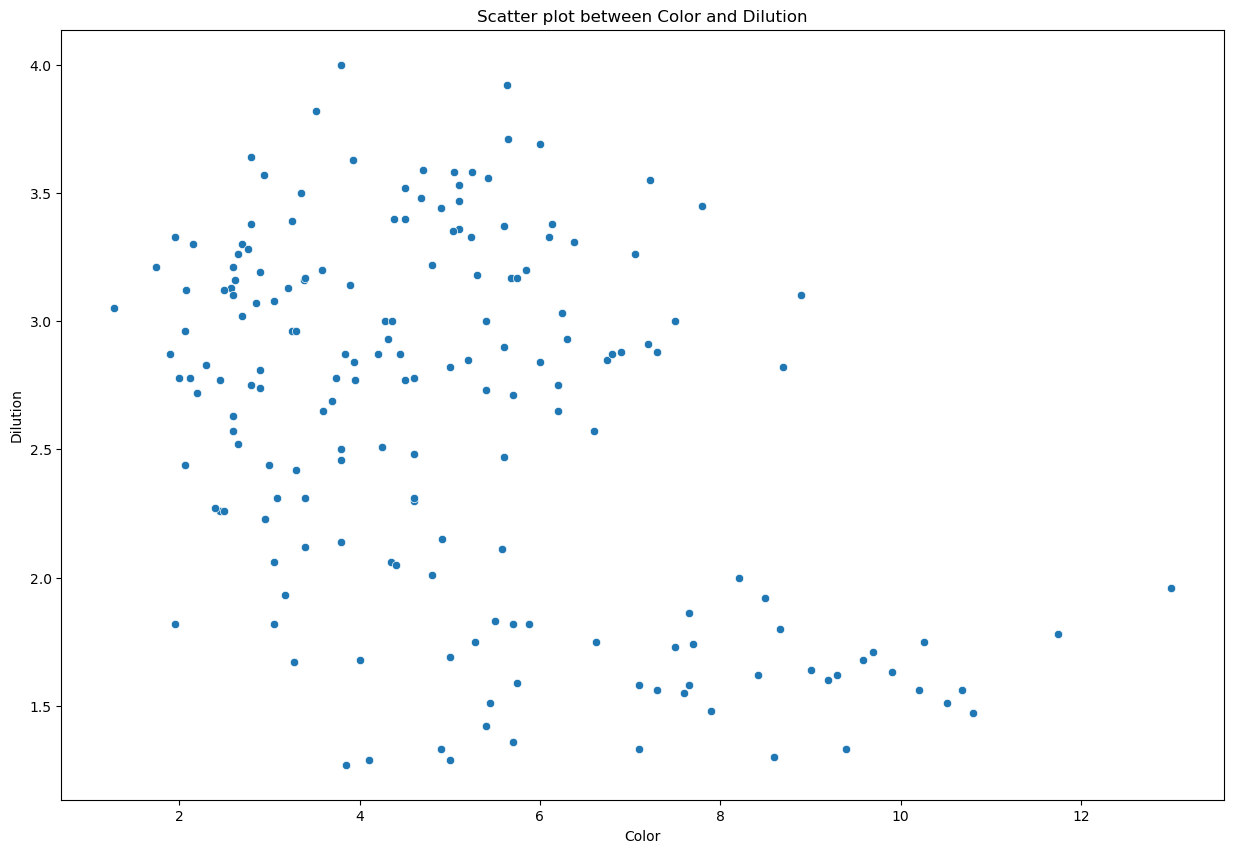

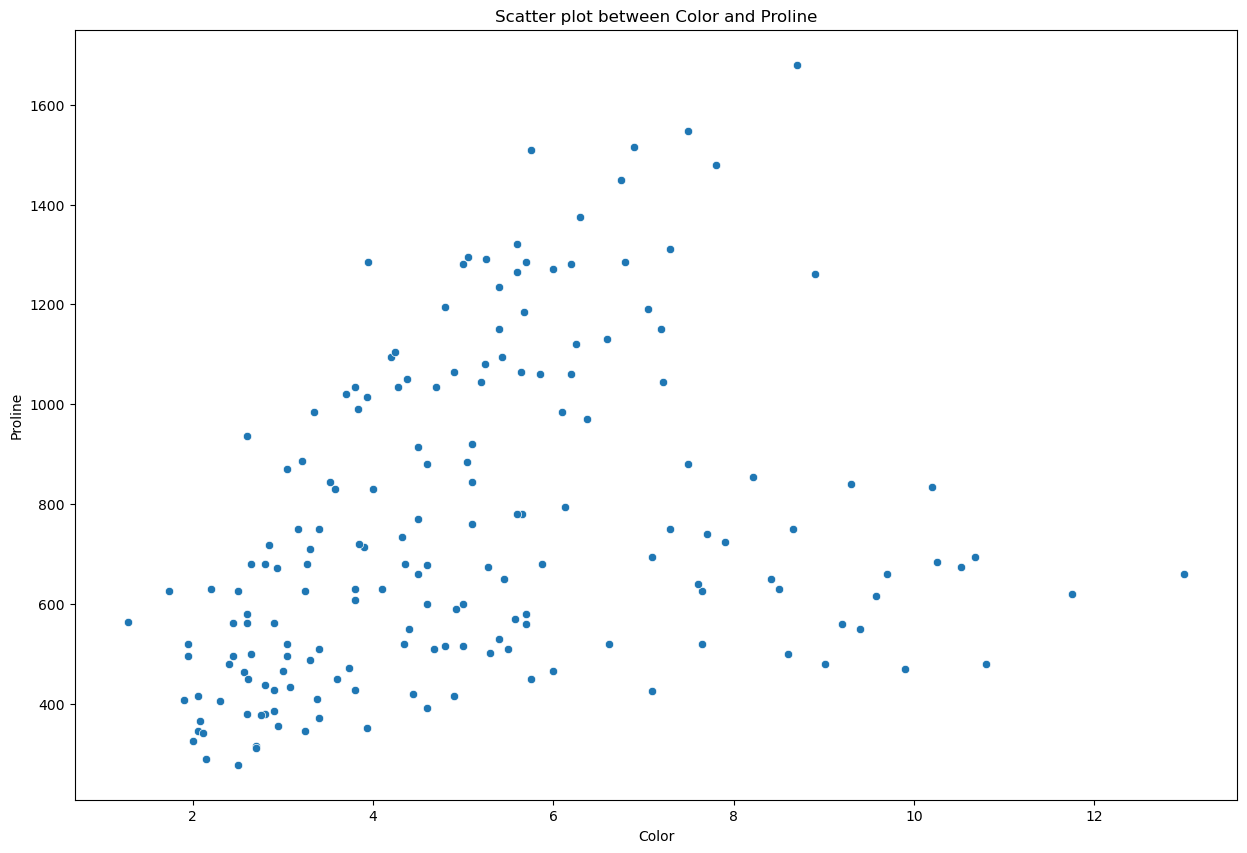

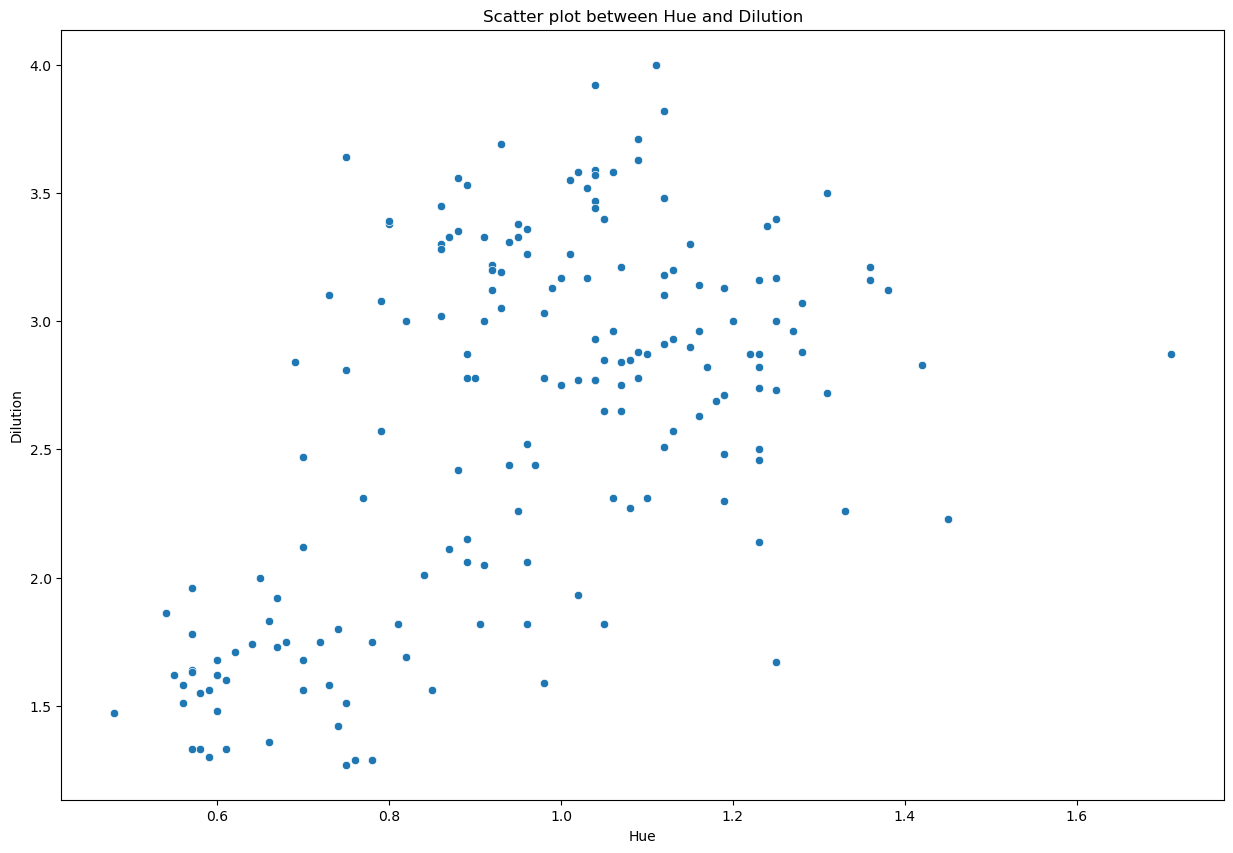

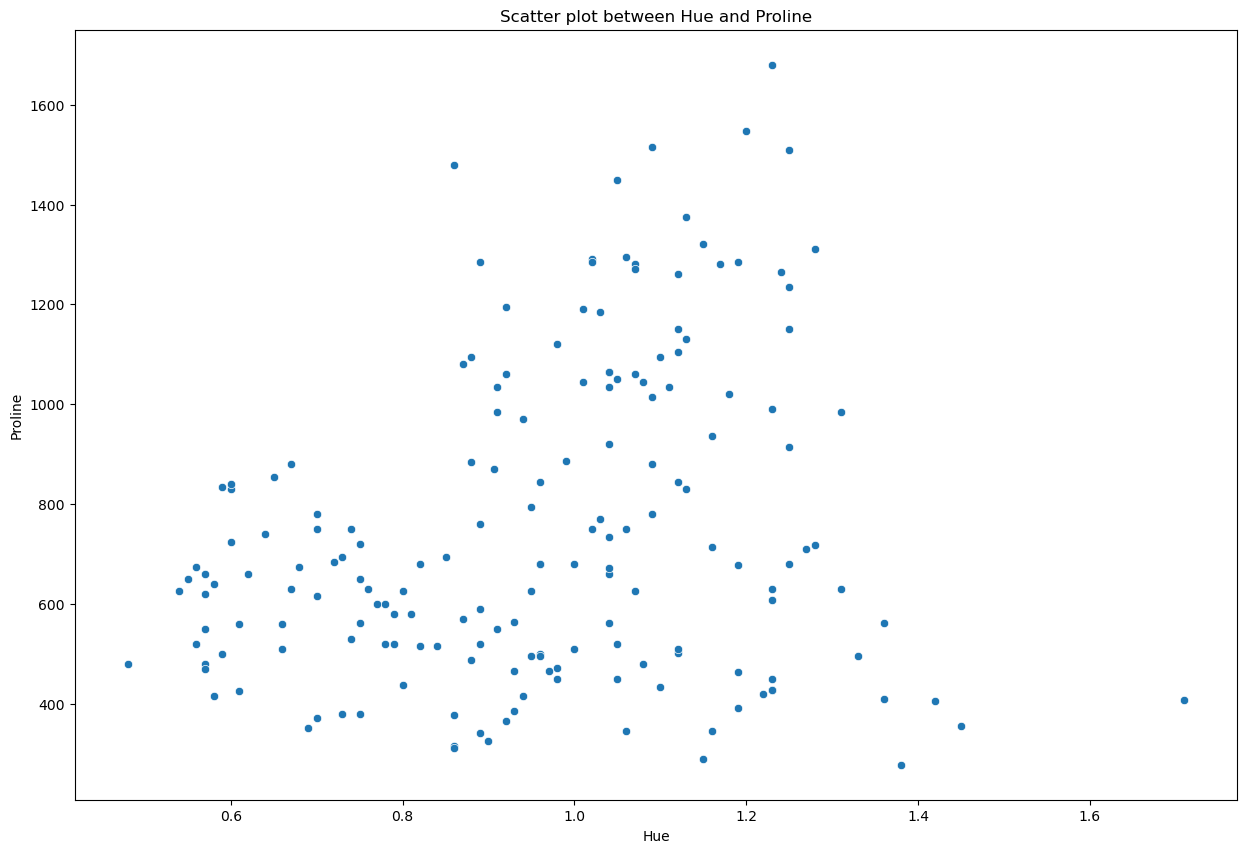

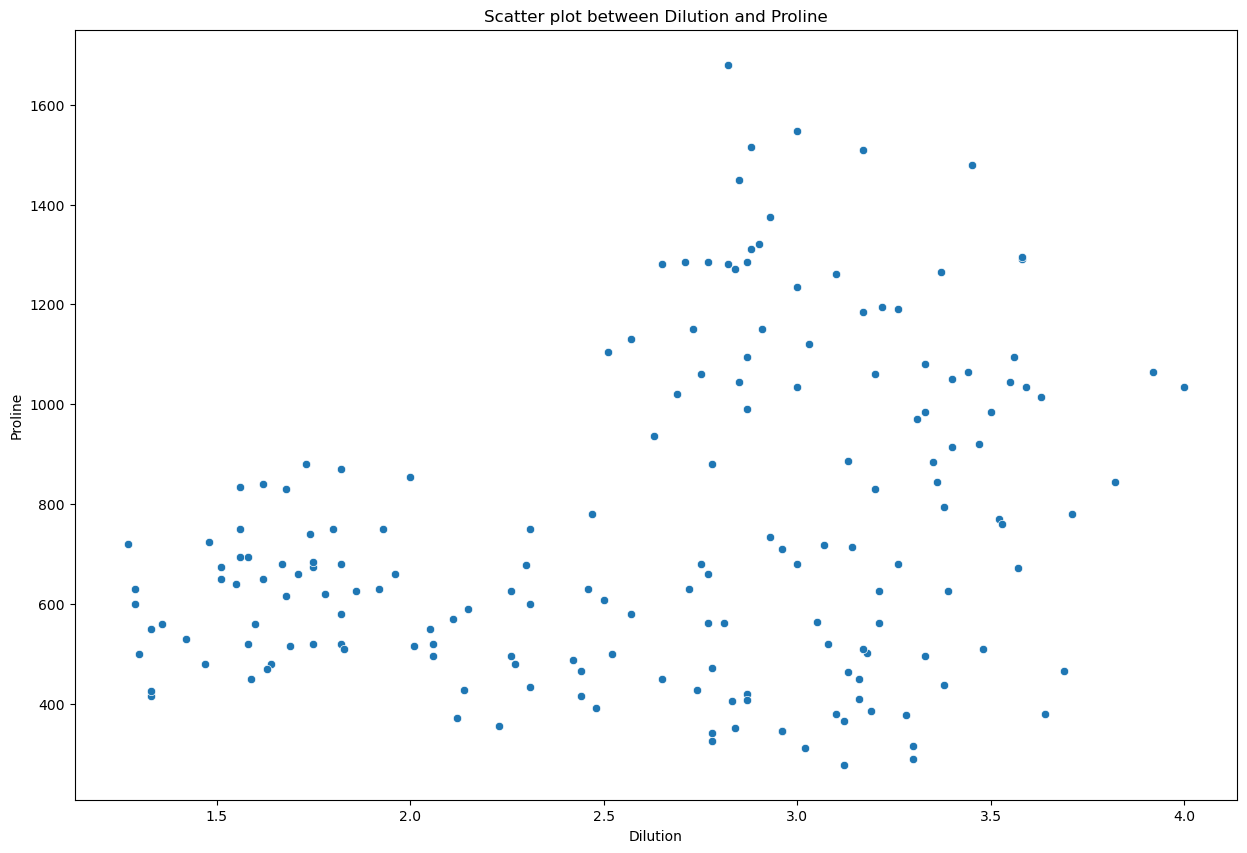

In [4]:
# Relationship between the numerical cols
for i, x_col in enumerate(numerical_cols):
    for y_col in numerical_cols[i+1:]:
        plt.figure(figsize=(15,10))
        sns.scatterplot(x=x_col,y=y_col, data=df)
        plt.title(f"Scatter plot between {x_col} and {y_col}")

        plt.show()

## Task2: Dimentionality Reduction With PCA

In [5]:
# 1. Standardizig features 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


scaler = StandardScaler()

X = df.drop(target,axis=1)
y = df[target]

X_scaled = scaler.fit_transform(X)

# Applying PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)



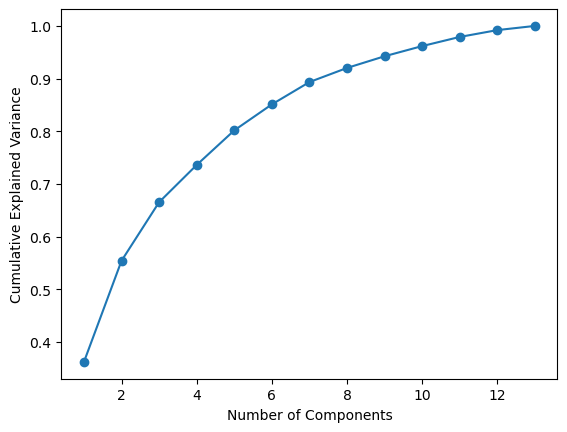

In [10]:
plt.plot(range(1, X.shape[1] +1), pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

In [11]:
pca = PCA(n_components=0.95)  # keep 95% variance
X_pca = pca.fit_transform(X_scaled)

## Task3:  Clustering with Original Data:

In [18]:
#Kmeans clustering 
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

kmeans = KMeans(n_clusters=3,random_state=42)
labels = kmeans.fit_predict(X_scaled)

C:\Users\mdrud\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


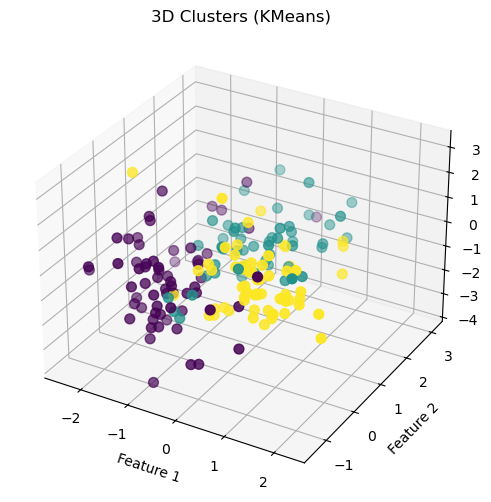

In [20]:
"""
Considering the whole feature ould me messy to visualize 
so, here i have taken only three.
"""

from mpl_toolkits.mplot3d import Axes3D

# 3D scatter plot using first 3 features
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_scaled[:,0],  
    X_scaled[:,1],   
    X_scaled[:,2],   
    c=labels,        
    cmap='viridis', 
    s=50             
)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")
plt.title("3D Clusters (KMeans)")
plt.show()


In [22]:
#Evaluating clustering 
print("Silhouette score: ", silhouette_score(X_scaled, labels))
print("Davies-Bouldin Index: ", davies_bouldin_score(X_scaled,labels))

Silhouette score:  0.2848589191898987
Davies-Bouldin Index:  1.389187977718165


## Task4: Clustering With PCA Data

In [28]:
kmeans_pca= KMeans(n_clusters=3,random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca)

C:\Users\mdrud\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


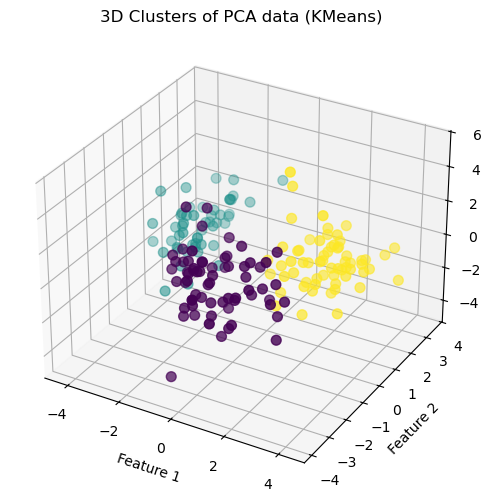

In [31]:
# Visualizing result using first 2 pcs
from mpl_toolkits.mplot3d import Axes3D

# 3D scatter plot using first 3 features
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca[:,0],  
    X_pca[:,1],   
    X_pca[:,2],   
    c=labels_pca,        
    cmap='viridis', 
    s=50             
)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")
plt.title("3D Clusters of PCA data (KMeans)")
plt.show()

In [33]:
print("Silhouette score for pca:",silhouette_score(X_pca,labels_pca))
print("Davies-Bouldin Index for pca:",davies_bouldin_score(X_pca,labels_pca))

Silhouette score for pca: 0.2986748294369289
Davies-Bouldin Index for pca: 1.3363263335155766


## Task5: Comparison and Analysis:
```
1.Clustering results compairision:
    Original Data:
        Silhouette score: 0.28
        Davies-bouldin score: 1.39 (Approximately)
    PCA Data:
        Silhouette score: 0.29 - which is slightly higher.
        Davies-bouldin score: 1.36 - Which is slightly lower.
Hence,PCA clustering performed marginally better than clustering on the original dataset.

2. Similarities and difference observed:
        Similarities:
            - In both approaches the results doesn't vary much .
            - The clusters are consistent means PCA does not drastically changes the stucture rather simplified it.
        Difference:
            - PCA reduced dimentionality while retaining most of the variance, which improves clustering performance a bit.
            - Visualization of clusters in PCA space is easier because fewer dimensions are used.

3. Impact of dimentionality reduction.
    - PCA removes noise and reductant features,leading to slightly better cluster separation.
    - It also makes clustering process more computationaly eficient.

4.Trade_offs:
i.Using the original data, we are able to keep all the informations about our dataset,
while the PCA could suffer with noise and redundancy.

ii. In case pf PCA we may lose some important information (variance), but able to imrove the clustering.
```

## Task6:Conclusion And Insigts:
```
1. Key Findings:
    - Clustering both on original data and PCA-transformed data produced meaningful gropus.
    - PCA improved performance slightly.
    - PCA made visualization easier and reduced noise while retaining most variance.

2. Practical implementations:
    - PCA helps in simplify high_dimensional data, reduce noise and speed up clustering algorithms.
    - Clustering groups similar data points, useful for customer segmentation, anomaly detection, and pattern discovery.
    - Combining PCA + Clustering is powerful: PCA prepares clean features, clustering discovers hidden structures.

3. Recommendations:
    - Use Original data when the raw data is essential for predictability.
    - Use PCA before clustering when:
            i. Data has many correlated features.
            ii. Visualization of cluster is needed.
```